# Importing necessary libraries and defining data structures are fundamental to implementing Matrix-Fisher-Gaussian distribution sampling. Below are some core data structure definitions:

# =========================

# Basic Data Structures

# ==========================#

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Callable, List, Tuple, Optional


@dataclass
class Pose:
    """
    Pose X = (R, p)
    R: 3x3 Rotation matrix
    p: 3-dimensional translation vector
    """
    R: np.ndarray   # shape (3,3)
    p: np.ndarray   # shape (3,)


@dataclass
class MFGParameters:
    """
    Matrix-Fisher-Gaussian Distribution parameters
    Theta = {F, mu, Lambda, Gamma}
    
    F      : Matrix Fisher Parameter matrix, shape (3,3)
    mu     : Gaussian Translation Mean, shape (3,)
    Lambda : Translation Precision Matrix, shape (3,3)
    Gamma  : Rotation-Translation Coupling Matrix, shape (3,3)
    """
    F: np.ndarray
    mu: np.ndarray
    Lambda: np.ndarray
    Gamma: np.ndarray


@dataclass
class SuperquadricFieldParameters:
    """
    Superquadric implicit field parameters
    
    F_3d(x,y,z) = (f(x,y))^(eps2/eps1) + |z/a3|^(2/eps1) - 1
    f(x,y)      = |x/a1|^(2/eps2) + |y/a2|^(2/eps2)
    """
    a1: float
    a2: float
    a3: float
    eps1: float
    eps2: float
    sdf_eps: float = 1e-8  # Denominator stability term for normalized signed field

@dataclass
class StiffnessParameters:
    """
   Smooth stiffness function parameters
    
    k(d) = k_min + ((1 - tanh(d/d0))/2) * k_max
    """
    k_min: float
    k_max: float
    d0: float


def ensure_vector(x: np.ndarray, dim: int) -> np.ndarray:
    """
    The input is guaranteed to be a one-dimensional vector of a specified length.
    """
    x = np.asarray(x, dtype=float).reshape(-1)
    if x.shape[0] != dim:
        raise ValueError(f"Vector dimension error, expected {dim}, got {x.shape[0]}")
    return x


def ensure_matrix(x: np.ndarray, shape: Tuple[int, int]) -> np.ndarray:
    """
    The input is guaranteed to be a matrix of a specified shape.
    """
    x = np.asarray(x, dtype=float)
    if x.shape != shape:
        raise ValueError(f"Matrix dimension error, expected {shape}, got {x.shape}")
    return x

# SO(3) Basic geometric functions: hat/vee/exp/log
# =========================

In [ ]:
def hat(v: np.ndarray) -> np.ndarray:
    """
    Vector -> Antisymmetric Matrix
    For v = [v1,v2,v3]^T,
    hat(v) = [[ 0, -v3,  v2],
              [ v3,  0, -v1],
              [-v2, v1,   0]]
    """
    v = ensure_vector(v, 3)
    return np.array([
        [0.0,   -v[2],  v[1]],
        [v[2],   0.0,  -v[0]],
        [-v[1],  v[0],  0.0]
    ])


def vee(M: np.ndarray) -> np.ndarray:
    """
    Antisymmetric Matrix -> Vector
    """
    M = ensure_matrix(M, (3, 3))
    return np.array([
        M[2, 1],
        M[0, 2],
        M[1, 0]
    ])


def exp_so3(phi: np.ndarray) -> np.ndarray:
    """
    SO(3) exponential map
    R = exp(hat(phi))
    Rodrigues formula:
    R = I + (sin(theta)/theta) * hat(phi) + ((1 - cos(theta))/theta^2) * hat(phi)^2
    where theta = ||phi||
    For small theta, use the limit as theta -> 0 to avoid numerical instability.
    R = I + hat(phi) when theta is close to zero.  
    """
    phi = ensure_vector(phi, 3)
    theta = np.linalg.norm(phi)

    if theta < 1e-12:
        return np.eye(3) + hat(phi)

    A = np.sin(theta) / theta
    B = (1.0 - np.cos(theta)) / (theta ** 2)
    Phi = hat(phi)
    return np.eye(3) + A * Phi + B * (Phi @ Phi)


def log_so3(R: np.ndarray) -> np.ndarray:
    """
    SO(3) logarithm map
    phi = log(R)^\vee
    """
    R = ensure_matrix(R, (3, 3))
    cos_theta = (np.trace(R) - 1.0) / 2.0
    cos_theta = np.clip(cos_theta, -1.0, 1.0)
    theta = np.arccos(cos_theta)

    if theta < 1e-12:
        return vee(R - R.T) / 2.0

    return vee((theta / (2.0 * np.sin(theta))) * (R - R.T))


def project_to_so3(M: np.ndarray) -> np.ndarray:
    """
    SVD projects a 3x3 matrix onto SO(3).
    """
    M = ensure_matrix(M, (3, 3))
    U, _, Vt = np.linalg.svd(M)
    R = U @ np.diag([1.0, 1.0, np.linalg.det(U @ Vt)]) @ Vt
    return R


def right_plus_pose(X: Pose, xi: np.ndarray) -> Pose:
    """
    right perturbation of pose:
        X ⊕ xi = (R exp(hat(phi)), p + v)
    where xi = [phi; v] ∈ R^6
    """
    xi = ensure_vector(xi, 6)
    phi = xi[:3]
    v = xi[3:]
    R_new = X.R @ exp_so3(phi)
    p_new = X.p + v
    return Pose(R=R_new, p=p_new)


def pose_inverse(X: Pose) -> Pose:
    """
    pose inverse:
        X^{-1} = (R^T, -R^T p)
    """
    R_inv = X.R.T
    p_inv = -R_inv @ X.p
    return Pose(R=R_inv, p=p_inv)


def compose_pose(X1: Pose, X2: Pose) -> Pose:
    """
    Pose composition:
        X1 * X2 = (R1 R2, R1 p2 + p1)
    """
    R = X1.R @ X2.R
    p = X1.R @ X2.p + X1.p
    return Pose(R=R, p=p)


def skew(v: np.ndarray) -> np.ndarray:
    v = np.asarray(v, dtype=float).reshape(3,)
    return np.array([
        [0.0,   -v[2],  v[1]],
        [v[2],   0.0,  -v[0]],
        [-v[1],  v[0],  0.0]
    ])

def so3_exp(w: np.ndarray) -> np.ndarray:
    """
    SO(3) exponential map using Rodrigues' formula, with numerical stability for small angles.
    """
    w = np.asarray(w, dtype=float).reshape(3,)
    theta = np.linalg.norm(w)
    W = skew(w)

    if theta < 1e-12:
        return np.eye(3) + W

    A = np.sin(theta) / theta
    B = (1.0 - np.cos(theta)) / (theta**2)
    return np.eye(3) + A * W + B * (W @ W)

In [ ]:
# =========================
# MFG / Matrix Fisher Related auxiliary functions
# =========================
def rotation_mode_from_F(F: np.ndarray) -> np.ndarray:
    """
     Proposition VI.1:
        F = U S V^T
        R_hat = U diag(1,1,det(UV^T)) V^T
    Recover MAP rotation from F
    """
    F = ensure_matrix(F, (3, 3))

    if not np.isfinite(F).all():
        raise ValueError("F has NaN or Inf, cannot perform SVD.")

    U, _, Vt = np.linalg.svd(F)
    R_hat = U @ np.diag([1.0, 1.0, np.linalg.det(U @ Vt)]) @ Vt
    return R_hat



def recover_pose_from_theta(theta: MFGParameters) -> Pose:
    """
     Proposition VI.1 Recover from posterior parameters MAP pose:
        R_hat = mode(F_post)
        p_hat = mu_post
    """
    R_hat = rotation_mode_from_F(theta.F)
    p_hat = ensure_vector(theta.mu, 3)
    return Pose(R=R_hat, p=p_hat.copy())



def nu_from_rotation(R: np.ndarray) -> np.ndarray:
    """
     nu_R = (R^T F - F^T R)^vee，
        However, in the current code, Algorithm 1 requires a fixed nu_{Rbar} corresponding to the nominal pose.
    
         Since Algorithm 1 in the paper uses:

            eta <- Lambda (mu + Gamma nu_{Rbar})

        a separate general interface is provided here.
    """
    R = ensure_matrix(R, (3, 3))
    return log_so3(R)


def adjoint_wrench_transform(R_AB: np.ndarray, p_AB: np.ndarray) -> np.ndarray:
    """
    wrench from frame {B} trans to frame {A}:
    
        w_A = [ R_AB      p_AB^x R_AB ] w_B
              [  0            R_AB    ]
    
    where w = [tau; f]
    """
    R_AB = ensure_matrix(R_AB, (3, 3))
    p_AB = ensure_vector(p_AB, 3)

    T = np.block([
        [R_AB,              hat(p_AB) @ R_AB],
        [np.zeros((3, 3)),  R_AB]
    ])
    return T


def split_jacobian_blocks(J: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    split 6x6 Jacobian into [J_phi, J_v]
    """
    J = ensure_matrix(J, (6, 6))
    return J[:, :3], J[:, 3:]


def skew_cross_matrix(v: np.ndarray) -> np.ndarray:

    return hat(v)

# SDF / stiffness / measurement model
# superquadric implicit field
# gradient / Hessian
# k(...)
# k_prime(...)
# measurement_model_y(...)

In [ ]:
# =========================
# Superquadric implicit field
# =========================

def smooth_abs_power(x: float, power: float, eps: float = 1e-12) -> float:
    """
    Smooth version of |x|^power
    Approximate using (x^2 + eps)^(power/2) to avoid numerical instability at x=0.
    
    Note:
    The paper uses strict |x|^p.
    For numerical stability in implementation, we use a slightly smoothed version.
    """
    return (x * x + eps) ** (0.5 * power)


def superquadric_f_xy(c: np.ndarray, params: SuperquadricFieldParameters) -> float:
    """
    2D intermediate function:
        f(x,y) = |x/a1|^(2/eps2) + |y/a2|^(2/eps2)
    """
    c = ensure_vector(c, 3)
    x, y, _ = c
    px = 2.0 / params.eps2
    py = 2.0 / params.eps2

    term_x = smooth_abs_power(x / params.a1, px)
    term_y = smooth_abs_power(y / params.a2, py)
    return term_x + term_y


def superquadric_F3d(c: np.ndarray, params: SuperquadricFieldParameters) -> float:
    """
    Superquadric implicit field:
        F_3d(x,y,z) = (f(x,y))^(eps2/eps1) + |z/a3|^(2/eps1) - 1
    """
    c = ensure_vector(c, 3)
    _, _, z = c

    fxy = superquadric_f_xy(c, params)
    power_xy = params.eps2 / params.eps1
    power_z = 2.0 / params.eps1

    term_xy = (fxy + 1e-16) ** power_xy
    term_z = smooth_abs_power(z / params.a3, power_z)

    return term_xy + term_z - 1.0


def numerical_gradient_scalar_field(
    func: Callable[[np.ndarray], float],
    x: np.ndarray,
    h: float = 1e-6
) -> np.ndarray:
    """
    Compute scalar field gradient using central difference
    """
    x = ensure_vector(x, 3)
    grad = np.zeros(3)
    for i in range(3):
        e = np.zeros(3)
        e[i] = 1.0
        grad[i] = (func(x + h * e) - func(x - h * e)) / (2.0 * h)
    return grad


def numerical_hessian_scalar_field(
    func: Callable[[np.ndarray], float],
    x: np.ndarray,
    h: float = 1e-4
) -> np.ndarray:
    """
    Compute scalar field Hessian using central difference
    """
    x = ensure_vector(x, 3)
    H = np.zeros((3, 3))

    for i in range(3):
        for j in range(3):
            ei = np.zeros(3)
            ej = np.zeros(3)
            ei[i] = 1.0
            ej[j] = 1.0

            f_pp = func(x + h * ei + h * ej)
            f_pm = func(x + h * ei - h * ej)
            f_mp = func(x - h * ei + h * ej)
            f_mm = func(x - h * ei - h * ej)

            H[i, j] = (f_pp - f_pm - f_mp + f_mm) / (4.0 * h * h)

    return H


def normalized_signed_field(c: np.ndarray, params: SuperquadricFieldParameters) -> float:
    """
    Normalized signed field:
        F_tilde(c) = F_3d(c) / (||grad F_3d(c)|| + eps)
    """
    c = ensure_vector(c, 3)

    def F_func(x):
        return superquadric_F3d(x, params)

    F_val = F_func(c)
    grad_F = numerical_gradient_scalar_field(F_func, c, h=1e-6)
    denom = np.linalg.norm(grad_F) + params.sdf_eps
    return F_val / denom


def normalized_signed_field_gradient(
    c: np.ndarray,
    params: SuperquadricFieldParameters
) -> np.ndarray:
    """
    Compute g_B = grad_c F_tilde(c)
    
    Here we compute the numerical gradient of F_tilde once more,
    which aligns with the paper's definition of normalized field,
    and avoids manually deriving complex high-order derivatives.
    """
    c = ensure_vector(c, 3)

    def F_tilde_func(x):
        return normalized_signed_field(x, params)

    return numerical_gradient_scalar_field(F_tilde_func, c, h=1e-6)


def normalized_signed_field_hessian(
    c: np.ndarray,
    params: SuperquadricFieldParameters
) -> np.ndarray:
    """
    Compute Hessian_c F_tilde(c)
    
    Corresponds to in Algorithm 3:
        ∇^2_{c_B} F_tilde(c_B)
    """
    c = ensure_vector(c, 3)

    def F_tilde_func(x):
        return normalized_signed_field(x, params)

    return numerical_hessian_scalar_field(F_tilde_func, c, h=1e-4)



In [ ]:
# =========================
# Stiffness function k(d) and its derivatives
# =========================================================
# Stiffness profile k(d), k'(d), k''(d)
# Consistent with the paper:
#
#   k(d) = k_min + ((1 - tanh(d / d0)) / 2) * k_max
#
# =========================================================
def stiffness_k(d: float, stiffness_params: StiffnessParameters) -> float:
    d = float(d)

    k_min = float(stiffness_params.k_min)
    k_max = float(stiffness_params.k_max)
    d0 = float(stiffness_params.d0)

    if d0 <= 0.0:
        raise ValueError("stiffness_params.d0 must be greater than 0")

    u = d / d0
    return k_min + 0.5 * (1.0 - np.tanh(u)) * k_max


def stiffness_k_prime(d: float, stiffness_params: StiffnessParameters) -> float:
    d = float(d)

    k_max = float(stiffness_params.k_max)
    d0 = float(stiffness_params.d0)

    if d0 <= 0.0:
        raise ValueError("stiffness_params.d0 must be greater than 0")

    u = d / d0
    # sech2 = 1.0 / np.cosh(u) ** 2
    t = np.tanh(u)
    sech2 = 1.0 - t * t
    return -0.5 * k_max * sech2 / d0


def stiffness_k_double_prime(d: float, stiffness_params: StiffnessParameters) -> float:
    d = float(d)

    k_max = float(stiffness_params.k_max)
    d0 = float(stiffness_params.d0)

    if d0 <= 0.0:
        raise ValueError("stiffness_params.d0 must be greater than 0")

    u = d / d0
    # sech2 = 1.0 / np.cosh(u) ** 2
    t = np.tanh(u)
    sech2 = 1.0 - t * t
    return k_max * sech2 * np.tanh(u) / (d0 ** 2)


# =========================================================
def alpha_from_F_tilde(F_tilde: float, stiffness_params: StiffnessParameters) -> float:
    F_tilde = float(F_tilde)

    k_val = stiffness_k(F_tilde, stiffness_params)
    k_prime_val = stiffness_k_prime(F_tilde, stiffness_params)

    alpha = k_val * F_tilde + 0.5 * k_prime_val * (F_tilde ** 2)
    return alpha


def kappa_from_F_tilde(F_tilde: float, stiffness_params: StiffnessParameters) -> float:
    F_tilde = float(F_tilde)

    k_val = stiffness_k(F_tilde, stiffness_params)
    k_prime_val = stiffness_k_prime(F_tilde, stiffness_params)
    k_double_prime_val = stiffness_k_double_prime(F_tilde, stiffness_params)

    kappa = (
        k_val
        + 2.0 * k_prime_val * F_tilde
        + 0.5 * k_double_prime_val * (F_tilde ** 2)
    )
    return kappa


def alpha_and_kappa_from_F_tilde(
    F_tilde: float,
    stiffness_params: StiffnessParameters
) -> tuple[float, float]:
    alpha = alpha_from_F_tilde(F_tilde, stiffness_params)
    kappa = kappa_from_F_tilde(F_tilde, stiffness_params)
    return alpha, kappa


# =========================================================
def local_stiffness_matrix(
    c_B: np.ndarray,
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters
):
    c_B = ensure_vector(c_B, 3)

    F_tilde = normalized_signed_field(c_B, field_params)
    g_B = normalized_signed_field_gradient(c_B, field_params)
    H_B = normalized_signed_field_hessian(c_B, field_params)

    alpha, kappa = alpha_and_kappa_from_F_tilde(F_tilde, stiffness_params)

    # Exact theory:
    #   K_i = kappa * g g^T + alpha * H
    K_i = kappa * np.outer(g_B, g_B) + alpha * H_B

    if (
        (not np.isfinite(F_tilde))
        or (not np.isfinite(g_B).all())
        or (not np.isfinite(H_B).all())
        or (not np.isfinite(alpha))
        or (not np.isfinite(kappa))
        or (not np.isfinite(K_i).all())
    ):
        print("Numerical anomaly detected!")
        print("c_B =", c_B)
        print("F_tilde =", F_tilde)
        print("g_B =", g_B)
        print("H_B =\n", H_B)
        print("alpha =", alpha)
        print("kappa =", kappa)
        print("K_i =\n", K_i)
        raise ValueError("NaN/Inf encountered in local_stiffness_matrix")

    return g_B, F_tilde, alpha, K_i

In [ ]:
# =========================
# Interaction wrench model with multiple contact points : w^{int}_{A}
# =========================

def contact_point_in_frame_B(
    r_A_i: np.ndarray,
    X_WA: Pose,
    X_WB: Pose
) -> np.ndarray:
    """
    Convert contact point r_A^(i) from frame {A} to frame {B}:
    
        c_B^(i) = R_WB^T ( R_WA r_A^(i) + p_WA - p_WB )
    """
    r_A_i = ensure_vector(r_A_i, 3)
    R_WA = ensure_matrix(X_WA.R, (3, 3))
    p_WA = ensure_vector(X_WA.p, 3)
    R_WB = ensure_matrix(X_WB.R, (3, 3))
    p_WB = ensure_vector(X_WB.p, 3)

    return R_WB.T @ (R_WA @ r_A_i + p_WA - p_WB)


def single_contact_force_in_B(
    c_B_i: np.ndarray,
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters
) -> Tuple[np.ndarray, float, np.ndarray]:
    """
    Contact force at a single contact point in frame {B}
    
    According to Proposition III.2:
        f_B^(i) = - alpha^(i) g_B^(i)
    
    Returns:
        f_B_i   : 3D contact force
        alpha_i : scalar coefficient
        g_B_i   : grad F_tilde(c_B_i)
    """
    g_B_i, F_tilde_i, alpha_i, _ = local_stiffness_matrix(
        c_B_i, field_params, stiffness_params
    )
    f_B_i = -alpha_i * g_B_i
    return f_B_i, alpha_i, g_B_i


def single_contact_wrench_in_B(
    c_B_i: np.ndarray,
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters
) -> np.ndarray:
    """
    Wrench at a single contact point about origin O_B in frame {B}:
    
        tau_B^(i) = c_B^(i) x f_B^(i)
        w_i = [tau_B^(i); f_B^(i)]
    """
    c_B_i = ensure_vector(c_B_i, 3)
    f_B_i, _, _ = single_contact_force_in_B(
        c_B_i, field_params, stiffness_params
    )
    tau_B_i = np.cross(c_B_i, f_B_i)
    return np.concatenate([tau_B_i, f_B_i])


def interaction_wrench_in_B(
    X_WA: Pose,
    X_WB: Pose,
    contact_points_A: np.ndarray,
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters
) -> np.ndarray:
    """
    Total interaction wrench from all contact points, expressed in frame {B}:
    
        w_int,B = sum_i [ c_B^(i) x f_B^(i) ; f_B^(i) ]
    """
    contact_points_A = np.asarray(contact_points_A, dtype=float)
    if contact_points_A.ndim != 2 or contact_points_A.shape[1] != 3:
        raise ValueError("contact_points_A should be shape (N,3)")

    w_B = np.zeros(6)

    for i in range(contact_points_A.shape[0]):
        r_A_i = contact_points_A[i]
        c_B_i = contact_point_in_frame_B(r_A_i, X_WA, X_WB)
        w_B += single_contact_wrench_in_B(
            c_B_i, field_params, stiffness_params
        )

    return w_B


def interaction_wrench_in_A(
    X_WA: Pose,
    X_WB: Pose,
    contact_points_A: np.ndarray,
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters
) -> np.ndarray:
    """
    Transform total wrench from frame {B} to frame {A}:
    
    If
        R_AB = R_WA^T R_WB
        p_AB = R_WA^T (p_WB - p_WA)
    Then
        w_A = T(R_AB, p_AB) w_B
    """
    R_AB = X_WA.R.T @ X_WB.R
    p_AB = X_WA.R.T @ (X_WB.p - X_WA.p)

    w_B = interaction_wrench_in_B(
        X_WA, X_WB, contact_points_A, field_params, stiffness_params
    )
    T_AB = adjoint_wrench_transform(R_AB, p_AB)
    return T_AB @ w_B


def measurement_model_y(
    X_WA: Pose,
    X_WB: Pose,
    contact_points_A: np.ndarray,
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters
) -> np.ndarray:
    """
    Noise-free part of the measurement model:
        y_k = w_A^int(X_A, X_B) + eps_k
    This returns
        w_A^int(X_A, X_B)
    """
    return interaction_wrench_in_A(
        X_WA, X_WB, contact_points_A, field_params, stiffness_params
    )

# interaction_wrench_jacobian(...)      Theoretical derivation version
#  =========================
# Algorithm 3
# Computation of the Interaction Residual Jacobian J_k

In [18]:
# ========================= Algorithm 3: Interaction Residual Jacobian J_k===========================
# Helper: nominal transform {B} -> {A}
# =========================
def nominal_AB_transform(X_WA: Pose, X_WB_bar: Pose):
    """
    Return nominal transform quantities:
        R_AB = R_WA^T R_WB_bar
        p_AB = R_WA^T (p_WB_bar - p_WA)
    """
    R_WA = ensure_matrix(X_WA.R, (3, 3))
    p_WA = ensure_vector(X_WA.p, 3)

    R_WB = ensure_matrix(X_WB_bar.R, (3, 3))
    p_WB = ensure_vector(X_WB_bar.p, 3)

    R_AB = R_WA.T @ R_WB
    p_AB = R_WA.T @ (p_WB - p_WA)
    return R_AB, p_AB


# =========================
# Helper: J_T term
# =========================
def transform_derivative_term_JT(
    X_WA: Pose,
    X_WB_bar: Pose,
    tau_B_bar: np.ndarray,
    f_B_bar: np.ndarray
) -> np.ndarray:
    """
    Compute J_T = (dT/dxi)|_{X_B_bar} * w_int,B_bar, shape (6,6)

    where
        J_T = [ J_T_phi  J_T_v ]

    with
        J_T_phi = [ -R_AB tau_B^x - p_AB^x R_AB f_B^x
                    -R_AB f_B^x                         ]

        J_T_v   = [ -(R_AB f_B)^x R_WA^T
                     0                                 ]
    """
    tau_B_bar = ensure_vector(tau_B_bar, 3)
    f_B_bar = ensure_vector(f_B_bar, 3)

    R_WA = ensure_matrix(X_WA.R, (3, 3))
    R_AB, p_AB = nominal_AB_transform(X_WA, X_WB_bar)

    J_T_phi = np.vstack([
        -R_AB @ hat(tau_B_bar) - hat(p_AB) @ R_AB @ hat(f_B_bar),
        -R_AB @ hat(f_B_bar)
    ])

    J_T_v = np.vstack([
        -hat(R_AB @ f_B_bar) @ R_WA.T,
        np.zeros((3, 3))
    ])

    J_T = np.hstack([J_T_phi, J_T_v])
    return J_T


# =========================
# Core: compute J_wB and nominal wrench in frame {B}
# =========================
def interaction_wrench_jacobian_B(
    X_WA: Pose,
    X_WB_bar: Pose,
    contact_points_A: np.ndarray,
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters
):
    """
    Compute B-frame interaction wrench Jacobian:

        J_wB = d w_int,B / d xi  ∈ R^{6x6}

    under right perturbation
        X_B = X_WB_bar ⊕ xi = (R_WB_bar Exp(phi^), p_WB_bar + v).

    Returns
    -------
    J_wB : np.ndarray, shape (6,6)
        Wrench Jacobian in frame {B}.

    w_B_bar : np.ndarray, shape (6,)
        Nominal interaction wrench in frame {B},
        stacked as [tau_B_bar; f_B_bar].

    Notes
    -----
    This function assumes your helper

        local_stiffness_matrix(c_B_i, field_params, stiffness_params)

    has already been updated to the NEW theory and returns

        g_B_i, F_tilde_i, alpha_i, K_i

    with
        K_i = kappa_i * g_B_i g_B_i^T + alpha_i * Hessian(tildeF)(c_B_i).
    """
    contact_points_A = np.asarray(contact_points_A, dtype=float)
    if contact_points_A.ndim != 2 or contact_points_A.shape[1] != 3:
        raise ValueError("contact_points_A 应为 shape (N,3)")

    R_WA = ensure_matrix(X_WA.R, (3, 3))
    p_WA = ensure_vector(X_WA.p, 3)

    R_WB = ensure_matrix(X_WB_bar.R, (3, 3))
    p_WB = ensure_vector(X_WB_bar.p, 3)

    # Initialize Jacobian blocks
    J_phi = np.zeros((6, 3))
    J_v = np.zeros((6, 3))

    # Initialize nominal wrench accumulation in frame {B}
    tau_B_bar = np.zeros(3)
    f_B_bar = np.zeros(3)

    for i in range(contact_points_A.shape[0]):
        r_A_i = ensure_vector(contact_points_A[i], 3)

        # c_B^(i) = R_WB^T ( R_WA r_A^(i) + p_WA - p_WB )
        c_B_i = R_WB.T @ (R_WA @ r_A_i + p_WA - p_WB)

        # IMPORTANT:
        # local_stiffness_matrix(...) must already be updated to the NEW exact K_i
        g_B_i, F_tilde_i, alpha_i, K_i = local_stiffness_matrix(
            c_B_i, field_params, stiffness_params
        )

        # f_B^(i) = - alpha^(i) g_B^(i)
        f_B_i = -alpha_i * g_B_i

        c_cross = hat(c_B_i)
        f_cross = hat(f_B_i)

        # Rotational block:
        # d w_int,B / d phi
        # [ - f^x c^x - c^x K c^x
        #   - K c^x                 ]
        J_phi_i = np.vstack([
            -f_cross @ c_cross - c_cross @ K_i @ c_cross,
            -K_i @ c_cross
        ])
        J_phi += J_phi_i

        # Translational block:
        # d w_int,B / d v
        # [ (f^x + c^x K) R_WB^T
        #    K R_WB^T             ]
        J_v_i = np.vstack([
            (f_cross + c_cross @ K_i) @ R_WB.T,
            K_i @ R_WB.T
        ])
        J_v += J_v_i

        # Accumulate nominal wrench in frame {B}
        tau_B_bar += np.cross(c_B_i, f_B_i)
        f_B_bar += f_B_i

    J_wB = np.hstack([J_phi, J_v])
    w_B_bar = np.hstack([tau_B_bar, f_B_bar])

    return J_wB, w_B_bar


# =========================
# A-frame wrench Jacobian
# =========================
def interaction_wrench_jacobian_A(
    X_WA: Pose,
    X_WB_bar: Pose,
    contact_points_A: np.ndarray,
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters
) -> np.ndarray:
    """
    Compute A-frame interaction wrench Jacobian:

        J_wA = d w_int,A / d xi
             = T(R_AB, p_AB) J_wB + J_T

    Returns
    -------
    J_wA : np.ndarray, shape (6,6)
        Wrench Jacobian in frame {A}.
    """
    J_wB, w_B_bar = interaction_wrench_jacobian_B(
        X_WA, X_WB_bar, contact_points_A, field_params, stiffness_params
    )

    R_AB, p_AB = nominal_AB_transform(X_WA, X_WB_bar)
    T_AB = adjoint_wrench_transform(R_AB, p_AB)

    tau_B_bar = w_B_bar[:3]
    f_B_bar = w_B_bar[3:]

    J_T = transform_derivative_term_JT(
        X_WA, X_WB_bar, tau_B_bar, f_B_bar
    )

    J_wA = T_AB @ J_wB + J_T
    return J_wA


# =========================
# Final: residual Jacobian (this is the NEW Algorithm 3 output)
# =========================
def interaction_residual_jacobian(
    X_WA: Pose,
    X_WB_bar: Pose,
    contact_points_A: np.ndarray,
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters
) -> np.ndarray:
    """
    Compute the residual Jacobian:

        J_k = d r / d xi
            = - d w_int,A / d xi

    where
        r(X_B) = y - w_int,A(X_WA, X_B).

    This matches the NEW Algorithm 3 / Eq. (V.29).
    """
    J_wA = interaction_wrench_jacobian_A(
        X_WA, X_WB_bar, contact_points_A, field_params, stiffness_params
    )
    J_k = -J_wA
    return J_k



# Numerical differentiation for Rotation Jacobian
# numerical_rotation_jacobian(...)
# hybrid_interaction_wrench_jacobian(...)
# hybrid_interaction_wrench_jacobian_v2(...)

In [ ]:
# =========================
# Finite difference Jacobian for verification against Algorithm 3
# =========================

In [ ]:
### This is a hybrid version of the Jacobian, where we replace the rotational part with a numerical approximation to improve stability,
### while keeping the translational part analytical for efficiency. 
### The numerical approximation can be done using finite differences on the interaction wrench with respect to small perturbations in the rotation.


### Version for convenient debugging of h_rot perturbation size for the rotational part ###
### Define new Hybrid Jacobian check function, specifically compare numerical rotational block with analytical rotational block, while keeping translational block comparison ###



def hybrid_residual_jacobian_v2(
    y_k: np.ndarray,
    X_WA: Pose,
    X_WB_bar: Pose,
    contact_points_A: np.ndarray,
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters,
    h_rot: float = 1e-5
) -> np.ndarray:
    """
    Hybrid residual Jacobian (V2) for Algorithm 1.

    This function returns the residual Jacobian
        J_k = d r / d xi
    in a hybrid form:
        - rotational block J_{k,phi}: numerical central difference
        - translational block J_{k,v}: analytic residual Jacobian block

    Specifically,
        J_k_hybrid = [ J_{k,phi}^{num}   J_{k,v}^{ana} ]

    where
        r(X_B) = y_k - w_int,A(X_WA, X_B)

    Parameters
    ----------
    y_k : np.ndarray, shape (6,)
        Observed wrench at the current step.
    X_WA : Pose
        Known pose of frame {A} in world frame.
    X_WB_bar : Pose
        Nominal pose (linearization point) of frame {B}.
    contact_points_A : np.ndarray, shape (N, 3)
        Contact points expressed in frame {A}.
    field_params : SuperquadricFieldParameters
        Parameters of the normalized signed field.
    stiffness_params : StiffnessParameters
        Parameters of the stiffness profile.
    h_rot : float
        Central-difference step size for the rotational block.

    Returns
    -------
    J_k_hybrid : np.ndarray, shape (6, 6)
        Hybrid residual Jacobian:
            first 3 cols  = numerical d r / d phi
            last  3 cols  = analytic  d r / d v
    """
    y_k = ensure_vector(y_k, 6)

    # Numerical rotational block of the residual Jacobian
    J_k_phi_num = numerical_rotation_residual_jacobian(
        y_k,
        X_WA,
        X_WB_bar,
        contact_points_A,
        field_params,
        stiffness_params,
        h_rot=h_rot
    )

    # Analytic full residual Jacobian
    J_k_ana = interaction_residual_jacobian(
        X_WA,
        X_WB_bar,
        contact_points_A,
        field_params,
        stiffness_params
    )

    # Keep the analytic translational block
    J_k_v_ana = J_k_ana[:, 3:]

    # Hybrid assembly
    J_k_hybrid = np.hstack([J_k_phi_num, J_k_v_ana])

    return J_k_hybrid
    


### Main algorithm Alg 1: 
# Step 12 uses corrected sign: eta = eta + J_k_v.T @ Sigma_w_inv @ (r_k + J_k_v @ X_WB_bar.p), changed + to -
# Step 14 does not use Gamma
# Step 14 uses internal line search
# Main loop calls the modified hybrid_interaction_residual_jacobian_v2(...) from the previous cell

In [ ]:
# =========================
# Algorithm 1
# Single-Pass MFG Posterior Update Under a Fixed Nominal Pose
# =========================

### Updated on March 20, 16:00 to numerical perturbation version sweeping h_rot for rotation matrix, to improve rotation update stability ###


def single_pass_mfg_posterior_update(
    theta_prior: MFGParameters,
    X_WB_bar: Pose,
    measurements_Y: np.ndarray,
    sensor_poses_WA: List[Pose],
    Sigma_w: np.ndarray,
    contact_points_A: np.ndarray,
    field_params,
    stiffness_params,
    h_rot: float = 1e-6,
    alpha_candidates: Optional[List[float]] = None,
    rot_gain: float = 0.02,
    use_line_search: bool = True,
    verbose_inner=False
) -> MFGParameters:
    """
    Corresponds to Algorithm 1:
    Single-Pass MFG Posterior Update Under a Fixed Nominal Pose
    
    Inputs:
        theta_prior     : Prior parameters Θ = {F, mu, Lambda, Gamma}
        X_WB_bar        : Fixed nominal pose \bar X_B = (\bar R_B, \bar p_B)
        measurements_Y  : Measurement set Y = {y_k}_{k=1}^K, shape (K,6)
        sensor_poses_WA : Pose X_A,k at each time k, list of length K
        Sigma_w         : Observation noise covariance, shape (6,6)
        contact_points_A: Contact points in frame {A}, shape (N,3)
        field_params    : Superquadric field parameters
        stiffness_params: Stiffness function parameters
        h_rot           : Numerical perturbation size for computing numerical Jacobian of rotational part
        alpha_candidates : Optional list of line search step size candidates
        use_line_search  : Whether to use line search to select rotation update step size
    Outputs:
        Posterior parameters theta_post = {F_post, mu_post, Lambda_post, Gamma_post
    """

    """
    
    Note:
    This code strictly follows the main structure of Algorithm 1.
    
    Regarding eta / nu_{Rbar}:
    Using
        eta <- Lambda (mu + Gamma nu_{Rbar})
    and
        mu_post <- Lambda_post^{-1} eta - Gamma_post nu_{Rbar}
    """
    F = ensure_matrix(theta_prior.F, (3, 3))
    mu = ensure_vector(theta_prior.mu, 3)
    Lambda = ensure_matrix(theta_prior.Lambda, (3, 3))
    Gamma = ensure_matrix(theta_prior.Gamma, (3, 3))

    measurements_Y = np.asarray(measurements_Y, dtype=float)
    if measurements_Y.ndim != 2 or measurements_Y.shape[1] != 6:
        raise ValueError("measurements_Y 应为 shape (K,6)")

    K = measurements_Y.shape[0]
    if len(sensor_poses_WA) != K:
        raise ValueError("Length of sensor_poses_WA must match number of rows in measurements_Y")

    Sigma_w = ensure_matrix(Sigma_w, (6, 6))
    Sigma_w_inv = np.linalg.inv(Sigma_w)

    # Initialize posterior parameters
    F_post = F.copy()
    Lambda_post = Lambda.copy()
    Gamma_post = Gamma.copy()

    # Construct eta following Algorithm 1 notation
    nu_Rbar = nu_from_rotation(X_WB_bar.R)
    eta = Lambda @ (mu + Gamma @ nu_Rbar)

    # Iterate through all measurements
    for k in range(K):
        X_WA_k = sensor_poses_WA[k]
        y_k = ensure_vector(measurements_Y[k], 6)

        # Residual:
        # r_k <- y_k - w_A^int(X_A,k, Xbar_B)
        w_pred_k = measurement_model_y(
            X_WA_k,
            X_WB_bar,
            contact_points_A,
            field_params,
            stiffness_params
        )
        r_k = y_k - w_pred_k

        # Step 8: Jacobian J_k, split into J_{k,phi}, J_{k,v}
        J_k = interaction_residual_jacobian( ### Use analytical Jacobian directly; no need to pass y_k since interaction_residual_jacobian computes it internally
            X_WA_k,
            X_WB_bar,
            contact_points_A,
            field_params,
            stiffness_params,
        )
        J_k_phi, J_k_v = split_jacobian_blocks(J_k)



        # Step 8': Use hybrid version
    
        temp_rot = J_k_phi.T @ Sigma_w_inv @ r_k

        temp_rot_norm = np.linalg.norm(temp_rot)
        
        if verbose_inner:
            print(f"[k={k}] ||temp_rot|| = {temp_rot_norm:.6e}")

        max_rot_step = 1.0
        if temp_rot_norm > max_rot_step:
            temp_rot = temp_rot * (max_rot_step / temp_rot_norm)

        # F_post = F_post + 0.5 * rot_gain * X_WB_bar.R @ hat(temp_rot)
        # Due to sign reversal, change the sign
        F_post = F_post - 0.5 * rot_gain * X_WB_bar.R @ hat(temp_rot)         
        
        # Step 10:
        # Lambda_post <- Lambda_post + J_{k,v}^T Sigma_w^{-1} J_{k,v}
        Lambda_post = Lambda_post + J_k_v.T @ Sigma_w_inv @ J_k_v

        # Step 11:
        # Gamma_post <- Gamma_post - J_{k,phi}^T Sigma_w^{-1} J_{k,v}
        Gamma_post = Gamma_post - J_k_phi.T @ Sigma_w_inv @ J_k_v

        # Step 12:
        # eta <- eta + J_{k,v}^T Sigma_w^{-1} (r_k + J_{k,v} \bar p_B)
        eta = eta + J_k_v.T @ Sigma_w_inv @ (r_k + J_k_v @ X_WB_bar.p)
        



    # Translation gain, using empirical value from line search result
    p_raw = np.linalg.solve(Lambda_post, eta)
    R_post_hat = rotation_mode_from_F(F_post)

    def pose_cost(X_test):
        Sigma_w_inv_local = np.linalg.inv(Sigma_w)
        total = 0.0
        for kk, X_WA_kk in enumerate(sensor_poses_WA):
            y_kk = measurements_Y[kk]
            w_pred_kk = measurement_model_y(
                X_WA_kk,
                X_test,
                contact_points_A,
                field_params,
                stiffness_params
            )
            r_kk = y_kk - w_pred_kk
            total += float(r_kk.T @ Sigma_w_inv_local @ r_kk)
        return total
    


#### Change begins
    if alpha_candidates is None:
        alpha_candidates = [1, 2, 4, 6, 8, 10, 12, 15, 18, 20]

    # ------------------------------------------------------------
    # Translation diagnostic helper
    # ------------------------------------------------------------
    def point_cost_for_p(p_test):
        X_test = Pose(R=R_post_hat.copy(), p=p_test.copy())
        return pose_cost(X_test)

    def best_on_ray(p_target):
        """
        Ray starting from nominal p_bar = X_WB_bar.p toward p_target:
            p(alpha) = p_bar + alpha * (p_target - p_bar)
        """
        best_alpha_ray = 1.0
        best_cost_ray = np.inf
        best_p_ray = p_target.copy()

        for alpha in alpha_candidates:
            p_test = X_WB_bar.p + alpha * (p_target - X_WB_bar.p)
            c = point_cost_for_p(p_test)
            if c < best_cost_ray:
                best_cost_ray = c
                best_alpha_ray = alpha
                best_p_ray = p_test.copy()

        return best_alpha_ray, best_cost_ray, best_p_ray

    # -----------------------------------------------------------
    # Current empirical branch (this remains the main branch)
    # ------------------------------------------------------------
    best_alpha, best_cost, best_p = best_on_ray(p_raw)

    # ------------------------------------------------------------
    # Coupling-aware diagnostic candidates (do NOT change main output)
    # ------------------------------------------------------------
    mu_theory_bar = p_raw - Gamma_post @ nu_Rbar
    nu_Rmode = nu_from_rotation(R_post_hat)
    p_mode_coupled = mu_theory_bar + Gamma_post @ nu_Rmode

    # Consistency check: should reconstruct p_raw at R_bar
    p_bar_reconstructed = mu_theory_bar + Gamma_post @ nu_Rbar
    gap_reconstruct_bar = np.linalg.norm(p_bar_reconstructed - p_raw)

    # Point costs at fixed R_post_hat
    cost_nominal_p = point_cost_for_p(X_WB_bar.p)
    cost_p_raw = point_cost_for_p(p_raw)
    cost_mu_theory_bar = point_cost_for_p(mu_theory_bar)
    cost_p_mode_coupled = point_cost_for_p(p_mode_coupled)
    cost_best_p = point_cost_for_p(best_p)

    # Ray diagnostics
    alpha_mu_bar, cost_mu_bar_ray, best_p_mu_bar = best_on_ray(mu_theory_bar)
    alpha_mode, cost_mode_ray, best_p_mode = best_on_ray(p_mode_coupled)

    if verbose_inner:
        print("\n===== Alg1 translation line-search diagnostic =====")
        print("R branch fixed at R_post_hat")
        print("R_post_hat =")
        print(R_post_hat)

        print("\n--- coupling magnitudes ---")
        print("||Gamma_post @ nu_Rbar||  =", np.linalg.norm(Gamma_post @ nu_Rbar))
        print("||Gamma_post @ nu_Rmode|| =", np.linalg.norm(Gamma_post @ nu_Rmode))
        print("||nu_Rbar||               =", np.linalg.norm(nu_Rbar))
        print("||nu_Rmode||              =", np.linalg.norm(nu_Rmode))
        print("||p_bar_reconstructed - p_raw|| =", gap_reconstruct_bar)

        print("\n--- candidate points at fixed R_post_hat ---")
        print("X_WB_bar.p      =", X_WB_bar.p)
        print("p_raw           =", p_raw)
        print("mu_theory_bar   =", mu_theory_bar)
        print("p_mode_coupled  =", p_mode_coupled)
        print("best_p(empirical line search) =", best_p)

        print("\n--- point costs (fixed R_post_hat) ---")
        print("cost(nominal p)        =", cost_nominal_p)
        print("cost(p_raw)            =", cost_p_raw)
        print("cost(mu_theory_bar)    =", cost_mu_theory_bar)
        print("cost(p_mode_coupled)   =", cost_p_mode_coupled)
        print("cost(best_p empirical) =", cost_best_p)

        print("\n--- ray comparison from nominal p_bar ---")
        print("[raw ray]")
        print("  best_alpha_raw   =", best_alpha)
        print("  best_cost_raw    =", best_cost)
        print("  best_p_raw_ray   =", best_p)

        print("[mu_theory_bar ray]")
        print("  best_alpha_mu    =", alpha_mu_bar)
        print("  best_cost_mu     =", cost_mu_bar_ray)
        print("  best_p_mu_ray    =", best_p_mu_bar)

        print("[mode-coupled ray]")
        print("  best_alpha_mode  =", alpha_mode)
        print("  best_cost_mode   =", cost_mode_ray)
        print("  best_p_mode_ray  =", best_p_mode)



    # ============================================================

    def point_cost_for_pose(R_test, p_test):
        X_test = Pose(R=R_test.copy(), p=p_test.copy())
        return pose_cost(X_test)

    def best_on_rot_ray(p_fixed):
        """
        Interpolate rotation from R_bar to R_post_hat, with p fixed:
            R(alpha) = R_bar Exp(alpha * log(R_bar^T R_post_hat))
        """
        dphi = log_so3(X_WB_bar.R.T @ R_post_hat)

        best_alpha_rot = 0.0
        best_cost_rot = np.inf
        best_R_rot = X_WB_bar.R.copy()

        for alpha in alpha_candidates:
            R_test = X_WB_bar.R @ so3_exp(alpha * dphi)
            c = point_cost_for_pose(R_test, p_fixed)
            if c < best_cost_rot:
                best_cost_rot = c
                best_alpha_rot = alpha
                best_R_rot = R_test.copy()

        return best_alpha_rot, best_cost_rot, best_R_rot, dphi

    def best_on_trans_ray(R_fixed):
        """
        Interpolate translation from p_bar to best_p, with R fixed:
            p(alpha) = p_bar + alpha * (best_p - p_bar)
        """
        dp = best_p - X_WB_bar.p

        best_alpha_trans = 0.0
        best_cost_trans = np.inf
        best_p_trans = X_WB_bar.p.copy()

        for alpha in alpha_candidates:
            p_test = X_WB_bar.p + alpha * dp
            c = point_cost_for_pose(R_fixed, p_test)
            if c < best_cost_trans:
                best_cost_trans = c
                best_alpha_trans = alpha
                best_p_trans = p_test.copy()

        return best_alpha_trans, best_cost_trans, best_p_trans, dp

    # -----------------------------------------------------------
    # Four key poses from nominal pose
    # -----------------------------------------------------------------------
    X_nominal = Pose(R=X_WB_bar.R.copy(), p=X_WB_bar.p.copy())
    X_rot_only = Pose(R=R_post_hat.copy(), p=X_WB_bar.p.copy())
    X_trans_only = Pose(R=X_WB_bar.R.copy(), p=best_p.copy())
    X_full = Pose(R=R_post_hat.copy(), p=best_p.copy())

    cost_nominal_full = point_cost_for_pose(X_nominal.R, X_nominal.p)
    cost_rot_only = point_cost_for_pose(X_rot_only.R, X_rot_only.p)
    cost_trans_only = point_cost_for_pose(X_trans_only.R, X_trans_only.p)
    cost_full = point_cost_for_pose(X_full.R, X_full.p)

    # ------------------------------------------------------------
    # Rotation ray at two fixed translations
    #   A) p fixed at p_bar
    #   B) p fixed at best_p
    # ------------------------------------------------------------
    alpha_rot_at_pbar, cost_rot_at_pbar, R_best_at_pbar, dphi_alg1 = best_on_rot_ray(X_WB_bar.p)
    alpha_rot_at_bestp, cost_rot_at_bestp, R_best_at_bestp, _ = best_on_rot_ray(best_p)

    # ------------------------------------------------------------
    # Translation ray at two fixed rotations
    #   A) R fixed at R_bar
    #   B) R fixed at R_post_hat
    # ------------------------------------------------------------
    alpha_trans_at_Rbar, cost_trans_at_Rbar, p_best_at_Rbar, dp_alg1 = best_on_trans_ray(X_WB_bar.R)
    alpha_trans_at_Rmode, cost_trans_at_Rmode, p_best_at_Rmode, _ = best_on_trans_ray(R_post_hat)

    if verbose_inner:
        print("\n===== Alg1 rotation / translation coordination diagnostic =====")

        print("\n--- four key poses from nominal ---")
        print("cost(nominal)      =", cost_nominal_full)
        print("cost(rot_only)     =", cost_rot_only)
        print("cost(trans_only)   =", cost_trans_only)
        print("cost(full)         =", cost_full)

        print("\n--- effective step sizes ---")
        print("||dphi_alg1||      =", np.linalg.norm(dphi_alg1))
        print("||dp_alg1||        =", np.linalg.norm(dp_alg1))

        print("\n--- rotation ray comparison ---")
        print("[rotation ray with p fixed at p_bar]")
        print("  best_alpha_rot_at_pbar   =", alpha_rot_at_pbar)
        print("  best_cost_rot_at_pbar    =", cost_rot_at_pbar)

        print("[rotation ray with p fixed at best_p]")
        print("  best_alpha_rot_at_bestp  =", alpha_rot_at_bestp)
        print("  best_cost_rot_at_bestp   =", cost_rot_at_bestp)

        print("\n--- translation ray comparison ---")
        print("[translation ray with R fixed at R_bar]")
        print("  best_alpha_trans_at_Rbar  =", alpha_trans_at_Rbar)
        print("  best_cost_trans_at_Rbar   =", cost_trans_at_Rbar)

        print("[translation ray with R fixed at R_post_hat]")
        print("  best_alpha_trans_at_Rmode =", alpha_trans_at_Rmode)
        print("  best_cost_trans_at_Rmode  =", cost_trans_at_Rmode)

        print("\n--- interpretation hints ---")
        print("If cost(rot_only) gets worse but cost(trans_only) gets much better,")
        print("then translation is currently doing most of the work.")
        print("If rotation ray improves only when p is fixed at best_p,")
        print("then rotation and translation are strongly coordinated.")
        print("If translation ray is much better at R_bar than at R_post_hat,")
        print("then the new rotation is hurting the translation branch.")

### 第二次修改地方
    # ============================================================
    # NEW: fine rotation alpha scan at fixed translations
    # (diagnostic only; does NOT change main output)
    # Add this AFTER the current coordination diagnostic block
    # and BEFORE: mu_post = best_p
    # ============================================================

    rot_alpha_fine = [0.0, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0, 1.5, 2.0]

    def scan_rot_alpha_with_fixed_p(p_fixed):
        dphi = log_so3(X_WB_bar.R.T @ R_post_hat)

        alpha_list = []
        cost_list = []

        best_alpha_local = None
        best_cost_local = np.inf

        for alpha in rot_alpha_fine:
            R_test = X_WB_bar.R @ so3_exp(alpha * dphi)
            c = point_cost_for_pose(R_test, p_fixed)

            alpha_list.append(alpha)
            cost_list.append(c)

            if c < best_cost_local:
                best_cost_local = c
                best_alpha_local = alpha

        return np.array(alpha_list), np.array(cost_list), best_alpha_local, best_cost_local

    rot_scan_alpha_pbar, rot_scan_cost_pbar, best_alpha_scan_pbar, best_cost_scan_pbar = \
        scan_rot_alpha_with_fixed_p(X_WB_bar.p)

    rot_scan_alpha_bestp, rot_scan_cost_bestp, best_alpha_scan_bestp, best_cost_scan_bestp = \
        scan_rot_alpha_with_fixed_p(best_p)

    if verbose_inner:
        print("\n===== Alg1 fine rotation-alpha scan =====")

        print("\n[fixed p = p_bar]")
        for a, c in zip(rot_scan_alpha_pbar, rot_scan_cost_pbar):
            print(f"  alpha={a:>4.2f}, cost={c}")
        print("  best_alpha_scan_pbar =", best_alpha_scan_pbar)
        print("  best_cost_scan_pbar  =", best_cost_scan_pbar)

        print("\n[fixed p = best_p]")
        for a, c in zip(rot_scan_alpha_bestp, rot_scan_cost_bestp):
            print(f"  alpha={a:>4.2f}, cost={c}")
        print("  best_alpha_scan_bestp =", best_alpha_scan_bestp)
        print("  best_cost_scan_bestp  =", best_cost_scan_bestp)



    # ============================================================
    # NEW: rotation safeguard at fixed best_p
    # This DOES change the main output rotation branch.
    # Add this AFTER the fine rotation-alpha scan block
    # and BEFORE: mu_post = best_p
    # ============================================================

    # keep a copy of the raw rotation mode before safeguard
    R_post_hat_raw = R_post_hat.copy()

    # use a fine alpha list for the actual safeguard
    rot_alpha_safe_candidates = [0.0, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0, 1.5, 2.0]

    dphi_post_raw = log_so3(X_WB_bar.R.T @ R_post_hat_raw)

    best_alpha_rot_safe = 0.0
    best_cost_rot_safe = np.inf
    R_post_hat_safe = X_WB_bar.R.copy()

    for alpha_rot in rot_alpha_safe_candidates:
        R_test = X_WB_bar.R @ so3_exp(alpha_rot * dphi_post_raw)
        X_test = Pose(R=R_test.copy(), p=best_p.copy())
        c = pose_cost(X_test)

        if c < best_cost_rot_safe:
            best_cost_rot_safe = c
            best_alpha_rot_safe = alpha_rot
            R_post_hat_safe = R_test.copy()

    # overwrite the recovered rotation mode with safeguarded one
    R_post_hat = R_post_hat_safe

    # ------------------------------------------------------------
    # IMPORTANT:
    # also rewrite F_post so that its mode becomes the safeguarded
    # R_post_hat; otherwise recover_pose_from_theta(theta_post)
    # will still recover the OLD unsafe rotation.
    # ------------------------------------------------------------
    U_F, s_F, Vt_F = np.linalg.svd(F_post)
    V_F = Vt_F.T
    D_F = np.diag([1.0, 1.0, np.linalg.det(U_F @ Vt_F)])

    # Want mode(F_post_new) = R_post_hat
    # If old mode was U_F D_F Vt_F, then choose
    # U_new = R_post_hat V_F D_F
    U_new = R_post_hat @ V_F @ D_F
    F_post = U_new @ np.diag(s_F) @ Vt_F

    if verbose_inner:
        print("\n===== Alg1 rotation safeguard at fixed best_p =====")
        print("raw R_post_hat =")
        print(R_post_hat_raw)
        print("safe R_post_hat =")
        print(R_post_hat)

        print("||dphi_post_raw||        =", np.linalg.norm(dphi_post_raw))
        print("chosen alpha_rot_safe    =", best_alpha_rot_safe)
        print("best cost at fixed best_p =", best_cost_rot_safe)

        X_raw_full = Pose(R=R_post_hat_raw.copy(), p=best_p.copy())
        X_safe_full = Pose(R=R_post_hat.copy(), p=best_p.copy())
        print("cost(raw full)           =", pose_cost(X_raw_full))
        print("cost(safe full)          =", pose_cost(X_safe_full))

        # optional consistency check
        R_check = rotation_mode_from_F(F_post)
        gap_mode = np.linalg.norm(log_so3(R_check.T @ R_post_hat))
        print("mode(F_post) vs safe R gap =", gap_mode)


    # keep the current main branch unchanged
    mu_post = best_p




    print("||eta|| =", np.linalg.norm(eta))
    print("||solve(Lambda_post, eta)|| =", np.linalg.norm(np.linalg.solve(Lambda_post, eta)))
    print("||Gamma_post @ nu_Rbar|| =", np.linalg.norm(Gamma_post @ nu_Rbar))

    
    print("p_raw =", p_raw)
    print("||p_raw|| =", np.linalg.norm(p_raw))
    print("alpha_candidates =", alpha_candidates)
    print("best_alpha =", best_alpha)
    print("best_p =", best_p)
    print("||best_p - X_WB_bar.p|| =", np.linalg.norm(best_p - X_WB_bar.p))



    theta_post = MFGParameters(
        F=F_post,
        mu=mu_post,
        Lambda=Lambda_post,
        Gamma=Gamma_post
    )
    return theta_post

In [ ]:
### Revised version of the multi-pass refinement, where we keep the prior fixed and only update the nominal pose for linearization.
### This is to test whether the instability is mainly coming from the changing prior or from the changing nominal pose.

### outer pose update relaxation  

########==========================================Algorithm 2 ============================

# =========================
# Algorithm 2
# Multi-Pass MFG Batch Refinement with Relinearization
# =========================

def batch_residual_norm(
    X_WB: Pose,
    measurements_Y: np.ndarray,
    sensor_poses_WA,
    contact_points_A: np.ndarray,
    field_params,
    stiffness_params,
) -> float:
    """
    Compute the batch residual norm:

        ||r||_2 = sqrt( sum_k || y_k - w_int,A(X_WA_k, X_WB) ||^2 )
    """
    measurements_Y = np.asarray(measurements_Y, dtype=float)
    if measurements_Y.ndim != 2 or measurements_Y.shape[1] != 6:
        raise ValueError("measurements_Y 应为 shape (K,6)")

    sq = 0.0
    K = measurements_Y.shape[0]

    for k in range(K):
        y_k = ensure_vector(measurements_Y[k], 6)
        X_WA_k = sensor_poses_WA[k]

        w_pred = interaction_wrench_A(
            X_WA_k,
            X_WB,
            contact_points_A,
            field_params,
            stiffness_params,
        )

        r_k = y_k - w_pred
        sq += float(r_k @ r_k)

    return np.sqrt(sq)


def batch_whitened_residual_norm(
    X_WB: Pose,
    measurements_Y: np.ndarray,
    sensor_poses_WA,
    Sigma_w: np.ndarray,
    contact_points_A: np.ndarray,
    field_params,
    stiffness_params,
) -> float:
    """
    Compute the whitened batch residual norm:

        sqrt( sum_k r_k^T Sigma_w^{-1} r_k )

    where
        r_k = y_k - w_int,A(X_WA_k, X_WB).
    """
    measurements_Y = np.asarray(measurements_Y, dtype=float)
    Sigma_w = ensure_matrix(Sigma_w, (6, 6))

    if measurements_Y.ndim != 2 or measurements_Y.shape[1] != 6:
        raise ValueError("measurements_Y 应为 shape (K,6)")

    Sigma_w_inv = np.linalg.inv(Sigma_w)

    quad = 0.0
    K = measurements_Y.shape[0]

    for k in range(K):
        y_k = ensure_vector(measurements_Y[k], 6)
        X_WA_k = sensor_poses_WA[k]

        w_pred = interaction_wrench_A(
            X_WA_k,
            X_WB,
            contact_points_A,
            field_params,
            stiffness_params,
        )

        r_k = y_k - w_pred
        quad += float(r_k @ Sigma_w_inv @ r_k)

    return np.sqrt(quad)


### outer relaxiation 
def relaxed_pose_update(
    X_t: Pose,
    X_candidate: Pose,
    rot_gain: float,
    pos_gain: float,
) -> Pose:
    """
    Outer relaxation update:

        R_next = R_t @ Exp( rot_gain * Log(R_t^T R_candidate) )
        p_next = p_t + pos_gain * (p_candidate - p_t)

    Parameters
    ----------
    X_t : Pose
        Current nominal pose.
    X_candidate : Pose
        Candidate pose recovered from the current posterior.
    rot_gain : float
        Relaxation gain for rotation, typically in (0, 1].
    pos_gain : float
        Relaxation gain for translation, typically in (0, 1].

    Returns
    -------
    X_next : Pose
        Relaxed next nominal pose.
    """
    if not (0.0 < rot_gain <= 1.0):
        raise ValueError("rot_gain 应满足 0 < rot_gain <= 1")
    if not (0.0 < pos_gain <= 1.0):
        raise ValueError("pos_gain 应满足 0 < pos_gain <= 1")

    dR_vec = log_so3(X_t.R.T @ X_candidate.R)
    R_next = X_t.R @ so3_exp(rot_gain * dR_vec)

    p_next = X_t.p + pos_gain * (X_candidate.p - X_t.p)

    return Pose(R=R_next, p=p_next.copy())


def multi_pass_mfg_batch_refinement(
    theta0: MFGParameters,
    X_WB0: Pose,
    measurements_Y: np.ndarray,
    sensor_poses_WA: List[Pose],
    Sigma_w: np.ndarray,
    contact_points_A: np.ndarray,
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters,
    Tmax: int = 10,
    h_rot: float = 1e-6,
    use_line_search: bool = True,
    rot_gain: float = 0.05,
    pos_gain: float= 0.03,
    eps_R: float = 1e-6,
    eps_p: float = 1e-6,
    alpha_candidates: Optional[List[float]] = None,
    verbose: bool = True,
    verbose_inner: bool = False,
    return_history: bool = True,
    X_WB_true: Optional[Pose] = None,
):
    """
    Enhanced Algorithm 2 with:
    - fixed prior
    - outer relaxation
    - best iterate selection
    - history recording

    Returns
    -------
    if return_history:
        theta_star, X_star, history
    else:
        theta_star, X_star
    """

    if Tmax <= 0:
        raise ValueError("Tmax 必须为正整数")

    if pos_gain is None:
        pos_gain = rot_gain

    # -----------------------------
    # fixed prior
    # -----------------------------
    theta_prior_fixed = MFGParameters(
        F=theta0.F.copy(),
        mu=theta0.mu.copy(),
        Lambda=theta0.Lambda.copy(),
        Gamma=theta0.Gamma.copy()
    )

    # nominal pose
    X_t = Pose(R=X_WB0.R.copy(), p=X_WB0.p.copy())


    theta_post_last = theta_prior_fixed

    # -----------------------------
    # history initialization
    # -----------------------------
    history = {
        "iter": [],
        "delta_R": [],
        "delta_p": [],
        "res_norm": [],
        "res_norm_white": [],
        "rot_err": [],
        "pos_err": [],
        "p_x": [],
        "p_y": [],
        "p_z": [],
        "cand_p_x": [],
        "cand_p_y": [],
        "cand_p_z": [],
        "best_res_norm_white": [],
        "candidate_rot_step": [],
        "relaxed_rot_step": [],
        "candidate_pos_step": [],
        "relaxed_pos_step": [],
        "X_t_p": [],
        "X_candidate_p": [],
        "X_next_p": [],
    }

    # -----------------------------
    # best iterate tracking
    # -----------------------------
    best_X = Pose(R=X_t.R.copy(), p=X_t.p.copy())
    best_theta = theta_prior_fixed

    best_res_norm = batch_residual_norm(
        best_X,
        measurements_Y,
        sensor_poses_WA,
        contact_points_A,
        field_params,
        stiffness_params,
    )

    best_res_norm_white = batch_whitened_residual_norm(
        best_X,
        measurements_Y,
        sensor_poses_WA,
        Sigma_w,
        contact_points_A,
        field_params,
        stiffness_params,
    )

    best_iter = -1

    if verbose:
        print("===== Algorithm 2: Multi-Pass Refinement =====")
        print(f"initial residual norm      = {best_res_norm:.6e}")
        print(f"initial whitened res norm  = {best_res_norm_white:.6e}")

    # -----------------------------
    # outer iterations
    # -----------------------------
    for t in range(Tmax):
        # Step 1: single-pass posterior update (Algorithm 1)
        theta_post_t = single_pass_mfg_posterior_update(
            theta_prior=theta_prior_fixed,   # fixed prior
            X_WB_bar=X_t,                    # only update the linearization point
            measurements_Y=measurements_Y,
            sensor_poses_WA=sensor_poses_WA,
            Sigma_w=Sigma_w,
            contact_points_A=contact_points_A,
            field_params=field_params,
            stiffness_params=stiffness_params,
            h_rot=h_rot,
            alpha_candidates=alpha_candidates,
            use_line_search=use_line_search,
            verbose_inner=verbose_inner,
        )

        # Step 2: recover candidate pose
        X_candidate = recover_pose_from_theta(theta_post_t)

        # Step 3: outer relaxation
        X_next = relaxed_pose_update(
            X_t=X_t,
            X_candidate=X_candidate,
            rot_gain=rot_gain,
            pos_gain=pos_gain,
        )

        # Step 4: compute update sizes
        delta_R = np.linalg.norm(log_so3(X_t.R.T @ X_next.R))
        delta_p = np.linalg.norm(X_next.p - X_t.p)

        # candidate step sizes
        candidate_rot_step = np.linalg.norm(log_so3(X_t.R.T @ X_candidate.R))
        candidate_pos_step = np.linalg.norm(X_candidate.p - X_t.p)

        # relaxed step sizes
        relaxed_rot_step = delta_R
        relaxed_pos_step = delta_p

        # Step 5: compute residual diagnostics at X_next
        res_norm = batch_residual_norm(
            X_next,
            measurements_Y,
            sensor_poses_WA,
            contact_points_A,
            field_params,
            stiffness_params,
        )

        res_norm_white = batch_whitened_residual_norm(
            X_next,
            measurements_Y,
            sensor_poses_WA,
            Sigma_w,
            contact_points_A,
            field_params,
            stiffness_params,
        )

        # Step 6: truth-based errors if available
        if X_WB_true is not None:
            rot_err = np.linalg.norm(log_so3(X_WB_true.R.T @ X_next.R))
            pos_err = np.linalg.norm(X_WB_true.p - X_next.p)
        else:
            rot_err = np.nan
            pos_err = np.nan

        # Step 7: update best iterate
        if res_norm_white < best_res_norm_white:
            best_res_norm_white = res_norm_white
            best_res_norm = res_norm
            best_X = Pose(R=X_next.R.copy(), p=X_next.p.copy())
            best_theta = theta_post_t
            best_iter = t

        # Step 8: record history
        history["iter"].append(t)
        history["delta_R"].append(delta_R)
        history["delta_p"].append(delta_p)
        history["res_norm"].append(res_norm)
        history["res_norm_white"].append(res_norm_white)
        history["rot_err"].append(rot_err)
        history["pos_err"].append(pos_err)

        history["p_x"].append(X_next.p[0])
        history["p_y"].append(X_next.p[1])
        history["p_z"].append(X_next.p[2])

        history["cand_p_x"].append(X_candidate.p[0])
        history["cand_p_y"].append(X_candidate.p[1])
        history["cand_p_z"].append(X_candidate.p[2])

        history["best_res_norm_white"].append(best_res_norm_white)

        history["candidate_rot_step"].append(candidate_rot_step)
        history["relaxed_rot_step"].append(relaxed_rot_step)
        history["candidate_pos_step"].append(candidate_pos_step)
        history["relaxed_pos_step"].append(relaxed_pos_step)

        history["X_t_p"].append(X_t.p.copy())
        history["X_candidate_p"].append(X_candidate.p.copy())
        history["X_next_p"].append(X_next.p.copy())

        if verbose:
            print(f"[outer iter {t}] delta_R = {delta_R:.6e}, delta_p = {delta_p:.6e}")
            print("    X_t.p            =", X_t.p)
            print("    X_candidate.p    =", X_candidate.p)
            print("    X_next.p         =", X_next.p)
            print("    theta_post_t.mu  =", theta_post_t.mu)
            print(f"    residual norm    = {res_norm:.6e}")
            print(f"    whitened res norm= {res_norm_white:.6e}")
            if X_WB_true is not None:
                print(f"    rot_err          = {rot_err:.6e}")
                print(f"    pos_err          = {pos_err:.6e}")
            print(f"    best iter so far = {best_iter}")
            print(f"    best white res   = {best_res_norm_white:.6e}")

        # Step 9: convergence check
        if (delta_R < eps_R) and (delta_p < eps_p):
            if verbose:
                print("满足收敛条件，停止外迭代。")
                print(f"return best iterate = {best_iter}")
            if return_history:
                return best_theta, best_X, history
            return best_theta, best_X

        # Step 10: only update nominal pose
        X_t = X_next
        theta_post_last = theta_post_t

    if verbose:
        print("达到最大迭代次数，返回 best iterate。")
        print(f"best_iter = {best_iter}")
        print(f"best residual norm      = {best_res_norm:.6e}")
        print(f"best whitened res norm  = {best_res_norm_white:.6e}")

    if return_history:
        return best_theta, best_X, history
    return best_theta, best_X


In [ ]:
 ########==========================================Algorithm 2  Trust-Region  Version===========================
## fix prior, update nominal pose with trust-region style step size control, select best iterate based on whitened residual norm, record history


from typing import List, Optional
import numpy as np

# =========================
# Algorithm 2
# Multi-Pass MFG Batch Refinement with Relinearization
# =========================

def batch_residual_norm(
    X_WB: Pose,
    measurements_Y: np.ndarray,
    sensor_poses_WA,
    contact_points_A: np.ndarray,
    field_params,
    stiffness_params,
) -> float:
    """
    Compute the batch residual norm:

        ||r||_2 = sqrt( sum_k || y_k - w_int,A(X_WA_k, X_WB) ||^2 )
    """
    measurements_Y = np.asarray(measurements_Y, dtype=float)
    if measurements_Y.ndim != 2 or measurements_Y.shape[1] != 6:
        raise ValueError("measurements_Y 应为 shape (K,6)")

    sq = 0.0
    K = measurements_Y.shape[0]

    for k in range(K):
        y_k = ensure_vector(measurements_Y[k], 6)
        X_WA_k = sensor_poses_WA[k]

        w_pred = interaction_wrench_A(
            X_WA_k,
            X_WB,
            contact_points_A,
            field_params,
            stiffness_params,
        )

        r_k = y_k - w_pred
        sq += float(r_k @ r_k)

    return np.sqrt(sq)


def batch_whitened_residual_norm(
    X_WB: Pose,
    measurements_Y: np.ndarray,
    sensor_poses_WA,
    Sigma_w: np.ndarray,
    contact_points_A: np.ndarray,
    field_params,
    stiffness_params,
) -> float:
    """
    Compute the whitened batch residual norm:

        sqrt( sum_k r_k^T Sigma_w^{-1} r_k )

    where
        r_k = y_k - w_int,A(X_WA_k, X_WB).
    """
    measurements_Y = np.asarray(measurements_Y, dtype=float)
    Sigma_w = ensure_matrix(Sigma_w, (6, 6))

    if measurements_Y.ndim != 2 or measurements_Y.shape[1] != 6:
        raise ValueError("measurements_Y should have shape (K,6)")

    Sigma_w_inv = np.linalg.inv(Sigma_w)

    quad = 0.0
    K = measurements_Y.shape[0]

    for k in range(K):
        y_k = ensure_vector(measurements_Y[k], 6)
        X_WA_k = sensor_poses_WA[k]

        w_pred = interaction_wrench_A(
            X_WA_k,
            X_WB,
            contact_points_A,
            field_params,
            stiffness_params,
        )

        r_k = y_k - w_pred
        quad += float(r_k @ Sigma_w_inv @ r_k)

    return np.sqrt(quad)

# ============================================================
# outer relaxation
# ============================================================
def relaxed_pose_update(
    X_t: Pose,
    X_candidate: Pose,
    rot_gain: float,
    pos_gain: float,
) -> Pose:
    """
    Outer relaxed interpolation from current pose X_t to candidate pose X_candidate.

    R_next = R_t @ Exp(rot_gain * Log(R_t^T R_candidate))
    p_next = p_t + pos_gain * (p_candidate - p_t)

    rot_gain, pos_gain should lie in [0, 1].
    """
    if not (0.0 <= rot_gain <= 1.0):
        raise ValueError("rot_gain 应满足 0 <= rot_gain <= 1")
    if not (0.0 <= pos_gain <= 1.0):
        raise ValueError("pos_gain 应满足 0 <= pos_gain <= 1")

    dR_vec = log_so3(X_t.R.T @ X_candidate.R)
    R_next = X_t.R @ so3_exp(rot_gain * dR_vec)
    p_next = X_t.p + pos_gain * (X_candidate.p - X_t.p)

    return Pose(R=R_next, p=p_next.copy())


# ============================================================
# helper: build rotation-only candidate at fixed p
# ============================================================
def build_numeric_rot_only_candidate(
    X_t: Pose,
    R_mode: np.ndarray,
    measurements_Y: np.ndarray,
    sensor_poses_WA: List[Pose],
    Sigma_w: np.ndarray,
    contact_points_A: np.ndarray,
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters,
    h_rot_numgrad: float = 1e-5,
    rot_goal_step_candidates: Optional[List[float]] = None,
    verbose: bool = False,
):
    """
    Build a rotation-only candidate at fixed p = X_t.p.

    Compare two fixed-p directions:
      1) mode direction from recovered R_mode
      2) negative numerical gradient direction of 0.5 * ||r_white||^2

    Return:
      X_rot_goal: best rotation-only goal pose
      diag: diagnostics for logging / history
    """

    def white_of_phi(phi: np.ndarray) -> float:
        X_eval = Pose(R=X_t.R @ so3_exp(phi), p=X_t.p.copy())
        return batch_whitened_residual_norm(
            X_eval,
            measurements_Y,
            sensor_poses_WA,
            Sigma_w,
            contact_points_A,
            field_params,
            stiffness_params,
        )

    def obj_of_phi(phi: np.ndarray) -> float:
        w = white_of_phi(phi)
        return 0.5 * (w ** 2)

    current_white = white_of_phi(np.zeros(3))

    # mode direction from current R_t to recovered R_mode
    dphi_mode = log_so3(X_t.R.T @ R_mode)
    mode_step = np.linalg.norm(dphi_mode)

    # numerical gradient at fixed p
    g_num = np.zeros(3)
    for i in range(3):
        e = np.zeros(3)
        e[i] = 1.0
        fp = obj_of_phi(h_rot_numgrad * e)
        fm = obj_of_phi(-h_rot_numgrad * e)
        g_num[i] = (fp - fm) / (2.0 * h_rot_numgrad)

    numgrad_norm = np.linalg.norm(g_num)

    # choose scan step candidates (radians)
    if rot_goal_step_candidates is None:
        base = max(mode_step, 2e-2)  # at least about 1.15 degree
        rot_goal_step_candidates = sorted({
            float(np.clip(c * base, 1e-4, 3e-1))
            for c in [0.5, 1.0, 1.5, 2.0]
        })
        if mode_step > 1e-14:
            rot_goal_step_candidates = sorted(
                set(rot_goal_step_candidates + [float(np.clip(mode_step, 1e-4, 3e-1))])
            )

    directions = []
    if mode_step > 1e-14:
        directions.append(("mode", dphi_mode / mode_step))
    if numgrad_norm > 1e-14:
        directions.append(("numgrad", -g_num / numgrad_norm))

    best = {
        "source": "identity",
        "white": current_white,
        "step": 0.0,
        "phi": np.zeros(3),
    }

    scan_log = []

    for name, u in directions:
        for step in rot_goal_step_candidates:
            phi = step * u
            w = white_of_phi(phi)
            scan_log.append((name, step, w))

            if w < best["white"]:
                best = {
                    "source": name,
                    "white": w,
                    "step": step,
                    "phi": phi.copy(),
                }

    X_rot_goal = Pose(
        R=X_t.R @ so3_exp(best["phi"]),
        p=X_t.p.copy(),
    )

    diag = {
        "current_white": current_white,
        "mode_step": mode_step,
        "numgrad_norm": numgrad_norm,
        "best_source": best["source"],
        "best_step": best["step"],
        "best_white": best["white"],
        "scan_log": scan_log,
        "g_num": g_num.copy(),
        "dphi_mode": dphi_mode.copy(),
    }

    if verbose:
        print("[rot-candidate builder]")
        print(f"  current_white = {current_white:.6e}")
        print(f"  mode_step     = {mode_step:.6e}")
        print(f"  ||g_num||     = {numgrad_norm:.6e}")
        print(f"  best_source   = {best['source']}")
        print(f"  best_step     = {best['step']:.6e}")
        print(f"  best_white    = {best['white']:.6e}")
        for name, step, w in scan_log:
            print(f"    [{name}] step={step:.6e}, white={w:.6e}")

    return X_rot_goal, diag


# ============================================================
# safeguarded / trust-region style outer refinement
# ============================================================
def multi_pass_mfg_batch_refinement(
    theta0: MFGParameters,
    X_WB0: Pose,
    measurements_Y: np.ndarray,
    sensor_poses_WA: List[Pose],
    Sigma_w: np.ndarray,
    contact_points_A: np.ndarray,
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters,
    Tmax: int = 10,
    h_rot: float = 1e-6,
    use_line_search: bool = True,
    rot_gain: float = 1.0,                    
    pos_gain: Optional[float] = None,         
    eps_R: float = 1e-6,
    eps_p: float = 1e-6,
    alpha_candidates: Optional[List[float]] = None,         
    outer_alpha_candidates: Optional[List[float]] = None,   
    use_numeric_rot_candidate: bool = True,
    h_rot_numgrad: float = 1e-5,
    rot_goal_step_candidates: Optional[List[float]] = None,
    accept_tol: float = 1e-12,
    verbose: bool = True,
    verbose_inner: bool = False,
    return_history: bool = True,
    X_WB_true: Optional[Pose] = None,
):
    """
    Safeguarded Algorithm 2:
    fixed prior + block-coordinate outer refinement

    Core ideas:
    1) run one single-pass posterior update at current nominal X_t;
    2) build three goal poses: full / trans_only / rot_only;
    3) for each branch, run safeguarded relaxed outer search;
    4) accept the branch-step with the best decreased whitened residual.
    """

    if Tmax <= 0:
        raise ValueError("Tmax must be a positive integer")
    if eps_R < 0 or eps_p < 0:
        raise ValueError("eps_R, eps_p must be non-negative")
    if accept_tol < 0:
        raise ValueError("accept_tol must be non-negative")

    
    if pos_gain is None:
        pos_gain = 1.0

    if outer_alpha_candidates is None:
        outer_alpha_candidates = [1.0, 0.5, 0.25, 0.1, 0.05, 0.02]

    
    relaxed_alphas = sorted(
        {float(a) for a in outer_alpha_candidates if 0.0 < float(a) < 1.0},
        reverse=True
    )

    # ------------------------------------------------
    # fixed prior
    # ------------------------------------------------
    theta_prior_fixed = MFGParameters(
        F=theta0.F.copy(),
        mu=theta0.mu.copy(),
        Lambda=theta0.Lambda.copy(),
        Gamma=theta0.Gamma.copy(),
    )

    # ------------------------------------------------
    # current nominal pose
    # ------------------------------------------------
    X_t = Pose(R=X_WB0.R.copy(), p=X_WB0.p.copy())

    current_res_norm = batch_residual_norm(
        X_t,
        measurements_Y,
        sensor_poses_WA,
        contact_points_A,
        field_params,
        stiffness_params,
    )

    current_res_norm_white = batch_whitened_residual_norm(
        X_t,
        measurements_Y,
        sensor_poses_WA,
        Sigma_w,
        contact_points_A,
        field_params,
        stiffness_params,
    )

    # ------------------------------------------------
    # best iterate init
    # ------------------------------------------------
    best_X = Pose(R=X_t.R.copy(), p=X_t.p.copy())
    best_res_norm = current_res_norm
    best_res_norm_white = current_res_norm_white
    best_iter = -1

    best_theta = single_pass_mfg_posterior_update(
        theta_prior=theta_prior_fixed,
        X_WB_bar=best_X,
        measurements_Y=measurements_Y,
        sensor_poses_WA=sensor_poses_WA,
        Sigma_w=Sigma_w,
        contact_points_A=contact_points_A,
        field_params=field_params,
        stiffness_params=stiffness_params,
        h_rot=h_rot,
        alpha_candidates=alpha_candidates,
        use_line_search=use_line_search,
        verbose_inner=False,
    )

    # ------------------------------------------------
    # history
    # ------------------------------------------------
    history = {
        "iter": [],
        "accepted": [],
        "chosen_alpha": [],
        "delta_R": [],
        "delta_p": [],
        "res_norm": [],
        "res_norm_white": [],
        "rot_err": [],
        "pos_err": [],
        "p_x": [],
        "p_y": [],
        "p_z": [],
        "cand_p_x": [],
        "cand_p_y": [],
        "cand_p_z": [],
        "best_res_norm_white": [],
        "candidate_rot_step": [],         # compatibility: full-goal dR
        "relaxed_rot_step": [],           # accepted dR
        "candidate_pos_step": [],         # compatibility: full-goal dp
        "relaxed_pos_step": [],           # accepted dp
        "current_res_norm_white_before": [],
        "trial_res_norm_white_after": [],
        "X_t_p": [],
        "X_candidate_p": [],
        "X_next_p": [],
        "candidate_res_norm_white": [],   # compatibility: full-goal white
        "candidate_res_norm": [],         # compatibility: full-goal residual
        "full_candidate_accepted": [],

        "selected_branch": [],

        "cand_full_res_norm": [],
        "cand_full_res_norm_white": [],
        "cand_full_rot_step": [],
        "cand_full_pos_step": [],

        "cand_rot_res_norm": [],
        "cand_rot_res_norm_white": [],
        "cand_rot_step": [],
        "cand_rot_pos_step": [],

        "cand_trans_res_norm": [],
        "cand_trans_res_norm_white": [],
        "cand_trans_rot_step": [],
        "cand_trans_pos_step": [],

        "searched_best_branch": [],
        "searched_best_white": [],

        "rot_candidate_source": [],
        "rot_candidate_goal_step": [],
    }

    if verbose:
        print("===== Safeguarded Algorithm 2 (block-coordinate version) =====")
        print(f"initial residual norm      = {current_res_norm:.6e}")
        print(f"initial whitened res norm  = {current_res_norm_white:.6e}")
        print("[note] outer 步长只由 outer_alpha_candidates 控制；")
        print("       rot_gain / pos_gain 仅保留接口兼容，不再参与 outer 双重缩步。")

    # ========================================================
    # outer loop
    # ========================================================
    for t in range(Tmax):
        # --------------------------------------------
        # Step 1: single-pass posterior update (Algorithm 1)
        # --------------------------------------------
        theta_post_t = single_pass_mfg_posterior_update(
            theta_prior=theta_prior_fixed,
            X_WB_bar=X_t,
            measurements_Y=measurements_Y,
            sensor_poses_WA=sensor_poses_WA,
            Sigma_w=Sigma_w,
            contact_points_A=contact_points_A,
            field_params=field_params,
            stiffness_params=stiffness_params,
            h_rot=h_rot,
            alpha_candidates=alpha_candidates,
            use_line_search=use_line_search,
            verbose_inner=verbose_inner,
        )

        # --------------------------------------------
        # Step 2: build three branch goal poses
        # --------------------------------------------
        X_candidate_full = recover_pose_from_theta(theta_post_t)

        # translation-only: keep current R, only move p
        X_candidate_trans = Pose(
            R=X_t.R.copy(),
            p=X_candidate_full.p.copy(),
        )

        # rotation-only: keep current p, only move R
        if use_numeric_rot_candidate:
            X_candidate_rot, rot_builder_diag = build_numeric_rot_only_candidate(
                X_t=X_t,
                R_mode=X_candidate_full.R,
                measurements_Y=measurements_Y,
                sensor_poses_WA=sensor_poses_WA,
                Sigma_w=Sigma_w,
                contact_points_A=contact_points_A,
                field_params=field_params,
                stiffness_params=stiffness_params,
                h_rot_numgrad=h_rot_numgrad,
                rot_goal_step_candidates=rot_goal_step_candidates,
                verbose=False,
            )
        else:
            X_candidate_rot = Pose(
                R=X_candidate_full.R.copy(),
                p=X_t.p.copy(),
            )
            rot_builder_diag = None

        def eval_pose(X_eval: Pose):
            res = batch_residual_norm(
                X_eval,
                measurements_Y,
                sensor_poses_WA,
                contact_points_A,
                field_params,
                stiffness_params,
            )
            res_white = batch_whitened_residual_norm(
                X_eval,
                measurements_Y,
                sensor_poses_WA,
                Sigma_w,
                contact_points_A,
                field_params,
                stiffness_params,
            )
            dR = np.linalg.norm(log_so3(X_t.R.T @ X_eval.R))
            dp = np.linalg.norm(X_eval.p - X_t.p)
            return res, res_white, dR, dp

        cand_full_res, cand_full_white, cand_full_dR, cand_full_dp = eval_pose(X_candidate_full)
        cand_trans_res, cand_trans_white, cand_trans_dR, cand_trans_dp = eval_pose(X_candidate_trans)
        cand_rot_res, cand_rot_white, cand_rot_dR, cand_rot_dp = eval_pose(X_candidate_rot)

        if verbose:
            print(f"\n[outer iter {t}]")
            print(f"  current white residual = {current_res_norm_white:.6e}")
            print(f"  [full]  white={cand_full_white:.6e},  dR={cand_full_dR:.6e}, dp={cand_full_dp:.6e}")
            print(f"  [trans] white={cand_trans_white:.6e}, dR={cand_trans_dR:.6e}, dp={cand_trans_dp:.6e}")
            print(f"  [rot]   white={cand_rot_white:.6e},   dR={cand_rot_dR:.6e}, dp={cand_rot_dp:.6e}")
            print(f"  X_t.p              = {X_t.p}")
            print(f"  X_candidate_full.p = {X_candidate_full.p}")
            print(f"  theta_post_t.mu    = {theta_post_t.mu}")
            if rot_builder_diag is not None:
                print("  [rot-candidate builder]")
                print(f"    current_white = {rot_builder_diag['current_white']:.6e}")
                print(f"    mode_step     = {rot_builder_diag['mode_step']:.6e}")
                print(f"    ||g_num||     = {rot_builder_diag['numgrad_norm']:.6e}")
                print(f"    best_source   = {rot_builder_diag['best_source']}")
                print(f"    best_step     = {rot_builder_diag['best_step']:.6e}")
                print(f"    best_white    = {rot_builder_diag['best_white']:.6e}")

        # Keep old compatibility fields tied to the FULL recovered candidate
        candidate_rot_step = cand_full_dR
        candidate_pos_step = cand_full_dp
        cand_res_norm = cand_full_res
        cand_res_norm_white = cand_full_white

        # Save current white BEFORE any acceptance
        current_white_before = current_res_norm_white

        # --------------------------------------------
        # Step 3: safeguarded branch search
        # --------------------------------------------
        def safeguarded_branch_search(branch_name: str, X_goal: Pose):
            goal_res, goal_white, goal_dR, goal_dp = eval_pose(X_goal)

            out = {
                "branch": branch_name,
                "goal_X": X_goal,
                "goal_res": goal_res,
                "goal_white": goal_white,
                "goal_dR": goal_dR,
                "goal_dp": goal_dp,

                "accepted": False,
                "full_candidate_accepted": False,
                "chosen_alpha": np.nan,

                "X_accept": None,
                "res_accept": None,
                "white_accept": None,
                "dR_accept": None,
                "dp_accept": None,

                "searched_best_white": goal_white,
                "searched_best_X": X_goal,
                "searched_best_dR": goal_dR,
                "searched_best_dp": goal_dp,
            }

            # First try the goal pose itself (alpha = 1)
            if goal_white < current_res_norm_white - accept_tol:
                out["accepted"] = True
                out["full_candidate_accepted"] = True
                out["chosen_alpha"] = 1.0
                out["X_accept"] = X_goal
                out["res_accept"] = goal_res
                out["white_accept"] = goal_white
                out["dR_accept"] = goal_dR
                out["dp_accept"] = goal_dp

            # Then try relaxed alphas
            for alpha in relaxed_alphas:
                X_trial = relaxed_pose_update(
                    X_t=X_t,
                    X_candidate=X_goal,
                    rot_gain=alpha,
                    pos_gain=alpha,
                )

                trial_res, trial_white, trial_dR, trial_dp = eval_pose(X_trial)

                if trial_white < out["searched_best_white"]:
                    out["searched_best_white"] = trial_white
                    out["searched_best_X"] = X_trial
                    out["searched_best_dR"] = trial_dR
                    out["searched_best_dp"] = trial_dp

                if verbose:
                    print(
                        f"    [{branch_name}] alpha={alpha:.3f}, "
                        f"trial_white={trial_white:.6e}, "
                        f"dR={trial_dR:.6e}, dp={trial_dp:.6e}"
                    )

                if trial_white < current_res_norm_white - accept_tol:
                    if (not out["accepted"]) or (trial_white < out["white_accept"]):
                        out["accepted"] = True
                        out["full_candidate_accepted"] = False
                        out["chosen_alpha"] = alpha
                        out["X_accept"] = X_trial
                        out["res_accept"] = trial_res
                        out["white_accept"] = trial_white
                        out["dR_accept"] = trial_dR
                        out["dp_accept"] = trial_dp

            return out

        trial_full = safeguarded_branch_search("full", X_candidate_full)
        trial_trans = safeguarded_branch_search("trans_only", X_candidate_trans)
        trial_rot = safeguarded_branch_search("rot_only", X_candidate_rot)

        all_trials = [trial_full, trial_trans, trial_rot]
        accepted_trials = [tr for tr in all_trials if tr["accepted"]]
        searched_best_trial = min(all_trials, key=lambda tr: tr["searched_best_white"])

        accepted = len(accepted_trials) > 0
        chosen_alpha = np.nan
        full_candidate_accepted = False
        selected_branch = None

        best_trial_X = None
        best_trial_res_norm = None
        best_trial_res_norm_white = None
        best_trial_delta_R = None
        best_trial_delta_p = None
        chosen_goal_X = None

        if accepted:
            chosen_trial = min(accepted_trials, key=lambda tr: tr["white_accept"])

            selected_branch = chosen_trial["branch"]
            chosen_alpha = chosen_trial["chosen_alpha"]
            full_candidate_accepted = chosen_trial["full_candidate_accepted"]

            best_trial_X = chosen_trial["X_accept"]
            best_trial_res_norm = chosen_trial["res_accept"]
            best_trial_res_norm_white = chosen_trial["white_accept"]
            best_trial_delta_R = chosen_trial["dR_accept"]
            best_trial_delta_p = chosen_trial["dp_accept"]
            chosen_goal_X = chosen_trial["goal_X"]

            if verbose:
                print(
                    f"  choose branch = {selected_branch}, "
                    f"alpha = {chosen_alpha}, "
                    f"white = {best_trial_res_norm_white:.6e}"
                )
        else:
            if verbose:
                print("  no branch gives acceptable decrease.")

        # --------------------------------------------
        # If no acceptable outer step, stop
        # --------------------------------------------
        if not accepted:
            if verbose:
                print(f"[outer iter {t}] no acceptable outer step found.")
                print(f"    current whitened res norm = {current_res_norm_white:.6e}")
                print(f"    best searched branch      = {searched_best_trial['branch']}")
                print(f"    best searched white       = {searched_best_trial['searched_best_white']:.6e}")
                print("    stop outer refinement and return best iterate.")

            history["iter"].append(t)
            history["accepted"].append(False)
            history["chosen_alpha"].append(np.nan)
            history["delta_R"].append(0.0)
            history["delta_p"].append(0.0)
            history["res_norm"].append(current_res_norm)
            history["res_norm_white"].append(current_res_norm_white)
            history["best_res_norm_white"].append(best_res_norm_white)

            # compatibility fields: keep them tied to FULL candidate
            history["candidate_rot_step"].append(cand_full_dR)
            history["relaxed_rot_step"].append(0.0)
            history["candidate_pos_step"].append(cand_full_dp)
            history["relaxed_pos_step"].append(0.0)
            history["current_res_norm_white_before"].append(current_res_norm_white)
            history["trial_res_norm_white_after"].append(searched_best_trial["searched_best_white"])
            history["candidate_res_norm_white"].append(cand_full_white)
            history["candidate_res_norm"].append(cand_full_res)
            history["full_candidate_accepted"].append(False)

            history["X_t_p"].append(X_t.p.copy())
            history["X_candidate_p"].append(X_candidate_full.p.copy())
            history["X_next_p"].append(X_t.p.copy())

            history["p_x"].append(X_t.p[0])
            history["p_y"].append(X_t.p[1])
            history["p_z"].append(X_t.p[2])

            history["cand_p_x"].append(X_candidate_full.p[0])
            history["cand_p_y"].append(X_candidate_full.p[1])
            history["cand_p_z"].append(X_candidate_full.p[2])

            history["selected_branch"].append("none")

            history["cand_full_res_norm"].append(cand_full_res)
            history["cand_full_res_norm_white"].append(cand_full_white)
            history["cand_full_rot_step"].append(cand_full_dR)
            history["cand_full_pos_step"].append(cand_full_dp)

            history["cand_trans_res_norm"].append(cand_trans_res)
            history["cand_trans_res_norm_white"].append(cand_trans_white)
            history["cand_trans_rot_step"].append(cand_trans_dR)
            history["cand_trans_pos_step"].append(cand_trans_dp)

            history["cand_rot_res_norm"].append(cand_rot_res)
            history["cand_rot_res_norm_white"].append(cand_rot_white)
            history["cand_rot_step"].append(cand_rot_dR)
            history["cand_rot_pos_step"].append(cand_rot_dp)

            history["searched_best_branch"].append(searched_best_trial["branch"])
            history["searched_best_white"].append(searched_best_trial["searched_best_white"])
            history["rot_candidate_source"].append(
                "none" if rot_builder_diag is None else rot_builder_diag["best_source"]
            )
            history["rot_candidate_goal_step"].append(
                0.0 if rot_builder_diag is None else rot_builder_diag["best_step"]
            )

            if X_WB_true is not None:
                rot_err = np.linalg.norm(log_so3(X_WB_true.R.T @ X_t.R))
                pos_err = np.linalg.norm(X_WB_true.p - X_t.p)
            else:
                rot_err = np.nan
                pos_err = np.nan

            history["rot_err"].append(rot_err)
            history["pos_err"].append(pos_err)

            if return_history:
                return best_theta, best_X, history
            return best_theta, best_X

        # --------------------------------------------
        # Accept this iteration
        # --------------------------------------------
        X_candidate = chosen_goal_X   # for compatibility with old plotting / logging
        X_next = best_trial_X
        delta_R = best_trial_delta_R
        delta_p = best_trial_delta_p
        res_norm = best_trial_res_norm
        res_norm_white = best_trial_res_norm_white

        if X_WB_true is not None:
            rot_err = np.linalg.norm(log_so3(X_WB_true.R.T @ X_next.R))
            pos_err = np.linalg.norm(X_WB_true.p - X_next.p)
        else:
            rot_err = np.nan
            pos_err = np.nan

        # update current baseline
        current_res_norm = res_norm
        current_res_norm_white = res_norm_white

        # update best iterate
        if res_norm_white < best_res_norm_white - accept_tol:
            best_res_norm_white = res_norm_white
            best_res_norm = res_norm
            best_X = Pose(R=X_next.R.copy(), p=X_next.p.copy())
            best_iter = t

            best_theta = single_pass_mfg_posterior_update(
                theta_prior=theta_prior_fixed,
                X_WB_bar=best_X,
                measurements_Y=measurements_Y,
                sensor_poses_WA=sensor_poses_WA,
                Sigma_w=Sigma_w,
                contact_points_A=contact_points_A,
                field_params=field_params,
                stiffness_params=stiffness_params,
                h_rot=h_rot,
                alpha_candidates=alpha_candidates,
                use_line_search=use_line_search,
                verbose_inner=False,
            )

        # record history
        history["iter"].append(t)
        history["accepted"].append(True)
        history["chosen_alpha"].append(chosen_alpha)
        history["delta_R"].append(delta_R)
        history["delta_p"].append(delta_p)
        history["res_norm"].append(res_norm)
        history["res_norm_white"].append(res_norm_white)
        history["rot_err"].append(rot_err)
        history["pos_err"].append(pos_err)

        history["p_x"].append(X_next.p[0])
        history["p_y"].append(X_next.p[1])
        history["p_z"].append(X_next.p[2])

        history["cand_p_x"].append(X_candidate.p[0])
        history["cand_p_y"].append(X_candidate.p[1])
        history["cand_p_z"].append(X_candidate.p[2])

        history["best_res_norm_white"].append(best_res_norm_white)

        # compatibility fields: keep them tied to FULL candidate
        history["candidate_rot_step"].append(cand_full_dR)
        history["relaxed_rot_step"].append(delta_R)
        history["candidate_pos_step"].append(cand_full_dp)
        history["relaxed_pos_step"].append(delta_p)

        history["current_res_norm_white_before"].append(current_white_before)
        history["trial_res_norm_white_after"].append(res_norm_white)

        history["candidate_res_norm_white"].append(cand_full_white)
        history["candidate_res_norm"].append(cand_full_res)
        history["full_candidate_accepted"].append(full_candidate_accepted)

        history["X_t_p"].append(X_t.p.copy())
        history["X_candidate_p"].append(X_candidate.p.copy())
        history["X_next_p"].append(X_next.p.copy())

        history["selected_branch"].append(selected_branch)

        history["cand_full_res_norm"].append(cand_full_res)
        history["cand_full_res_norm_white"].append(cand_full_white)
        history["cand_full_rot_step"].append(cand_full_dR)
        history["cand_full_pos_step"].append(cand_full_dp)

        history["cand_trans_res_norm"].append(cand_trans_res)
        history["cand_trans_res_norm_white"].append(cand_trans_white)
        history["cand_trans_rot_step"].append(cand_trans_dR)
        history["cand_trans_pos_step"].append(cand_trans_dp)

        history["cand_rot_res_norm"].append(cand_rot_res)
        history["cand_rot_res_norm_white"].append(cand_rot_white)
        history["cand_rot_step"].append(cand_rot_dR)
        history["cand_rot_pos_step"].append(cand_rot_dp)

        history["searched_best_branch"].append(selected_branch)
        history["searched_best_white"].append(res_norm_white)
        history["rot_candidate_source"].append(
            "none" if rot_builder_diag is None else rot_builder_diag["best_source"]
        )
        history["rot_candidate_goal_step"].append(
            0.0 if rot_builder_diag is None else rot_builder_diag["best_step"]
        )

        if verbose:
            print(f"[outer iter {t}] accepted")
            print(f"    selected_branch      = {selected_branch}")
            print(f"    chosen_alpha         = {chosen_alpha}")
            print(f"    delta_R              = {delta_R:.6e}")
            print(f"    delta_p              = {delta_p:.6e}")
            print(f"    X_t.p                = {X_t.p}")
            print(f"    X_candidate.p        = {X_candidate.p}")
            print(f"    X_next.p             = {X_next.p}")
            print(f"    residual norm        = {res_norm:.6e}")
            print(f"    whitened res norm    = {res_norm_white:.6e}")
            if X_WB_true is not None:
                print(f"    rot_err              = {rot_err:.6e}")
                print(f"    pos_err              = {pos_err:.6e}")
            print(f"    best iter so far     = {best_iter}")
            print(f"    best white residual  = {best_res_norm_white:.6e}")

        # convergence / anti-stall criterion
        white_improve = current_white_before - res_norm_white
        if (delta_R < eps_R) and (delta_p < eps_p) and (white_improve <= 1e-10):
            if verbose:
                print("满足收敛条件，停止外迭代。")
                print(f"return best iterate = {best_iter}")
            if return_history:
                return best_theta, best_X, history
            return best_theta, best_X

        # update nominal pose
        X_t = Pose(R=X_next.R.copy(), p=X_next.p.copy())

    if verbose:
        print("达到最大迭代次数，返回 best iterate。")
        print(f"best_iter                = {best_iter}")
        print(f"best residual norm       = {best_res_norm:.6e}")
        print(f"best whitened res norm   = {best_res_norm_white:.6e}")

    if return_history:
        return best_theta, best_X, history
    return best_theta, best_X

#  Variant D      Alg 2 

In [ ]:
 ########==========================================Algorithm 2  Trust-Region  Version============================
## fix prior, update nominal pose with trust-region style step size control, select best iterate based on whitened residual norm, record history


from typing import List, Optional
import numpy as np


# ============================================================
# outer relaxation
# ============================================================
def relaxed_pose_update(
    X_t: Pose,
    X_candidate: Pose,
    rot_gain: float,
    pos_gain: float,
) -> Pose:
    """
    Outer relaxed interpolation from current pose X_t to candidate pose X_candidate.

    R_next = R_t @ Exp(rot_gain * Log(R_t^T R_candidate))
    p_next = p_t + pos_gain * (p_candidate - p_t)

    rot_gain, pos_gain should lie in [0, 1].
    """
    if not (0.0 <= rot_gain <= 1.0):
        raise ValueError("rot_gain must satisfy 0 <= rot_gain <= 1")
    if not (0.0 <= pos_gain <= 1.0):
        raise ValueError("pos_gain must satisfy 0 <= pos_gain <= 1")

    dR_vec = log_so3(X_t.R.T @ X_candidate.R)
    R_next = X_t.R @ so3_exp(rot_gain * dR_vec)
    p_next = X_t.p + pos_gain * (X_candidate.p - X_t.p)

    return Pose(R=R_next, p=p_next.copy())


# ============================================================
# helper: build rotation-only candidate at fixed p
# ============================================================

def build_numeric_rot_only_candidate(
    X_t: Pose,
    R_mode: np.ndarray,
    measurements_Y: np.ndarray,
    sensor_poses_WA,
    Sigma_w: np.ndarray,
    contact_points_A: np.ndarray,
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters,
    h_rot_numgrad: float = 1e-5,
    rot_goal_step_candidates=None,
    objective_variant: str = "full_whitened",   
    verbose: bool = False,
):
    """
    Build a rotation-only candidate at fixed p = X_t.p.

    Compare two fixed-p directions:
      1) mode direction from recovered R_mode
      2) negative numerical gradient direction of a chosen scalar objective

    objective_variant:
      - "full_whitened"
      - "torque_only"
      - "force_only"
      - "full_unweighted"
    """

    def full_white_of_phi(phi: np.ndarray) -> float:
        X_eval = Pose(R=X_t.R @ so3_exp(phi), p=X_t.p.copy())
        return batch_whitened_residual_norm(
            X_eval,
            measurements_Y,
            sensor_poses_WA,
            Sigma_w,
            contact_points_A,
            field_params,
            stiffness_params,
        )

    def obj_of_phi(phi: np.ndarray) -> float:
        return rotation_objective_fixed_p_variant(
            phi=phi,
            X_center=X_t,
            p_fixed=X_t.p,
            measurements_Y=measurements_Y,
            sensor_poses_WA=sensor_poses_WA,
            Sigma_w=Sigma_w,
            contact_points_A=contact_points_A,
            field_params=field_params,
            stiffness_params=stiffness_params,
            variant=objective_variant,
        )

    current_white = full_white_of_phi(np.zeros(3))
    current_score = obj_of_phi(np.zeros(3))

    # mode direction from current R_t to recovered R_mode
    dphi_mode = log_so3(X_t.R.T @ R_mode)
    mode_step = np.linalg.norm(dphi_mode)

    # numerical gradient of chosen scalar objective
    g_num = np.zeros(3)
    I3 = np.eye(3)
    for i in range(3):
        e = I3[:, i]
        fp = obj_of_phi(h_rot_numgrad * e)
        fm = obj_of_phi(-h_rot_numgrad * e)
        g_num[i] = (fp - fm) / (2.0 * h_rot_numgrad)

    numgrad_norm = np.linalg.norm(g_num)

    if rot_goal_step_candidates is None:
        base = max(mode_step, 2e-2)
        rot_goal_step_candidates = sorted({
            float(np.clip(c * base, 1e-4, 3e-1))
            for c in [0.5, 1.0, 1.5, 2.0]
        })
        if mode_step > 1e-14:
            rot_goal_step_candidates = sorted(
                set(rot_goal_step_candidates + [float(np.clip(mode_step, 1e-4, 3e-1))])
            )

    directions = []
    if mode_step > 1e-14:
        directions.append(("mode", dphi_mode / mode_step))
    if numgrad_norm > 1e-14:
        directions.append(("numgrad", -g_num / numgrad_norm))

    best = {
        "source": "identity",
        "score": current_score,
        "white": current_white,
        "step": 0.0,
        "phi": np.zeros(3),
    }

    scan_log = []

    for name, u in directions:
        for step in rot_goal_step_candidates:
            phi = step * u
            score = obj_of_phi(phi)
            white = full_white_of_phi(phi)

            scan_log.append((name, step, score, white))

            if score < best["score"]:
                best = {
                    "source": name,
                    "score": score,
                    "white": white,
                    "step": step,
                    "phi": phi.copy(),
                }

    X_rot_goal = Pose(
        R=X_t.R @ so3_exp(best["phi"]),
        p=X_t.p.copy(),
    )

    diag = {
        "objective_variant": objective_variant,
        "current_white": current_white,
        "current_score": current_score,
        "mode_step": mode_step,
        "numgrad_norm": numgrad_norm,
        "best_source": best["source"],
        "best_step": best["step"],
        "best_score": best["score"],
        "best_white": best["white"],
        "scan_log": scan_log,
        "g_num": g_num.copy(),
        "dphi_mode": dphi_mode.copy(),
    }

    if verbose:
        print("[rot-candidate builder]")
        print(f"  objective      = {objective_variant}")
        print(f"  current_white  = {current_white:.6e}")
        print(f"  current_score  = {current_score:.6e}")
        print(f"  mode_step      = {mode_step:.6e}")
        print(f"  ||g_num||      = {numgrad_norm:.6e}")
        print(f"  best_source    = {best['source']}")
        print(f"  best_step      = {best['step']:.6e}")
        print(f"  best_score     = {best['score']:.6e}")
        print(f"  best_white     = {best['white']:.6e}")

    return X_rot_goal, diag






# ============================================================
# safeguarded / trust-region style outer refinement
# ============================================================
def multi_pass_mfg_batch_refinement(
    theta0: MFGParameters,
    X_WB0: Pose,
    measurements_Y: np.ndarray,
    sensor_poses_WA: List[Pose],
    Sigma_w: np.ndarray,
    contact_points_A: np.ndarray,
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters,
    Tmax: int = 10,
    h_rot: float = 1e-6,
    use_line_search: bool = True,
    rot_gain: float = 1.0,                    
    pos_gain: Optional[float] = None,        
    eps_R: float = 1e-6,
    eps_p: float = 1e-6,
    alpha_candidates: Optional[List[float]] = None,         
    outer_alpha_candidates: Optional[List[float]] = None,   
    use_numeric_rot_candidate: bool = True,
    h_rot_numgrad: float = 1e-5,
    rot_goal_step_candidates: Optional[List[float]] = None,
    accept_tol: float = 1e-12,
    verbose: bool = True,
    verbose_inner: bool = False,
    return_history: bool = True,
    X_WB_true: Optional[Pose] = None,
):
    """
    Safeguarded Algorithm 2:
    fixed prior + block-coordinate outer refinement

    Core ideas:
    1) run one single-pass posterior update at current nominal X_t;
    2) build three goal poses: full / trans_only / rot_only;
    3) for each branch, run safeguarded relaxed outer search;
    4) accept the branch-step with the best decreased whitened residual.
    """

    if Tmax <= 0:
        raise ValueError("Tmax must be positive")
    if eps_R < 0 or eps_p < 0:
        raise ValueError("eps_R, eps_p must be non-negative")
    if accept_tol < 0:
        raise ValueError("accept_tol must be non-negative")

    
    if pos_gain is None:
        pos_gain = 1.0

    if outer_alpha_candidates is None:
        outer_alpha_candidates = [1.0, 0.5, 0.25, 0.1, 0.05, 0.02]

    
    relaxed_alphas = sorted(
        {float(a) for a in outer_alpha_candidates if 0.0 < float(a) < 1.0},
        reverse=True
    )

    # ------------------------------------------------
    # fixed prior
    # ------------------------------------------------
    theta_prior_fixed = MFGParameters(
        F=theta0.F.copy(),
        mu=theta0.mu.copy(),
        Lambda=theta0.Lambda.copy(),
        Gamma=theta0.Gamma.copy(),
    )

    # ------------------------------------------------
    # current nominal pose
    # ------------------------------------------------
    X_t = Pose(R=X_WB0.R.copy(), p=X_WB0.p.copy())

    current_res_norm = batch_residual_norm(
        X_t,
        measurements_Y,
        sensor_poses_WA,
        contact_points_A,
        field_params,
        stiffness_params,
    )

    current_res_norm_white = batch_whitened_residual_norm(
        X_t,
        measurements_Y,
        sensor_poses_WA,
        Sigma_w,
        contact_points_A,
        field_params,
        stiffness_params,
    )

    # ------------------------------------------------
    # best iterate init
    # ------------------------------------------------
    best_X = Pose(R=X_t.R.copy(), p=X_t.p.copy())
    best_res_norm = current_res_norm
    best_res_norm_white = current_res_norm_white
    best_iter = -1

    best_theta = single_pass_mfg_posterior_update(
        theta_prior=theta_prior_fixed,
        X_WB_bar=best_X,
        measurements_Y=measurements_Y,
        sensor_poses_WA=sensor_poses_WA,
        Sigma_w=Sigma_w,
        contact_points_A=contact_points_A,
        field_params=field_params,
        stiffness_params=stiffness_params,
        h_rot=h_rot,
        alpha_candidates=alpha_candidates,
        use_line_search=use_line_search,
        verbose_inner=False,
    )

    # ------------------------------------------------
    # history
    # ------------------------------------------------
    history = {
        "iter": [],
        "accepted": [],
        "chosen_alpha": [],
        "delta_R": [],
        "delta_p": [],
        "res_norm": [],
        "res_norm_white": [],
        "rot_err": [],
        "pos_err": [],
        "p_x": [],
        "p_y": [],
        "p_z": [],
        "cand_p_x": [],
        "cand_p_y": [],
        "cand_p_z": [],
        "best_res_norm_white": [],
        "candidate_rot_step": [],         # compatibility: full-goal dR
        "relaxed_rot_step": [],           # accepted dR
        "candidate_pos_step": [],         # compatibility: full-goal dp
        "relaxed_pos_step": [],           # accepted dp
        "current_res_norm_white_before": [],
        "trial_res_norm_white_after": [],
        "X_t_p": [],
        "X_candidate_p": [],
        "X_next_p": [],
        "candidate_res_norm_white": [],   # compatibility: full-goal white
        "candidate_res_norm": [],         # compatibility: full-goal residual
        "full_candidate_accepted": [],

        "selected_branch": [],

        "cand_full_res_norm": [],
        "cand_full_res_norm_white": [],
        "cand_full_rot_step": [],
        "cand_full_pos_step": [],

        "cand_rot_res_norm": [],
        "cand_rot_res_norm_white": [],
        "cand_rot_step": [],
        "cand_rot_pos_step": [],

        "cand_trans_res_norm": [],
        "cand_trans_res_norm_white": [],
        "cand_trans_rot_step": [],
        "cand_trans_pos_step": [],

        "searched_best_branch": [],
        "searched_best_white": [],

        "rot_candidate_source": [],
        "rot_candidate_goal_step": [],
        "selected_score_name": [],
        "selected_score_value": [],
    }

    if verbose:
        print("===== Safeguarded Algorithm 2 (block-coordinate version) =====")
        print(f"initial residual norm      = {current_res_norm:.6e}")
        print(f"initial whitened res norm  = {current_res_norm_white:.6e}")
        print("[note] outer 步长只由 outer_alpha_candidates 控制；")
        print("       rot_gain / pos_gain 仅保留接口兼容，不再参与 outer 双重缩步。")

    # ========================================================
    # outer loop
    # ========================================================
    for t in range(Tmax):
        # --------------------------------------------
        # Step 1: single-pass posterior update (Algorithm 1)
        # --------------------------------------------
        theta_post_t = single_pass_mfg_posterior_update(
            theta_prior=theta_prior_fixed,
            X_WB_bar=X_t,
            measurements_Y=measurements_Y,
            sensor_poses_WA=sensor_poses_WA,
            Sigma_w=Sigma_w,
            contact_points_A=contact_points_A,
            field_params=field_params,
            stiffness_params=stiffness_params,
            h_rot=h_rot,
            alpha_candidates=alpha_candidates,
            use_line_search=use_line_search,
            verbose_inner=verbose_inner,
        )

        # --------------------------------------------
        # Step 2: build three branch goal poses
        # --------------------------------------------
        X_candidate_full = recover_pose_from_theta(theta_post_t)

        # translation-only: keep current R, only move p
        X_candidate_trans = Pose(
            R=X_t.R.copy(),
            p=X_candidate_full.p.copy(),
        )

        # rotation-only: keep current p, only move R
        if use_numeric_rot_candidate:
            X_candidate_rot, rot_builder_diag = build_numeric_rot_only_candidate(
                X_t=X_t,
                R_mode=X_candidate_full.R,
                measurements_Y=measurements_Y,
                sensor_poses_WA=sensor_poses_WA,
                Sigma_w=Sigma_w,
                contact_points_A=contact_points_A,
                field_params=field_params,
                stiffness_params=stiffness_params,
                h_rot_numgrad=h_rot_numgrad,
                rot_goal_step_candidates=rot_goal_step_candidates,
                objective_variant="torque_only",   
                verbose=False,
            )
        else:
            X_candidate_rot = Pose(
                R=X_candidate_full.R.copy(),
                p=X_t.p.copy(),
            )
            rot_builder_diag = None


        def eval_pose(X_eval: Pose):
            res = batch_residual_norm(
                X_eval,
                measurements_Y,
                sensor_poses_WA,
                contact_points_A,
                field_params,
                stiffness_params,
            )
            res_white = batch_whitened_residual_norm(
                X_eval,
                measurements_Y,
                sensor_poses_WA,
                Sigma_w,
                contact_points_A,
                field_params,
                stiffness_params,
            )
            dR = np.linalg.norm(log_so3(X_t.R.T @ X_eval.R))
            dp = np.linalg.norm(X_eval.p - X_t.p)
            return res, res_white, dR, dp

        cand_full_res, cand_full_white, cand_full_dR, cand_full_dp = eval_pose(X_candidate_full)
        cand_trans_res, cand_trans_white, cand_trans_dR, cand_trans_dp = eval_pose(X_candidate_trans)
        cand_rot_res, cand_rot_white, cand_rot_dR, cand_rot_dp = eval_pose(X_candidate_rot)

        def branch_score(branch_name: str, X_eval: Pose):
            """
            Branch-specific scalar score used for candidate selection / acceptance.

            - full / trans_only : full whitened residual norm
            - rot_only          : torque-only objective
            """
            if branch_name == "rot_only":
                dphi = log_so3(X_t.R.T @ X_eval.R)
                score = rotation_objective_fixed_p_variant(
                    phi=dphi,
                    X_center=X_t,
                    p_fixed=X_t.p,
                    measurements_Y=measurements_Y,
                    sensor_poses_WA=sensor_poses_WA,
                    Sigma_w=Sigma_w,
                    contact_points_A=contact_points_A,
                    field_params=field_params,
                    stiffness_params=stiffness_params,
                    variant="torque_only",
                )
                return float(score), "torque_only"
            else:
                _, res_white, _, _ = eval_pose(X_eval)
                return float(res_white), "full_whitened"




        if verbose:
            print(f"\n[outer iter {t}]")
            print(f"  current white residual = {current_res_norm_white:.6e}")
            print(f"  [full]  white={cand_full_white:.6e},  dR={cand_full_dR:.6e}, dp={cand_full_dp:.6e}")
            print(f"  [trans] white={cand_trans_white:.6e}, dR={cand_trans_dR:.6e}, dp={cand_trans_dp:.6e}")
            print(f"  [rot]   white={cand_rot_white:.6e},   dR={cand_rot_dR:.6e}, dp={cand_rot_dp:.6e}")
            print(f"  X_t.p              = {X_t.p}")
            print(f"  X_candidate_full.p = {X_candidate_full.p}")
            print(f"  theta_post_t.mu    = {theta_post_t.mu}")
            if rot_builder_diag is not None:
                print("  [rot-candidate builder]")
                print(f"    current_white = {rot_builder_diag['current_white']:.6e}")
                print(f"    mode_step     = {rot_builder_diag['mode_step']:.6e}")
                print(f"    ||g_num||     = {rot_builder_diag['numgrad_norm']:.6e}")
                print(f"    best_source   = {rot_builder_diag['best_source']}")
                print(f"    best_step     = {rot_builder_diag['best_step']:.6e}")
                print(f"    best_white    = {rot_builder_diag['best_white']:.6e}")

        # Keep old compatibility fields tied to the FULL recovered candidate
        candidate_rot_step = cand_full_dR
        candidate_pos_step = cand_full_dp
        cand_res_norm = cand_full_res
        cand_res_norm_white = cand_full_white

        # Save current white BEFORE any acceptance
        current_white_before = current_res_norm_white

        # --------------------------------------------
        # Step 3: safeguarded branch search
        # --------------------------------------------
        def safeguarded_branch_search(branch_name: str, X_goal: Pose):
            goal_res, goal_white, goal_dR, goal_dp = eval_pose(X_goal)
            goal_score, score_name = branch_score(branch_name, X_goal)
            current_score, _ = branch_score(branch_name, X_t)

            out = {
                "branch": branch_name,
                "score_name": score_name,
                "current_score": current_score,

                "goal_X": X_goal,
                "goal_res": goal_res,
                "goal_white": goal_white,
                "goal_score": goal_score,
                "goal_dR": goal_dR,
                "goal_dp": goal_dp,

                "accepted": False,
                "full_candidate_accepted": False,
                "chosen_alpha": np.nan,

                "X_accept": None,
                "res_accept": None,
                "white_accept": None,
                "score_accept": None,
                "dR_accept": None,
                "dp_accept": None,

                "searched_best_score": goal_score,
                "searched_best_white": goal_white,
                "searched_best_X": X_goal,
                "searched_best_dR": goal_dR,
                "searched_best_dp": goal_dp,
            }

            # First try the goal pose itself
            if goal_score < current_score - accept_tol:
                out["accepted"] = True
                out["full_candidate_accepted"] = True
                out["chosen_alpha"] = 1.0
                out["X_accept"] = X_goal
                out["res_accept"] = goal_res
                out["white_accept"] = goal_white
                out["score_accept"] = goal_score
                out["dR_accept"] = goal_dR
                out["dp_accept"] = goal_dp

            # Then try relaxed alphas
            for alpha in relaxed_alphas:
                X_trial = relaxed_pose_update(
                    X_t=X_t,
                    X_candidate=X_goal,
                    rot_gain=alpha,
                    pos_gain=alpha,
                )

                trial_res, trial_white, trial_dR, trial_dp = eval_pose(X_trial)
                trial_score, _ = branch_score(branch_name, X_trial)

                if trial_score < out["searched_best_score"]:
                    out["searched_best_score"] = trial_score
                    out["searched_best_white"] = trial_white
                    out["searched_best_X"] = X_trial
                    out["searched_best_dR"] = trial_dR
                    out["searched_best_dp"] = trial_dp

                if verbose:
                    print(
                        f"    [{branch_name}] alpha={alpha:.3f}, "
                        f"score={trial_score:.6e}, "
                        f"white={trial_white:.6e}, "
                        f"dR={trial_dR:.6e}, dp={trial_dp:.6e}"
                    )

                if trial_score < current_score - accept_tol:
                    if (not out["accepted"]) or (trial_score < out["score_accept"]):
                        out["accepted"] = True
                        out["full_candidate_accepted"] = False
                        out["chosen_alpha"] = alpha
                        out["X_accept"] = X_trial
                        out["res_accept"] = trial_res
                        out["white_accept"] = trial_white
                        out["score_accept"] = trial_score
                        out["dR_accept"] = trial_dR
                        out["dp_accept"] = trial_dp

            return out


        trial_full = safeguarded_branch_search("full", X_candidate_full)
        trial_trans = safeguarded_branch_search("trans_only", X_candidate_trans)
        trial_rot = safeguarded_branch_search("rot_only", X_candidate_rot)

        all_trials = [trial_full, trial_trans, trial_rot]

        accepted_full_trans = [
            tr for tr in all_trials
            if tr["accepted"] and tr["branch"] in ("full", "trans_only")
        ]
        accepted_rot = [
            tr for tr in all_trials
            if tr["accepted"] and tr["branch"] == "rot_only"
        ]

        # 用 branch-specific score 记录“本轮搜索到的最好点”
        searched_best_trial = min(all_trials, key=lambda tr: tr["searched_best_score"])

        accepted = (len(accepted_full_trans) > 0) or (len(accepted_rot) > 0)
        chosen_alpha = np.nan
        full_candidate_accepted = False
        selected_branch = None

        best_trial_X = None
        best_trial_res_norm = None
        best_trial_res_norm_white = None
        best_trial_delta_R = None
        best_trial_delta_p = None
        chosen_goal_X = None

        if accepted:
            #  full-whitened 的 full/trans
            if len(accepted_full_trans) > 0:
                chosen_trial = min(accepted_full_trans, key=lambda tr: tr["white_accept"])
            else:
                chosen_trial = min(accepted_rot, key=lambda tr: tr["score_accept"])

            selected_branch = chosen_trial["branch"]
            chosen_alpha = chosen_trial["chosen_alpha"]
            full_candidate_accepted = chosen_trial["full_candidate_accepted"]

            best_trial_X = chosen_trial["X_accept"]
            best_trial_res_norm = chosen_trial["res_accept"]
            best_trial_res_norm_white = chosen_trial["white_accept"]
            best_trial_delta_R = chosen_trial["dR_accept"]
            best_trial_delta_p = chosen_trial["dp_accept"]
            chosen_goal_X = chosen_trial["goal_X"]

            if verbose:
                print(
                    f"  choose branch = {selected_branch}, "
                    f"alpha = {chosen_alpha}, "
                    f"score_name = {chosen_trial['score_name']}, "
                    f"score = {chosen_trial['score_accept']:.6e}, "
                    f"white = {best_trial_res_norm_white:.6e}"
                )
        else:
            if verbose:
                print("  no branch gives acceptable decrease.")
        # --------------------------------------------
        # If no acceptable outer step, stop
        # --------------------------------------------
        if not accepted:
            if verbose:
                print(f"[outer iter {t}] no acceptable outer step found.")
                print(f"    current whitened res norm = {current_res_norm_white:.6e}")
                print(f"    best searched branch      = {searched_best_trial['branch']}")
                print(f"    best searched score_name  = {searched_best_trial['score_name']}")
                print(f"    best searched score       = {searched_best_trial['searched_best_score']:.6e}")
                print(f"    best searched white       = {searched_best_trial['searched_best_white']:.6e}")
                print("    stop outer refinement and return best iterate.")

            history["selected_score_name"].append("none")
            history["selected_score_value"].append(np.nan)
            history["iter"].append(t)
            history["accepted"].append(False)
            history["chosen_alpha"].append(np.nan)
            history["delta_R"].append(0.0)
            history["delta_p"].append(0.0)
            history["res_norm"].append(current_res_norm)
            history["res_norm_white"].append(current_res_norm_white)
            history["best_res_norm_white"].append(best_res_norm_white)

            # compatibility fields: keep them tied to FULL candidate
            history["candidate_rot_step"].append(cand_full_dR)
            history["relaxed_rot_step"].append(0.0)
            history["candidate_pos_step"].append(cand_full_dp)
            history["relaxed_pos_step"].append(0.0)
            history["current_res_norm_white_before"].append(current_res_norm_white)
            history["trial_res_norm_white_after"].append(searched_best_trial["searched_best_white"])
            history["candidate_res_norm_white"].append(cand_full_white)
            history["candidate_res_norm"].append(cand_full_res)
            history["full_candidate_accepted"].append(False)

            history["X_t_p"].append(X_t.p.copy())
            history["X_candidate_p"].append(X_candidate_full.p.copy())
            history["X_next_p"].append(X_t.p.copy())

            history["p_x"].append(X_t.p[0])
            history["p_y"].append(X_t.p[1])
            history["p_z"].append(X_t.p[2])

            history["cand_p_x"].append(X_candidate_full.p[0])
            history["cand_p_y"].append(X_candidate_full.p[1])
            history["cand_p_z"].append(X_candidate_full.p[2])

            history["selected_branch"].append("none")

            history["cand_full_res_norm"].append(cand_full_res)
            history["cand_full_res_norm_white"].append(cand_full_white)
            history["cand_full_rot_step"].append(cand_full_dR)
            history["cand_full_pos_step"].append(cand_full_dp)

            history["cand_trans_res_norm"].append(cand_trans_res)
            history["cand_trans_res_norm_white"].append(cand_trans_white)
            history["cand_trans_rot_step"].append(cand_trans_dR)
            history["cand_trans_pos_step"].append(cand_trans_dp)

            history["cand_rot_res_norm"].append(cand_rot_res)
            history["cand_rot_res_norm_white"].append(cand_rot_white)
            history["cand_rot_step"].append(cand_rot_dR)
            history["cand_rot_pos_step"].append(cand_rot_dp)

            history["searched_best_branch"].append(searched_best_trial["branch"])
            history["searched_best_white"].append(searched_best_trial["searched_best_white"])
            history["rot_candidate_source"].append(
                "none" if rot_builder_diag is None else rot_builder_diag["best_source"]
            )
            history["rot_candidate_goal_step"].append(
                0.0 if rot_builder_diag is None else rot_builder_diag["best_step"]
            )

            if X_WB_true is not None:
                rot_err = np.linalg.norm(log_so3(X_WB_true.R.T @ X_t.R))
                pos_err = np.linalg.norm(X_WB_true.p - X_t.p)
            else:
                rot_err = np.nan
                pos_err = np.nan

            history["rot_err"].append(rot_err)
            history["pos_err"].append(pos_err)

            if return_history:
                return best_theta, best_X, history
            return best_theta, best_X



        # --------------------------------------------
        # Accept this iteration
        # --------------------------------------------
        X_candidate = chosen_goal_X   # for compatibility with old plotting / logging
        X_next = best_trial_X
        delta_R = best_trial_delta_R
        delta_p = best_trial_delta_p
        res_norm = best_trial_res_norm
        res_norm_white = best_trial_res_norm_white

        if X_WB_true is not None:
            rot_err = np.linalg.norm(log_so3(X_WB_true.R.T @ X_next.R))
            pos_err = np.linalg.norm(X_WB_true.p - X_next.p)
        else:
            rot_err = np.nan
            pos_err = np.nan

        # update current baseline
        current_res_norm = res_norm
        current_res_norm_white = res_norm_white

        # update best iterate
        if res_norm_white < best_res_norm_white - accept_tol:
            best_res_norm_white = res_norm_white
            best_res_norm = res_norm
            best_X = Pose(R=X_next.R.copy(), p=X_next.p.copy())
            best_iter = t

            best_theta = single_pass_mfg_posterior_update(
                theta_prior=theta_prior_fixed,
                X_WB_bar=best_X,
                measurements_Y=measurements_Y,
                sensor_poses_WA=sensor_poses_WA,
                Sigma_w=Sigma_w,
                contact_points_A=contact_points_A,
                field_params=field_params,
                stiffness_params=stiffness_params,
                h_rot=h_rot,
                alpha_candidates=alpha_candidates,
                use_line_search=use_line_search,
                verbose_inner=False,
            )

        # record history
        history["selected_score_name"].append(chosen_trial["score_name"])
        history["selected_score_value"].append(chosen_trial["score_accept"])
        history["iter"].append(t)
        history["accepted"].append(True)
        history["chosen_alpha"].append(chosen_alpha)
        history["delta_R"].append(delta_R)
        history["delta_p"].append(delta_p)
        history["res_norm"].append(res_norm)
        history["res_norm_white"].append(res_norm_white)
        history["rot_err"].append(rot_err)
        history["pos_err"].append(pos_err)

        history["p_x"].append(X_next.p[0])
        history["p_y"].append(X_next.p[1])
        history["p_z"].append(X_next.p[2])

        history["cand_p_x"].append(X_candidate.p[0])
        history["cand_p_y"].append(X_candidate.p[1])
        history["cand_p_z"].append(X_candidate.p[2])

        history["best_res_norm_white"].append(best_res_norm_white)

        # compatibility fields: keep them tied to FULL candidate
        history["candidate_rot_step"].append(cand_full_dR)
        history["relaxed_rot_step"].append(delta_R)
        history["candidate_pos_step"].append(cand_full_dp)
        history["relaxed_pos_step"].append(delta_p)

        history["current_res_norm_white_before"].append(current_white_before)
        history["trial_res_norm_white_after"].append(res_norm_white)

        history["candidate_res_norm_white"].append(cand_full_white)
        history["candidate_res_norm"].append(cand_full_res)
        history["full_candidate_accepted"].append(full_candidate_accepted)

        history["X_t_p"].append(X_t.p.copy())
        history["X_candidate_p"].append(X_candidate.p.copy())
        history["X_next_p"].append(X_next.p.copy())

        history["selected_branch"].append(selected_branch)

        history["cand_full_res_norm"].append(cand_full_res)
        history["cand_full_res_norm_white"].append(cand_full_white)
        history["cand_full_rot_step"].append(cand_full_dR)
        history["cand_full_pos_step"].append(cand_full_dp)

        history["cand_trans_res_norm"].append(cand_trans_res)
        history["cand_trans_res_norm_white"].append(cand_trans_white)
        history["cand_trans_rot_step"].append(cand_trans_dR)
        history["cand_trans_pos_step"].append(cand_trans_dp)

        history["cand_rot_res_norm"].append(cand_rot_res)
        history["cand_rot_res_norm_white"].append(cand_rot_white)
        history["cand_rot_step"].append(cand_rot_dR)
        history["cand_rot_pos_step"].append(cand_rot_dp)

        history["searched_best_branch"].append(selected_branch)
        history["searched_best_white"].append(res_norm_white)
        history["rot_candidate_source"].append(
            "none" if rot_builder_diag is None else rot_builder_diag["best_source"]
        )
        history["rot_candidate_goal_step"].append(
            0.0 if rot_builder_diag is None else rot_builder_diag["best_step"]
        )

        if verbose:
            print(f"[outer iter {t}] accepted")
            print(f"    selected_branch      = {selected_branch}")
            print(f"    chosen_alpha         = {chosen_alpha}")
            print(f"    delta_R              = {delta_R:.6e}")
            print(f"    delta_p              = {delta_p:.6e}")
            print(f"    X_t.p                = {X_t.p}")
            print(f"    X_candidate.p        = {X_candidate.p}")
            print(f"    X_next.p             = {X_next.p}")
            print(f"    residual norm        = {res_norm:.6e}")
            print(f"    whitened res norm    = {res_norm_white:.6e}")
            if X_WB_true is not None:
                print(f"    rot_err              = {rot_err:.6e}")
                print(f"    pos_err              = {pos_err:.6e}")
            print(f"    best iter so far     = {best_iter}")
            print(f"    best white residual  = {best_res_norm_white:.6e}")

        # convergence / anti-stall criterion
        white_improve = current_white_before - res_norm_white
        if (delta_R < eps_R) and (delta_p < eps_p) and (white_improve <= 1e-10):
            if verbose:
                print("满足收敛条件，停止外迭代。")
                print(f"return best iterate = {best_iter}")
            if return_history:
                return best_theta, best_X, history
            return best_theta, best_X

        # update nominal pose
        X_t = Pose(R=X_next.R.copy(), p=X_next.p.copy())

    if verbose:
        print("达到最大迭代次数，返回 best iterate。")
        print(f"best_iter                = {best_iter}")
        print(f"best residual norm       = {best_res_norm:.6e}")
        print(f"best whitened res norm   = {best_res_norm_white:.6e}")

    if return_history:
        return best_theta, best_X, history
    return best_theta, best_X

# Variant E  change the weight of force and torque

In [ ]:
 ########==========================================Algorithm 2  Trust-Region  Version===========================
## fix prior, update nominal pose with trust-region style step size control, select best iterate based on whitened residual norm, record history


from typing import List, Optional
import numpy as np


# ============================================================
# outer relaxation
# ============================================================
def relaxed_pose_update(
    X_t: Pose,
    X_candidate: Pose,
    rot_gain: float,
    pos_gain: float,
) -> Pose:
    """
    Outer relaxed interpolation from current pose X_t to candidate pose X_candidate.

    R_next = R_t @ Exp(rot_gain * Log(R_t^T R_candidate))
    p_next = p_t + pos_gain * (p_candidate - p_t)

    rot_gain, pos_gain should lie in [0, 1].
    """
    if not (0.0 <= rot_gain <= 1.0):
        raise ValueError("rot_gain must satisfy 0 <= rot_gain <= 1")
    if not (0.0 <= pos_gain <= 1.0):
        raise ValueError("pos_gain must satisfy 0 <= pos_gain <= 1")

    dR_vec = log_so3(X_t.R.T @ X_candidate.R)
    R_next = X_t.R @ so3_exp(rot_gain * dR_vec)
    p_next = X_t.p + pos_gain * (X_candidate.p - X_t.p)

    return Pose(R=R_next, p=p_next.copy())


# ====================helper: force-downweighted rot objective ===================
def rotation_objective_fixed_p_force_downweighted(
    phi: np.ndarray,
    X_center: Pose,
    p_fixed: np.ndarray,
    measurements_Y: np.ndarray,
    sensor_poses_WA,
    Sigma_w: np.ndarray,
    contact_points_A: np.ndarray,
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters,
    beta_force: float = 10.0,
):
    """
    Rotation-only objective with force downweighted by beta_force > 1.

    J_rot^(beta) = 0.5 * sum_k [
        r_tau^T Sigma_tau^{-1} r_tau
        + (1/beta_force) * r_f^T Sigma_f^{-1} r_f
    ]
    """
    if beta_force <= 0:
        raise ValueError("beta_force must be positive")

    X_eval = Pose(
        R=X_center.R @ so3_exp(phi),
        p=p_fixed.copy(),
    )

    r_stack = residual_stack_current_convention(
        X_WB=X_eval,
        measurements_Y=measurements_Y,
        sensor_poses_WA=sensor_poses_WA,
        contact_points_A=contact_points_A,
        field_params=field_params,
        stiffness_params=stiffness_params,
    )

    K = len(sensor_poses_WA)
    Sigma_tau = Sigma_w[:3, :3]
    Sigma_f = Sigma_w[3:, 3:]

    val = 0.0
    for k in range(K):
        r_tau = r_stack[6*k:6*k+3]
        r_f   = r_stack[6*k+3:6*(k+1)]

        val += 0.5 * (
            r_tau.T @ np.linalg.solve(Sigma_tau, r_tau)
            + (1.0 / beta_force) * (r_f.T @ np.linalg.solve(Sigma_f, r_f))
        )

    return float(val)


# ============================================================
# helper: build rotation-only candidate at fixed p
# ============================================================

def build_numeric_rot_only_candidate(
    X_t: Pose,
    R_mode: np.ndarray,
    measurements_Y: np.ndarray,
    sensor_poses_WA,
    Sigma_w: np.ndarray,
    contact_points_A: np.ndarray,
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters,
    h_rot_numgrad: float = 1e-5,
    rot_goal_step_candidates=None,
    objective_variant: str = "full_whitened",
    beta_force: float = 10.0,   
    verbose: bool = False,
):
    """
    Build a rotation-only candidate at fixed p = X_t.p.

    Compare two fixed-p directions:
      1) mode direction from recovered R_mode
      2) negative numerical gradient direction of a chosen scalar objective

    objective_variant:
      - "full_whitened"
      - "torque_only"
      - "force_only"
      - "full_unweighted"
    """

    def full_white_of_phi(phi: np.ndarray) -> float:
        X_eval = Pose(R=X_t.R @ so3_exp(phi), p=X_t.p.copy())
        return batch_whitened_residual_norm(
            X_eval,
            measurements_Y,
            sensor_poses_WA,
            Sigma_w,
            contact_points_A,
            field_params,
            stiffness_params,
        )

    def obj_of_phi(phi: np.ndarray) -> float:
        if objective_variant == "force_downweighted":
            return rotation_objective_fixed_p_force_downweighted(
                phi=phi,
                X_center=X_t,
                p_fixed=X_t.p,
                measurements_Y=measurements_Y,
                sensor_poses_WA=sensor_poses_WA,
                Sigma_w=Sigma_w,
                contact_points_A=contact_points_A,
                field_params=field_params,
                stiffness_params=stiffness_params,
                beta_force=beta_force,
            )
        else:
            return rotation_objective_fixed_p_variant(
                phi=phi,
                X_center=X_t,
                p_fixed=X_t.p,
                measurements_Y=measurements_Y,
                sensor_poses_WA=sensor_poses_WA,
                Sigma_w=Sigma_w,
                contact_points_A=contact_points_A,
                field_params=field_params,
                stiffness_params=stiffness_params,
                variant=objective_variant,
            )

    current_white = full_white_of_phi(np.zeros(3))
    current_score = obj_of_phi(np.zeros(3))

    # mode direction from current R_t to recovered R_mode
    dphi_mode = log_so3(X_t.R.T @ R_mode)
    mode_step = np.linalg.norm(dphi_mode)

    # numerical gradient of chosen scalar objective
    g_num = np.zeros(3)
    I3 = np.eye(3)
    for i in range(3):
        e = I3[:, i]
        fp = obj_of_phi(h_rot_numgrad * e)
        fm = obj_of_phi(-h_rot_numgrad * e)
        g_num[i] = (fp - fm) / (2.0 * h_rot_numgrad)

    numgrad_norm = np.linalg.norm(g_num)

    if rot_goal_step_candidates is None:
        base = max(mode_step, 2e-2)
        rot_goal_step_candidates = sorted({
            float(np.clip(c * base, 1e-4, 3e-1))
            for c in [0.5, 1.0, 1.5, 2.0]
        })
        if mode_step > 1e-14:
            rot_goal_step_candidates = sorted(
                set(rot_goal_step_candidates + [float(np.clip(mode_step, 1e-4, 3e-1))])
            )

    directions = []
    if mode_step > 1e-14:
        directions.append(("mode", dphi_mode / mode_step))
    if numgrad_norm > 1e-14:
        directions.append(("numgrad", -g_num / numgrad_norm))

    best = {
        "source": "identity",
        "score": current_score,
        "white": current_white,
        "step": 0.0,
        "phi": np.zeros(3),
    }

    scan_log = []

    for name, u in directions:
        for step in rot_goal_step_candidates:
            phi = step * u
            score = obj_of_phi(phi)
            white = full_white_of_phi(phi)

            scan_log.append((name, step, score, white))

            if score < best["score"]:
                best = {
                    "source": name,
                    "score": score,
                    "white": white,
                    "step": step,
                    "phi": phi.copy(),
                }

    X_rot_goal = Pose(
        R=X_t.R @ so3_exp(best["phi"]),
        p=X_t.p.copy(),
    )

    diag = {
        "objective_variant": objective_variant,
        "current_white": current_white,
        "current_score": current_score,
        "mode_step": mode_step,
        "numgrad_norm": numgrad_norm,
        "best_source": best["source"],
        "best_step": best["step"],
        "best_score": best["score"],
        "best_white": best["white"],
        "scan_log": scan_log,
        "g_num": g_num.copy(),
        "dphi_mode": dphi_mode.copy(),
    }

    if verbose:
        print("[rot-candidate builder]")
        print(f"  objective      = {objective_variant}")
        print(f"  current_white  = {current_white:.6e}")
        print(f"  current_score  = {current_score:.6e}")
        print(f"  mode_step      = {mode_step:.6e}")
        print(f"  ||g_num||      = {numgrad_norm:.6e}")
        print(f"  best_source    = {best['source']}")
        print(f"  best_step      = {best['step']:.6e}")
        print(f"  best_score     = {best['score']:.6e}")
        print(f"  best_white     = {best['white']:.6e}")
        print(f"  beta_force     = {beta_force}")

    return X_rot_goal, diag






# ============================================================
# safeguarded / trust-region style outer refinement
# ============================================================
def multi_pass_mfg_batch_refinement(
    theta0: MFGParameters,
    X_WB0: Pose,
    measurements_Y: np.ndarray,
    sensor_poses_WA: List[Pose],
    Sigma_w: np.ndarray,
    contact_points_A: np.ndarray,
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters,
    Tmax: int = 10,
    h_rot: float = 1e-6,
    use_line_search: bool = True,
    rot_gain: float = 1.0,                    
    pos_gain: Optional[float] = None,         
    eps_R: float = 1e-6,
    eps_p: float = 1e-6,
    alpha_candidates: Optional[List[float]] = None,        
    outer_alpha_candidates: Optional[List[float]] = None,   
    use_numeric_rot_candidate: bool = True,
    h_rot_numgrad: float = 1e-5,
    rot_goal_step_candidates: Optional[List[float]] = None,
    rot_force_beta: float = 10.0,
    rot_white_guard_eps: float = 0.01,
    accept_tol: float = 1e-12,
    verbose: bool = True,
    verbose_inner: bool = False,
    return_history: bool = True,
    X_WB_true: Optional[Pose] = None,
):
    """
    Safeguarded Algorithm 2:
    fixed prior + block-coordinate outer refinement

    Core ideas:
    1) run one single-pass posterior update at current nominal X_t;
    2) build three goal poses: full / trans_only / rot_only;
    3) for each branch, run safeguarded relaxed outer search;
    4) accept the branch-step with the best decreased whitened residual.
    """

    if Tmax <= 0:
        raise ValueError("Tmax must be positive integer")
    if eps_R < 0 or eps_p < 0:
        raise ValueError("eps_R, eps_p must be non-negative")
    if accept_tol < 0:
        raise ValueError("accept_tol must be non-negative")

    if pos_gain is None:
        pos_gain = 1.0

    if outer_alpha_candidates is None:
        outer_alpha_candidates = [1.0, 0.5, 0.25, 0.1, 0.05, 0.02]

    relaxed_alphas = sorted(
        {float(a) for a in outer_alpha_candidates if 0.0 < float(a) < 1.0},
        reverse=True
    )

    # ------------------------------------------------
    # fixed prior
    # ------------------------------------------------
    theta_prior_fixed = MFGParameters(
        F=theta0.F.copy(),
        mu=theta0.mu.copy(),
        Lambda=theta0.Lambda.copy(),
        Gamma=theta0.Gamma.copy(),
    )

    # ------------------------------------------------
    # current nominal pose
    # ------------------------------------------------
    X_t = Pose(R=X_WB0.R.copy(), p=X_WB0.p.copy())

    current_res_norm = batch_residual_norm(
        X_t,
        measurements_Y,
        sensor_poses_WA,
        contact_points_A,
        field_params,
        stiffness_params,
    )

    current_res_norm_white = batch_whitened_residual_norm(
        X_t,
        measurements_Y,
        sensor_poses_WA,
        Sigma_w,
        contact_points_A,
        field_params,
        stiffness_params,
    )

    # ------------------------------------------------
    # best iterate init
    # ------------------------------------------------
    best_X = Pose(R=X_t.R.copy(), p=X_t.p.copy())
    best_res_norm = current_res_norm
    best_res_norm_white = current_res_norm_white
    best_iter = -1

    best_theta = single_pass_mfg_posterior_update(
        theta_prior=theta_prior_fixed,
        X_WB_bar=best_X,
        measurements_Y=measurements_Y,
        sensor_poses_WA=sensor_poses_WA,
        Sigma_w=Sigma_w,
        contact_points_A=contact_points_A,
        field_params=field_params,
        stiffness_params=stiffness_params,
        h_rot=h_rot,
        alpha_candidates=alpha_candidates,
        use_line_search=use_line_search,
        verbose_inner=False,
    )

    # ------------------------------------------------
    # history
    # ------------------------------------------------
    history = {
        "iter": [],
        "accepted": [],
        "chosen_alpha": [],
        "delta_R": [],
        "delta_p": [],
        "res_norm": [],
        "res_norm_white": [],
        "rot_err": [],
        "pos_err": [],
        "p_x": [],
        "p_y": [],
        "p_z": [],
        "cand_p_x": [],
        "cand_p_y": [],
        "cand_p_z": [],
        "best_res_norm_white": [],
        "candidate_rot_step": [],         # compatibility: full-goal dR
        "relaxed_rot_step": [],           # accepted dR
        "candidate_pos_step": [],         # compatibility: full-goal dp
        "relaxed_pos_step": [],           # accepted dp
        "current_res_norm_white_before": [],
        "trial_res_norm_white_after": [],
        "X_t_p": [],
        "X_candidate_p": [],
        "X_next_p": [],
        "candidate_res_norm_white": [],   # compatibility: full-goal white
        "candidate_res_norm": [],         # compatibility: full-goal residual
        "full_candidate_accepted": [],

        "selected_branch": [],

        "cand_full_res_norm": [],
        "cand_full_res_norm_white": [],
        "cand_full_rot_step": [],
        "cand_full_pos_step": [],

        "cand_rot_res_norm": [],
        "cand_rot_res_norm_white": [],
        "cand_rot_step": [],
        "cand_rot_pos_step": [],

        "cand_trans_res_norm": [],
        "cand_trans_res_norm_white": [],
        "cand_trans_rot_step": [],
        "cand_trans_pos_step": [],

        "searched_best_branch": [],
        "searched_best_white": [],

        "rot_candidate_source": [],
        "rot_candidate_goal_step": [],
        "selected_score_name": [],
        "selected_score_value": [],
    }

    if verbose:
        print("===== Safeguarded Algorithm 2 (block-coordinate version) =====")
        print(f"initial residual norm      = {current_res_norm:.6e}")
        print(f"initial whitened res norm  = {current_res_norm_white:.6e}")
        print("[note] The outer step size is controlled only by outer_alpha_candidates;")
        print("       rot_gain / pos_gain Only interface compatibility is maintained; it will no longer participate in outer double indentation.")
        print(f"       rot_force_beta = {rot_force_beta}")
        print(f"       rot_white_guard_eps = {rot_white_guard_eps}")

    # ========================================================
    # outer loop
    # ========================================================
    for t in range(Tmax):
        # --------------------------------------------
        # Step 1: single-pass posterior update (Algorithm 1)
        # --------------------------------------------
        theta_post_t = single_pass_mfg_posterior_update(
            theta_prior=theta_prior_fixed,
            X_WB_bar=X_t,
            measurements_Y=measurements_Y,
            sensor_poses_WA=sensor_poses_WA,
            Sigma_w=Sigma_w,
            contact_points_A=contact_points_A,
            field_params=field_params,
            stiffness_params=stiffness_params,
            h_rot=h_rot,
            alpha_candidates=alpha_candidates,
            use_line_search=use_line_search,
            verbose_inner=verbose_inner,
        )

        # --------------------------------------------
        # Step 2: build three branch goal poses
        # --------------------------------------------
        X_candidate_full = recover_pose_from_theta(theta_post_t)

        # translation-only: keep current R, only move p
        X_candidate_trans = Pose(
            R=X_t.R.copy(),
            p=X_candidate_full.p.copy(),
        )

        # rotation-only: keep current p, only move R
        if use_numeric_rot_candidate:
            X_candidate_rot, rot_builder_diag = build_numeric_rot_only_candidate(
                X_t=X_t,
                R_mode=X_candidate_full.R,
                measurements_Y=measurements_Y,
                sensor_poses_WA=sensor_poses_WA,
                Sigma_w=Sigma_w,
                contact_points_A=contact_points_A,
                field_params=field_params,
                stiffness_params=stiffness_params,
                h_rot_numgrad=h_rot_numgrad,
                rot_goal_step_candidates=rot_goal_step_candidates,
                objective_variant="force_downweighted",   
                beta_force=rot_force_beta,                
                verbose=False,
            )
        else:
            X_candidate_rot = Pose(
                R=X_candidate_full.R.copy(),
                p=X_t.p.copy(),
            )
            rot_builder_diag = None



        def eval_pose(X_eval: Pose):
            res = batch_residual_norm(
                X_eval,
                measurements_Y,
                sensor_poses_WA,
                contact_points_A,
                field_params,
                stiffness_params,
            )
            res_white = batch_whitened_residual_norm(
                X_eval,
                measurements_Y,
                sensor_poses_WA,
                Sigma_w,
                contact_points_A,
                field_params,
                stiffness_params,
            )
            dR = np.linalg.norm(log_so3(X_t.R.T @ X_eval.R))
            dp = np.linalg.norm(X_eval.p - X_t.p)
            return res, res_white, dR, dp

        cand_full_res, cand_full_white, cand_full_dR, cand_full_dp = eval_pose(X_candidate_full)
        cand_trans_res, cand_trans_white, cand_trans_dR, cand_trans_dp = eval_pose(X_candidate_trans)
        cand_rot_res, cand_rot_white, cand_rot_dR, cand_rot_dp = eval_pose(X_candidate_rot)

        def branch_score(branch_name: str, X_eval: Pose):
            """
            Branch-specific scalar score used for candidate selection / acceptance.

            - full / trans_only : full whitened residual norm
            - rot_only          : force-downweighted rotation-only objective
            """
            if branch_name == "rot_only":
                dphi = log_so3(X_t.R.T @ X_eval.R)
                score = rotation_objective_fixed_p_force_downweighted(
                    phi=dphi,
                    X_center=X_t,
                    p_fixed=X_t.p,
                    measurements_Y=measurements_Y,
                    sensor_poses_WA=sensor_poses_WA,
                    Sigma_w=Sigma_w,
                    contact_points_A=contact_points_A,
                    field_params=field_params,
                    stiffness_params=stiffness_params,
                    beta_force=rot_force_beta,
                )
                return float(score), f"force_downweighted(beta={rot_force_beta})"
            else:
                _, res_white, _, _ = eval_pose(X_eval)
                return float(res_white), "full_whitened"
                


        if verbose:
            print(f"\n[outer iter {t}]")
            print(f"  current white residual = {current_res_norm_white:.6e}")
            print(f"  [full]  white={cand_full_white:.6e},  dR={cand_full_dR:.6e}, dp={cand_full_dp:.6e}")
            print(f"  [trans] white={cand_trans_white:.6e}, dR={cand_trans_dR:.6e}, dp={cand_trans_dp:.6e}")
            print(f"  [rot]   white={cand_rot_white:.6e},   dR={cand_rot_dR:.6e}, dp={cand_rot_dp:.6e}")
            print(f"  X_t.p              = {X_t.p}")
            print(f"  X_candidate_full.p = {X_candidate_full.p}")
            print(f"  theta_post_t.mu    = {theta_post_t.mu}")
            if rot_builder_diag is not None:
                print("  [rot-candidate builder]")
                print(f"    current_white = {rot_builder_diag['current_white']:.6e}")
                print(f"    mode_step     = {rot_builder_diag['mode_step']:.6e}")
                print(f"    ||g_num||     = {rot_builder_diag['numgrad_norm']:.6e}")
                print(f"    best_source   = {rot_builder_diag['best_source']}")
                print(f"    best_step     = {rot_builder_diag['best_step']:.6e}")
                print(f"    best_white    = {rot_builder_diag['best_white']:.6e}")

        # Keep old compatibility fields tied to the FULL recovered candidate
        candidate_rot_step = cand_full_dR
        candidate_pos_step = cand_full_dp
        cand_res_norm = cand_full_res
        cand_res_norm_white = cand_full_white

        # Save current white BEFORE any acceptance
        current_white_before = current_res_norm_white

        # --------------------------------------------
        # Step 3: safeguarded branch search
        # --------------------------------------------
        def safeguarded_branch_search(branch_name: str, X_goal: Pose):
            goal_res, goal_white, goal_dR, goal_dp = eval_pose(X_goal)
            goal_score, score_name = branch_score(branch_name, X_goal)
            current_score, _ = branch_score(branch_name, X_t)

            out = {
                "branch": branch_name,
                "score_name": score_name,
                "current_score": current_score,

                "goal_X": X_goal,
                "goal_res": goal_res,
                "goal_white": goal_white,
                "goal_score": goal_score,
                "goal_dR": goal_dR,
                "goal_dp": goal_dp,

                "accepted": False,
                "full_candidate_accepted": False,
                "chosen_alpha": np.nan,

                "X_accept": None,
                "res_accept": None,
                "white_accept": None,
                "score_accept": None,
                "dR_accept": None,
                "dp_accept": None,

                "searched_best_score": goal_score,
                "searched_best_white": goal_white,
                "searched_best_X": X_goal,
                "searched_best_dR": goal_dR,
                "searched_best_dp": goal_dp,
            }

            # First try the goal pose itself
            goal_ok = (goal_score < current_score - accept_tol)
            # 对 rot_only 增加 full-white 保护条件
            if branch_name == "rot_only":
                goal_ok = goal_ok and (
                    goal_white <= current_res_norm_white * (1.0 + rot_white_guard_eps)
                )

            if goal_ok:
            #if goal_score < current_score - accept_tol:
                out["accepted"] = True
                out["full_candidate_accepted"] = True
                out["chosen_alpha"] = 1.0
                out["X_accept"] = X_goal
                out["res_accept"] = goal_res
                out["white_accept"] = goal_white
                out["score_accept"] = goal_score
                out["dR_accept"] = goal_dR
                out["dp_accept"] = goal_dp

            # Then try relaxed alphas
            for alpha in relaxed_alphas:
                X_trial = relaxed_pose_update(
                    X_t=X_t,
                    X_candidate=X_goal,
                    rot_gain=alpha,
                    pos_gain=alpha,
                )

                trial_res, trial_white, trial_dR, trial_dp = eval_pose(X_trial)
                trial_score, _ = branch_score(branch_name, X_trial)

                if trial_score < out["searched_best_score"]:
                    out["searched_best_score"] = trial_score
                    out["searched_best_white"] = trial_white
                    out["searched_best_X"] = X_trial
                    out["searched_best_dR"] = trial_dR
                    out["searched_best_dp"] = trial_dp

                if verbose:
                    print(
                        f"    [{branch_name}] alpha={alpha:.3f}, "
                        f"score={trial_score:.6e}, "
                        f"white={trial_white:.6e}, "
                        f"dR={trial_dR:.6e}, dp={trial_dp:.6e}"
                    )
                
                trial_ok = (trial_score < current_score - accept_tol)

                if branch_name == "rot_only":
                    trial_ok = trial_ok and (
                        trial_white <= current_res_norm_white * (1.0 + rot_white_guard_eps)
                    )

                if trial_ok:
                #if trial_score < current_score - accept_tol:
                    if (not out["accepted"]) or (trial_score < out["score_accept"]):
                        out["accepted"] = True
                        out["full_candidate_accepted"] = False
                        out["chosen_alpha"] = alpha
                        out["X_accept"] = X_trial
                        out["res_accept"] = trial_res
                        out["white_accept"] = trial_white
                        out["score_accept"] = trial_score
                        out["dR_accept"] = trial_dR
                        out["dp_accept"] = trial_dp

            return out


        trial_full = safeguarded_branch_search("full", X_candidate_full)
        trial_trans = safeguarded_branch_search("trans_only", X_candidate_trans)
        trial_rot = safeguarded_branch_search("rot_only", X_candidate_rot)

        all_trials = [trial_full, trial_trans, trial_rot]

        accepted_full_trans = [
            tr for tr in all_trials
            if tr["accepted"] and tr["branch"] in ("full", "trans_only")
        ]
        accepted_rot = [
            tr for tr in all_trials
            if tr["accepted"] and tr["branch"] == "rot_only"
        ]

        
        searched_best_trial = min(all_trials, key=lambda tr: tr["searched_best_score"])

        accepted = (len(accepted_full_trans) > 0) or (len(accepted_rot) > 0)
        chosen_alpha = np.nan
        full_candidate_accepted = False
        selected_branch = None

        best_trial_X = None
        best_trial_res_norm = None
        best_trial_res_norm_white = None
        best_trial_delta_R = None
        best_trial_delta_p = None
        chosen_goal_X = None

        if accepted:
            if len(accepted_full_trans) > 0:
                chosen_trial = min(accepted_full_trans, key=lambda tr: tr["white_accept"])
            else:
                chosen_trial = min(accepted_rot, key=lambda tr: tr["score_accept"])

            selected_branch = chosen_trial["branch"]
            chosen_alpha = chosen_trial["chosen_alpha"]
            full_candidate_accepted = chosen_trial["full_candidate_accepted"]

            best_trial_X = chosen_trial["X_accept"]
            best_trial_res_norm = chosen_trial["res_accept"]
            best_trial_res_norm_white = chosen_trial["white_accept"]
            best_trial_delta_R = chosen_trial["dR_accept"]
            best_trial_delta_p = chosen_trial["dp_accept"]
            chosen_goal_X = chosen_trial["goal_X"]

            if verbose:
                print(
                    f"  choose branch = {selected_branch}, "
                    f"alpha = {chosen_alpha}, "
                    f"score_name = {chosen_trial['score_name']}, "
                    f"score = {chosen_trial['score_accept']:.6e}, "
                    f"white = {best_trial_res_norm_white:.6e}"
                )
        else:
            if verbose:
                print("  no branch gives acceptable decrease.")
        # --------------------------------------------
        # If no acceptable outer step, stop
        # --------------------------------------------
        if not accepted:
            if verbose:
                print(f"[outer iter {t}] no acceptable outer step found.")
                print(f"    current whitened res norm = {current_res_norm_white:.6e}")
                print(f"    best searched branch      = {searched_best_trial['branch']}")
                print(f"    best searched score_name  = {searched_best_trial['score_name']}")
                print(f"    best searched score       = {searched_best_trial['searched_best_score']:.6e}")
                print(f"    best searched white       = {searched_best_trial['searched_best_white']:.6e}")
                print("    stop outer refinement and return best iterate.")

            history["selected_score_name"].append("none")
            history["selected_score_value"].append(np.nan)
            history["iter"].append(t)
            history["accepted"].append(False)
            history["chosen_alpha"].append(np.nan)
            history["delta_R"].append(0.0)
            history["delta_p"].append(0.0)
            history["res_norm"].append(current_res_norm)
            history["res_norm_white"].append(current_res_norm_white)
            history["best_res_norm_white"].append(best_res_norm_white)

            # compatibility fields: keep them tied to FULL candidate
            history["candidate_rot_step"].append(cand_full_dR)
            history["relaxed_rot_step"].append(0.0)
            history["candidate_pos_step"].append(cand_full_dp)
            history["relaxed_pos_step"].append(0.0)
            history["current_res_norm_white_before"].append(current_res_norm_white)
            history["trial_res_norm_white_after"].append(searched_best_trial["searched_best_white"])
            history["candidate_res_norm_white"].append(cand_full_white)
            history["candidate_res_norm"].append(cand_full_res)
            history["full_candidate_accepted"].append(False)

            history["X_t_p"].append(X_t.p.copy())
            history["X_candidate_p"].append(X_candidate_full.p.copy())
            history["X_next_p"].append(X_t.p.copy())

            history["p_x"].append(X_t.p[0])
            history["p_y"].append(X_t.p[1])
            history["p_z"].append(X_t.p[2])

            history["cand_p_x"].append(X_candidate_full.p[0])
            history["cand_p_y"].append(X_candidate_full.p[1])
            history["cand_p_z"].append(X_candidate_full.p[2])

            history["selected_branch"].append("none")

            history["cand_full_res_norm"].append(cand_full_res)
            history["cand_full_res_norm_white"].append(cand_full_white)
            history["cand_full_rot_step"].append(cand_full_dR)
            history["cand_full_pos_step"].append(cand_full_dp)

            history["cand_trans_res_norm"].append(cand_trans_res)
            history["cand_trans_res_norm_white"].append(cand_trans_white)
            history["cand_trans_rot_step"].append(cand_trans_dR)
            history["cand_trans_pos_step"].append(cand_trans_dp)

            history["cand_rot_res_norm"].append(cand_rot_res)
            history["cand_rot_res_norm_white"].append(cand_rot_white)
            history["cand_rot_step"].append(cand_rot_dR)
            history["cand_rot_pos_step"].append(cand_rot_dp)

            history["searched_best_branch"].append(searched_best_trial["branch"])
            history["searched_best_white"].append(searched_best_trial["searched_best_white"])
            history["rot_candidate_source"].append(
                "none" if rot_builder_diag is None else rot_builder_diag["best_source"]
            )
            history["rot_candidate_goal_step"].append(
                0.0 if rot_builder_diag is None else rot_builder_diag["best_step"]
            )

            if X_WB_true is not None:
                rot_err = np.linalg.norm(log_so3(X_WB_true.R.T @ X_t.R))
                pos_err = np.linalg.norm(X_WB_true.p - X_t.p)
            else:
                rot_err = np.nan
                pos_err = np.nan

            history["rot_err"].append(rot_err)
            history["pos_err"].append(pos_err)

            if return_history:
                return best_theta, best_X, history
            return best_theta, best_X



        # --------------------------------------------
        # Accept this iteration
        # --------------------------------------------
        X_candidate = chosen_goal_X   # for compatibility with old plotting / logging
        X_next = best_trial_X
        delta_R = best_trial_delta_R
        delta_p = best_trial_delta_p
        res_norm = best_trial_res_norm
        res_norm_white = best_trial_res_norm_white

        if X_WB_true is not None:
            rot_err = np.linalg.norm(log_so3(X_WB_true.R.T @ X_next.R))
            pos_err = np.linalg.norm(X_WB_true.p - X_next.p)
        else:
            rot_err = np.nan
            pos_err = np.nan

        # update current baseline
        current_res_norm = res_norm
        current_res_norm_white = res_norm_white

        # update best iterate
        if res_norm_white < best_res_norm_white - accept_tol:
            best_res_norm_white = res_norm_white
            best_res_norm = res_norm
            best_X = Pose(R=X_next.R.copy(), p=X_next.p.copy())
            best_iter = t

            best_theta = single_pass_mfg_posterior_update(
                theta_prior=theta_prior_fixed,
                X_WB_bar=best_X,
                measurements_Y=measurements_Y,
                sensor_poses_WA=sensor_poses_WA,
                Sigma_w=Sigma_w,
                contact_points_A=contact_points_A,
                field_params=field_params,
                stiffness_params=stiffness_params,
                h_rot=h_rot,
                alpha_candidates=alpha_candidates,
                use_line_search=use_line_search,
                verbose_inner=False,
            )

        # record history
        history["selected_score_name"].append(chosen_trial["score_name"])
        history["selected_score_value"].append(chosen_trial["score_accept"])
        history["iter"].append(t)
        history["accepted"].append(True)
        history["chosen_alpha"].append(chosen_alpha)
        history["delta_R"].append(delta_R)
        history["delta_p"].append(delta_p)
        history["res_norm"].append(res_norm)
        history["res_norm_white"].append(res_norm_white)
        history["rot_err"].append(rot_err)
        history["pos_err"].append(pos_err)

        history["p_x"].append(X_next.p[0])
        history["p_y"].append(X_next.p[1])
        history["p_z"].append(X_next.p[2])

        history["cand_p_x"].append(X_candidate.p[0])
        history["cand_p_y"].append(X_candidate.p[1])
        history["cand_p_z"].append(X_candidate.p[2])

        history["best_res_norm_white"].append(best_res_norm_white)

        # compatibility fields: keep them tied to FULL candidate
        history["candidate_rot_step"].append(cand_full_dR)
        history["relaxed_rot_step"].append(delta_R)
        history["candidate_pos_step"].append(cand_full_dp)
        history["relaxed_pos_step"].append(delta_p)

        history["current_res_norm_white_before"].append(current_white_before)
        history["trial_res_norm_white_after"].append(res_norm_white)

        history["candidate_res_norm_white"].append(cand_full_white)
        history["candidate_res_norm"].append(cand_full_res)
        history["full_candidate_accepted"].append(full_candidate_accepted)

        history["X_t_p"].append(X_t.p.copy())
        history["X_candidate_p"].append(X_candidate.p.copy())
        history["X_next_p"].append(X_next.p.copy())

        history["selected_branch"].append(selected_branch)

        history["cand_full_res_norm"].append(cand_full_res)
        history["cand_full_res_norm_white"].append(cand_full_white)
        history["cand_full_rot_step"].append(cand_full_dR)
        history["cand_full_pos_step"].append(cand_full_dp)

        history["cand_trans_res_norm"].append(cand_trans_res)
        history["cand_trans_res_norm_white"].append(cand_trans_white)
        history["cand_trans_rot_step"].append(cand_trans_dR)
        history["cand_trans_pos_step"].append(cand_trans_dp)

        history["cand_rot_res_norm"].append(cand_rot_res)
        history["cand_rot_res_norm_white"].append(cand_rot_white)
        history["cand_rot_step"].append(cand_rot_dR)
        history["cand_rot_pos_step"].append(cand_rot_dp)

        history["searched_best_branch"].append(selected_branch)
        history["searched_best_white"].append(res_norm_white)
        history["rot_candidate_source"].append(
            "none" if rot_builder_diag is None else rot_builder_diag["best_source"]
        )
        history["rot_candidate_goal_step"].append(
            0.0 if rot_builder_diag is None else rot_builder_diag["best_step"]
        )

        if verbose:
            print(f"[outer iter {t}] accepted")
            print(f"    selected_branch      = {selected_branch}")
            print(f"    chosen_alpha         = {chosen_alpha}")
            print(f"    delta_R              = {delta_R:.6e}")
            print(f"    delta_p              = {delta_p:.6e}")
            print(f"    X_t.p                = {X_t.p}")
            print(f"    X_candidate.p        = {X_candidate.p}")
            print(f"    X_next.p             = {X_next.p}")
            print(f"    residual norm        = {res_norm:.6e}")
            print(f"    whitened res norm    = {res_norm_white:.6e}")
            if X_WB_true is not None:
                print(f"    rot_err              = {rot_err:.6e}")
                print(f"    pos_err              = {pos_err:.6e}")
            print(f"    best iter so far     = {best_iter}")
            print(f"    best white residual  = {best_res_norm_white:.6e}")

        # convergence / anti-stall criterion
        white_improve = current_white_before - res_norm_white
        if (delta_R < eps_R) and (delta_p < eps_p) and (white_improve <= 1e-10):
            if verbose:
                print("When the convergence condition is met, stop the outer iteration.")
                print(f"return best iterate = {best_iter}")
            if return_history:
                return best_theta, best_X, history
            return best_theta, best_X

        # update nominal pose
        X_t = Pose(R=X_next.R.copy(), p=X_next.p.copy())

    if verbose:
        print("When the maximum iteration count is reached, return the best iterate.")
        print(f"best_iter                = {best_iter}")
        print(f"best residual norm       = {best_res_norm:.6e}")
        print(f"best whitened res norm   = {best_res_norm_white:.6e}")

    if return_history:
        return best_theta, best_X, history
    return best_theta, best_X

# Hessian information diagnostics for data validity

In [25]:
import numpy as np


# ============================================================
# Fixed-p rotation-only objective
# ============================================================
def rotation_objective_fixed_p(
    phi: np.ndarray,
    X_center: Pose,
    p_fixed: np.ndarray,
    measurements_Y: np.ndarray,
    sensor_poses_WA,
    Sigma_w: np.ndarray,
    contact_points_A: np.ndarray,
    field_params,
    stiffness_params,
):
    """
    Scalar objective:
        f(phi) = 0.5 * || r_white(phi) ||^2
    with
        X(phi) = ( R_center * Exp(phi^), p_fixed ).

    Returns
    -------
    f : float
        0.5 * whitened_residual_norm^2
    white : float
        whitened residual norm
    X_eval : Pose
        evaluated pose
    """
    X_eval = Pose(
        R=X_center.R @ so3_exp(phi),
        p=p_fixed.copy(),
    )
    white = batch_whitened_residual_norm(
        X_eval,
        measurements_Y,
        sensor_poses_WA,
        Sigma_w,
        contact_points_A,
        field_params,
        stiffness_params,
    )
    f = 0.5 * (white ** 2)
    return f, white, X_eval


# ============================================================
# Numerical gradient + Hessian of rotation-only objective
# ============================================================
def numeric_rotation_hessian_fixed_p(
    X_center: Pose,
    p_fixed: np.ndarray,
    measurements_Y: np.ndarray,
    sensor_poses_WA,
    Sigma_w: np.ndarray,
    contact_points_A: np.ndarray,
    field_params,
    stiffness_params,
    h_phi: float = 1e-3,
):
    """
    Numerical gradient and 3x3 Hessian of
        f(phi) = 0.5 * ||r_white(phi)||^2
    at phi = 0, with p fixed.

    Uses central finite differences.
    """
    e = np.eye(3)

    def f_of(phi):
        f, _, _ = rotation_objective_fixed_p(
            phi=phi,
            X_center=X_center,
            p_fixed=p_fixed,
            measurements_Y=measurements_Y,
            sensor_poses_WA=sensor_poses_WA,
            Sigma_w=Sigma_w,
            contact_points_A=contact_points_A,
            field_params=field_params,
            stiffness_params=stiffness_params,
        )
        return f

    def white_of(phi):
        _, w, _ = rotation_objective_fixed_p(
            phi=phi,
            X_center=X_center,
            p_fixed=p_fixed,
            measurements_Y=measurements_Y,
            sensor_poses_WA=sensor_poses_WA,
            Sigma_w=Sigma_w,
            contact_points_A=contact_points_A,
            field_params=field_params,
            stiffness_params=stiffness_params,
        )
        return w

    f0 = f_of(np.zeros(3))
    white0 = white_of(np.zeros(3))

    # gradient
    g = np.zeros(3)
    for i in range(3):
        fp = f_of(h_phi * e[i])
        fm = f_of(-h_phi * e[i])
        g[i] = (fp - fm) / (2.0 * h_phi)

    # Hessian
    H = np.zeros((3, 3))

    # diagonal
    for i in range(3):
        fp = f_of(h_phi * e[i])
        fm = f_of(-h_phi * e[i])
        H[i, i] = (fp - 2.0 * f0 + fm) / (h_phi ** 2)

    # off-diagonal
    for i in range(3):
        for j in range(i + 1, 3):
            f_pp = f_of(h_phi * e[i] + h_phi * e[j])
            f_pm = f_of(h_phi * e[i] - h_phi * e[j])
            f_mp = f_of(-h_phi * e[i] + h_phi * e[j])
            f_mm = f_of(-h_phi * e[i] - h_phi * e[j])
            Hij = (f_pp - f_pm - f_mp + f_mm) / (4.0 * h_phi ** 2)
            H[i, j] = Hij
            H[j, i] = Hij

    # symmetrize for safety
    H = 0.5 * (H + H.T)

    evals, evecs = np.linalg.eigh(H)   # ascending order

    diag = {
        "f0": f0,
        "white0": white0,
        "grad": g,
        "grad_norm": np.linalg.norm(g),
        "H": H,
        "eigvals": evals,
        "eigvecs": evecs,
        "h_phi": h_phi,
    }
    return diag


# ============================================================
# Directional derivative / curvature helper
# ============================================================
def directional_quadratic_diagnostics(
    u: np.ndarray,
    X_center: Pose,
    p_fixed: np.ndarray,
    measurements_Y: np.ndarray,
    sensor_poses_WA,
    Sigma_w: np.ndarray,
    contact_points_A: np.ndarray,
    field_params,
    stiffness_params,
    h_dir: float = 1e-3,
):
    """
    For a unit direction u in R^3, compute
      - first directional derivative
      - second directional derivative
    of f(phi)=0.5||r_white(phi)||^2 at phi=0.
    """
    u = np.asarray(u, dtype=float)
    nu = np.linalg.norm(u)
    if nu < 1e-15:
        return {"dir_deriv": np.nan, "dir_curv": np.nan}
    u = u / nu

    def f_of(alpha):
        f, _, _ = rotation_objective_fixed_p(
            phi=alpha * u,
            X_center=X_center,
            p_fixed=p_fixed,
            measurements_Y=measurements_Y,
            sensor_poses_WA=sensor_poses_WA,
            Sigma_w=Sigma_w,
            contact_points_A=contact_points_A,
            field_params=field_params,
            stiffness_params=stiffness_params,
        )
        return f

    f0 = f_of(0.0)
    fp = f_of(h_dir)
    fm = f_of(-h_dir)

    dir_deriv = (fp - fm) / (2.0 * h_dir)
    dir_curv = (fp - 2.0 * f0 + fm) / (h_dir ** 2)

    return {
        "dir_deriv": dir_deriv,
        "dir_curv": dir_curv,
    }


                                                                            # ============================================================
                                                                            # Full report for current fixed-p rotation information
                                                                            # ============================================================
def rotation_information_report(
    X_center: Pose,
    p_fixed: np.ndarray,
    measurements_Y: np.ndarray,
    sensor_poses_WA,
    Sigma_w: np.ndarray,
    contact_points_A: np.ndarray,
    field_params,
    stiffness_params,
    h_phi: float = 1e-3,
    X_WB_true: Pose = None,
    R_mode: np.ndarray = None,
    verbose: bool = True,
):
    """
    Main diagnostic entry.

    Returns a dict containing:
      - grad, Hessian, eigvals, eigvecs
      - condition metrics
      - directional curvatures along:
          * weakest eigvec
          * strongest eigvec
          * mode direction (if given)
          * truth direction (if given)
          * -grad direction
    """
    diag = numeric_rotation_hessian_fixed_p(
        X_center=X_center,
        p_fixed=p_fixed,
        measurements_Y=measurements_Y,
        sensor_poses_WA=sensor_poses_WA,
        Sigma_w=Sigma_w,
        contact_points_A=contact_points_A,
        field_params=field_params,
        stiffness_params=stiffness_params,
        h_phi=h_phi,
    )

    H = diag["H"]
    g = diag["grad"]
    evals = diag["eigvals"]
    evecs = diag["eigvecs"]

    lam_min = evals[0]
    lam_mid = evals[1]
    lam_max = evals[2]

    eps = 1e-14
    cond_abs = np.inf if abs(lam_min) < eps else abs(lam_max) / max(abs(lam_min), eps)
    anisotropy = abs(lam_min) / max(abs(lam_max), eps)
    trace_H = np.trace(H)

    report = {
        **diag,
        "lam_min": lam_min,
        "lam_mid": lam_mid,
        "lam_max": lam_max,
        "cond_abs": cond_abs,
        "anisotropy": anisotropy,
        "trace_H": trace_H,
        "dir_info": {},
    }

    # weakest / strongest eigen-directions
    report["dir_info"]["eig_weak"] = directional_quadratic_diagnostics(
        evecs[:, 0], X_center, p_fixed,
        measurements_Y, sensor_poses_WA, Sigma_w,
        contact_points_A, field_params, stiffness_params, h_dir=h_phi
    )
    report["dir_info"]["eig_strong"] = directional_quadratic_diagnostics(
        evecs[:, 2], X_center, p_fixed,
        measurements_Y, sensor_poses_WA, Sigma_w,
        contact_points_A, field_params, stiffness_params, h_dir=h_phi
    )

    # -grad direction
    if np.linalg.norm(g) > 1e-15:
        u_ng = -g / np.linalg.norm(g)
        report["dir_info"]["neg_grad"] = directional_quadratic_diagnostics(
            u_ng, X_center, p_fixed,
            measurements_Y, sensor_poses_WA, Sigma_w,
            contact_points_A, field_params, stiffness_params, h_dir=h_phi
        )
        report["neg_grad_dir"] = u_ng.copy()
    else:
        report["dir_info"]["neg_grad"] = {"dir_deriv": np.nan, "dir_curv": np.nan}
        report["neg_grad_dir"] = np.zeros(3)

    # mode direction
    if R_mode is not None:
        dphi_mode = log_so3(X_center.R.T @ R_mode)
        report["dphi_mode"] = dphi_mode.copy()
        report["mode_step"] = np.linalg.norm(dphi_mode)
        if np.linalg.norm(dphi_mode) > 1e-15:
            u_mode = dphi_mode / np.linalg.norm(dphi_mode)
            report["dir_info"]["mode"] = directional_quadratic_diagnostics(
                u_mode, X_center, p_fixed,
                measurements_Y, sensor_poses_WA, Sigma_w,
                contact_points_A, field_params, stiffness_params, h_dir=h_phi
            )
        else:
            report["dir_info"]["mode"] = {"dir_deriv": np.nan, "dir_curv": np.nan}
    else:
        report["dphi_mode"] = None
        report["mode_step"] = np.nan

    # truth direction
    if X_WB_true is not None:
        dphi_truth = log_so3(X_center.R.T @ X_WB_true.R)
        report["dphi_truth"] = dphi_truth.copy()
        report["truth_step"] = np.linalg.norm(dphi_truth)
        if np.linalg.norm(dphi_truth) > 1e-15:
            u_truth = dphi_truth / np.linalg.norm(dphi_truth)
            report["dir_info"]["truth"] = directional_quadratic_diagnostics(
                u_truth, X_center, p_fixed,
                measurements_Y, sensor_poses_WA, Sigma_w,
                contact_points_A, field_params, stiffness_params, h_dir=h_phi
            )
        else:
            report["dir_info"]["truth"] = {"dir_deriv": np.nan, "dir_curv": np.nan}
    else:
        report["dphi_truth"] = None
        report["truth_step"] = np.nan

    if verbose:
        print("\n===== Rotation Information / Hessian Diagnostic =====")
        print(f"white0            = {report['white0']:.6e}")
        print(f"f0                = {report['f0']:.6e}")
        print(f"||grad||          = {report['grad_norm']:.6e}")
        print("grad              =", report["grad"])
        print("Hessian H =")
        print(report["H"])
        print(f"eigvals(H)        = {report['eigvals']}")
        print(f"trace(H)          = {report['trace_H']:.6e}")
        print(f"lam_min           = {report['lam_min']:.6e}")
        print(f"lam_mid           = {report['lam_mid']:.6e}")
        print(f"lam_max           = {report['lam_max']:.6e}")
        print(f"|lam_min|/|lam_max| = {report['anisotropy']:.6e}")
        print(f"cond_abs          = {report['cond_abs']:.6e}")

        print("\n--- directional curvature / derivative ---")
        for k, v in report["dir_info"].items():
            print(f"[{k}] dir_deriv = {v['dir_deriv']:.6e}, dir_curv = {v['dir_curv']:.6e}")

        if report["dphi_mode"] is not None:
            print(f"\nmode_step         = {report['mode_step']:.6e}")
            print("dphi_mode         =", report["dphi_mode"])

        if report["dphi_truth"] is not None:
            print(f"truth_step        = {report['truth_step']:.6e}")
            print("dphi_truth        =", report["dphi_truth"])

    return report

# We'll first use synthesized virtual data for experimental debugging.

## The following is the data to be synthesized and its format.

In [ ]:
# =========================
# Demo / Example /Generated Data
# =========================

def make_rotation_z(theta: float) -> np.ndarray:
    """
    Rotation matrix around the z-axis
    """
    c = np.cos(theta)
    s = np.sin(theta)
    return np.array([
        [c, -s, 0.0],
        [s,  c, 0.0],
        [0.0, 0.0, 1.0]
    ])


def make_rotation_y(theta: float) -> np.ndarray:
    """
    Rotation matrix around the y-axis
    """
    c = np.cos(theta)
    s = np.sin(theta)
    return np.array([
        [ c, 0.0, s],
        [0.0, 1.0, 0.0],
        [-s, 0.0, c]
    ])


def sample_gaussian_noise(cov: np.ndarray) -> np.ndarray:
    """
    Sample 6D noise from N(0, cov)
    """
    cov = ensure_matrix(cov, (6, 6))
    return np.random.multivariate_normal(mean=np.zeros(6), cov=cov)


# ===== 1. Fixed random seed for easy reproduction =====
np.random.seed(42)

# ===== 2. Define superquadric parameters =====
field_params = SuperquadricFieldParameters(
    a1=0.04,
    a2=0.03,
    a3=0.05,
    eps1=1.0,
    eps2=1.0,
    sdf_eps=1e-8
)

# ====== 3. Define stiffness function parameters =====
stiffness_params = StiffnessParameters(
    k_min=0.1,
    k_max=1.0,
    d0=0.05
)



 ##### generated data ##### 
# ===== 4. Define frame {A} contact points =====


contact_points_A = np.array([
    [ 0.000,  0.000,  0.000],
    [ 0.010,  0.000,  0.000],
    [-0.010,  0.000,  0.000],
    [ 0.000,  0.010,  0.000],
    [ 0.000, -0.010,  0.000],
    [ 0.000,  0.000,  0.010],
])


# ===== 5. Construct multiple sensor poses X_WA_k =====
sensor_poses_WA = []
num_meas = 8


for k in range(num_meas):
    angle = np.deg2rad(-10 + 3 * k)     ## Sensor attitude angle range
    R_A = make_rotation_z(angle)
    p_A = np.array([
        -0.010 + 0.003 * k,
         0.005 * np.sin(0.5 * k),
         0.000 + 0.002 * k
    ])
    sensor_poses_WA.append(Pose(R=R_A, p=p_A))



# ===== 6. Define true environment pose X_WB_true =====
R_true = make_rotation_z(np.deg2rad(15.0)) @ make_rotation_y(np.deg2rad(-8.0))
p_true = np.array([0.015, -0.010, 0.020])
X_WB_true = Pose(R=R_true, p=p_true)


# ===== 7. Define observation noise covariance Sigma_w =====
sigma_tau = 0.2
sigma_force = 0.5
Sigma_w = np.diag([
    sigma_tau**2, sigma_tau**2, sigma_tau**2,
    sigma_force**2, sigma_force**2, sigma_force**2
])

# ===== 8. generate measurements y_k =====
measurements_Y = []
for X_WA_k in sensor_poses_WA:
    y_clean = measurement_model_y(
        X_WA_k,
        X_WB_true,
        contact_points_A,
        field_params,
        stiffness_params
    )
    noise = sample_gaussian_noise(Sigma_w)
    y_noisy = y_clean + noise
    measurements_Y.append(y_noisy)

measurements_Y = np.asarray(measurements_Y)

print("measurements_Y shape =", measurements_Y.shape)

# ===== 9. Set initial MFG parameters theta0 =====
F0 = np.eye(3)
mu0 = np.array([0.0, 0.0, 0.0])
Lambda0 = 100.0 * np.eye(3)
Gamma0 = np.zeros((3, 3))

theta0 = MFGParameters(
    F=F0,
    mu=mu0,
    Lambda=Lambda0,
    Gamma=Gamma0
)
# ===== 10. Set initial nominal pose X_WB0 =====
R0 = np.eye(3)
p0 = np.array([0.0, 0.0, 0.0])
X_WB0 = Pose(R=R0, p=p0)




measurements_Y shape = (8, 6)


# The following checks the consistency of the parse and numerical Jacobian matrices in A, B, and the world frame, respectively.


In [16]:
J_ana, J_num, err_abs, err_rel, diag = check_wrench_jacobian_B(
    sensor_poses_WA[0],
    X_WB0,
    contact_points_A,
    field_params,
    stiffness_params,
    detailed=True,
)

===== B-frame wrench Jacobian Check =====
||J_ana - J_num||      = 644.8642736262301
relative error         = 0.00881423585129804
||J_ana||              = 73799.59246708799
||J_num||              = 73161.6766904715

=== detailed diagnostics: B-frame wrench ===
=== block check ===
phi block error = 0.2102176802672102
phi block rel   = 0.013749307434499182
v block error   = 644.8642393620631
v block rel     = 0.008814235575433645

=== sign test ===
||J_ana - J_num|| = 644.8642736262301
||J_ana + J_num|| = 146961.23883190186

=== column-wise error ===
col 0: abs = 6.543481e-03, rel = 1.161704e-03
col 1: abs = 3.105982e-02, rel = 2.454708e-02
col 2: abs = 2.078075e-01, rel = 1.467823e-02
col 3: abs = 2.906728e+01, rel = 3.698537e-03
col 4: abs = 6.441959e+02, rel = 8.865103e-03
col 5: abs = 4.082199e+00, rel = 1.263018e-03


In [17]:
J_ana, J_num, err_abs, err_rel, diag = check_wrench_jacobian_A(
    sensor_poses_WA[0],
    X_WB0,
    contact_points_A,
    field_params,
    stiffness_params,
    detailed=True,
)


===== A-frame wrench Jacobian Check =====
||J_ana - J_num||      = 644.8957511087251
relative error         = 0.008814235119546238
||J_ana||              = 73803.20150332763
||J_num||              = 73165.25397406517

=== detailed diagnostics: A-frame wrench ===
=== block check ===
phi block error = 0.21022748295080576
phi block rel   = 0.0044774879755176715
v block error   = 644.8957168430351
v block rel     = 0.008814236466123447

=== sign test ===
||J_ana - J_num|| = 644.8957511087251
||J_ana + J_num|| = 146968.4251529242

=== column-wise error ===
col 0: abs = 6.542796e-03, rel = 1.780472e-04
col 1: abs = 3.106200e-02, rel = 2.573498e-02
col 2: abs = 2.078171e-01, rel = 7.116931e-03
col 3: abs = 2.906800e+01, rel = 3.698648e-03
col 4: abs = 6.442273e+02, rel = 8.865097e-03
col 5: abs = 4.082397e+00, rel = 1.263100e-03


In [18]:
y_k = measurement_model_y(
    sensor_poses_WA[0],
    X_WB0,
    contact_points_A,
    field_params,
    stiffness_params
)

J_ana, J_num, err_abs, err_rel, diag = check_algorithm3_jacobian(
    y_k,
    sensor_poses_WA[0],
    X_WB0,
    contact_points_A,
    field_params,
    stiffness_params,
    detailed=True,
)

===== Residual Jacobian Check =====
||J_ana - J_num||      = 644.8957511087251
relative error         = 0.008814235119546238
||J_ana||              = 73803.20150332763
||J_num||              = 73165.25397406517

=== detailed diagnostics: Residual ===
=== block check ===
phi block error = 0.21022748295080576
phi block rel   = 0.0044774879755176715
v block error   = 644.8957168430351
v block rel     = 0.008814236466123447

=== sign test ===
||J_ana - J_num|| = 644.8957511087251
||J_ana + J_num|| = 146968.4251529242

=== column-wise error ===
col 0: abs = 6.542796e-03, rel = 1.780472e-04
col 1: abs = 3.106200e-02, rel = 2.573498e-02
col 2: abs = 2.078171e-01, rel = 7.116931e-03
col 3: abs = 2.906800e+01, rel = 3.698648e-03
col 4: abs = 6.442273e+02, rel = 8.865097e-03
col 5: abs = 4.082397e+00, rel = 1.263100e-03


# Main Running ==========


## The following cells A, B, and C test whether the single-step update of Algorithm 1 is proceeding in the correct direction.

In [ ]:
theta_post_dbg = single_pass_mfg_posterior_update(
    theta_prior=theta0,
    X_WB_bar=X_WB0,
    measurements_Y=measurements_Y,
    sensor_poses_WA=sensor_poses_WA,
    Sigma_w=Sigma_w,
    contact_points_A=contact_points_A,
    field_params=field_params,
    stiffness_params=stiffness_params,
    h_rot=1e-6,
    alpha_candidates=[1, 2, 4, 6, 8, 10, 12, 15, 18, 20],
    rot_gain=0.02,
    use_line_search=True,
    verbose_inner=True, 
)

[k=0] ||temp_rot|| = 6.887322e+02
[k=1] ||temp_rot|| = 1.093656e+03
[k=2] ||temp_rot|| = 6.719919e+01
[k=3] ||temp_rot|| = 4.393140e+01
[k=4] ||temp_rot|| = 2.425490e+01
[k=5] ||temp_rot|| = 6.561028e+00
[k=6] ||temp_rot|| = 5.537631e+00
[k=7] ||temp_rot|| = 1.420766e+01

===== Alg1 translation line-search diagnostic =====
R branch fixed at R_post_hat
R_post_hat =
[[ 0.99980325  0.01974719  0.001876  ]
 [-0.01966428  0.99912152 -0.03700681]
 [-0.00260513  0.03696264  0.99931325]]

--- coupling magnitudes ---
||Gamma_post @ nu_Rbar||  = 0.0
||Gamma_post @ nu_Rmode|| = 32806.03465215362
||nu_Rbar||               = 0.0
||nu_Rmode||              = 0.04197905188567683
||p_bar_reconstructed - p_raw|| = 0.0

--- candidate points at fixed R_post_hat ---
X_WB_bar.p      = [0. 0. 0.]
p_raw           = [ 0.00096598 -0.00059442  0.00136471]
mu_theory_bar   = [ 0.00096598 -0.00059442  0.00136471]
p_mode_coupled  = [ 19210.71565563 -14913.65745601  22017.4305908 ]
best_p(empirical line search) = [ 0

In [ ]:
# ============================================
# Cell A: run Algorithm 1 only (single pass)
# ============================================


theta_alg1 = single_pass_mfg_posterior_update(
    theta0,
    X_WB0,
    measurements_Y,
    sensor_poses_WA,
    Sigma_w,
    contact_points_A,
    field_params,
    stiffness_params,
    h_rot=1e-6,
    alpha_candidates=None,
    rot_gain=0.05,          
    use_line_search=True,
    verbose_inner=True     

# from Algorithm 1 posterior parameters recover pose
X_alg1 = Pose(
    R=rotation_mode_from_F(theta_alg1.F),
    p=theta_alg1.mu.copy()
)

print("\n===== Ground Truth =====")
print("R_true =\n", X_WB_true.R)
print("p_true =", X_WB_true.p)

print("\n===== Initial Nominal Pose =====")
print("R_bar =\n", X_WB0.R)
print("p_bar =", X_WB0.p)

print("\n===== Algorithm 1 Output Pose =====")
print("R_alg1 =\n", X_alg1.R)
print("p_alg1 =", X_alg1.p)

print("\n===== Algorithm 1 Posterior Parameters =====")
print("F_post =\n", theta_alg1.F)
print("mu_post =", theta_alg1.mu)
print("Lambda_post =\n", theta_alg1.Lambda)
print("Gamma_post =\n", theta_alg1.Gamma)

rot_err_init = np.linalg.norm(log_so3(X_WB_true.R.T @ X_WB0.R))
pos_err_init = np.linalg.norm(X_WB_true.p - X_WB0.p)

rot_err_alg1 = np.linalg.norm(log_so3(X_WB_true.R.T @ X_alg1.R))
pos_err_alg1 = np.linalg.norm(X_WB_true.p - X_alg1.p)

delta_phi_alg1 = log_so3(X_WB0.R.T @ X_alg1.R)
delta_p_alg1 = X_alg1.p - X_WB0.p

print("\n===== Errors =====")
print("initial rotation error =", rot_err_init)
print("initial position error =", pos_err_init)
print("alg1 rotation error    =", rot_err_alg1)
print("alg1 position error    =", pos_err_alg1)

print("\n===== Effective Step from Algorithm 1 =====")
print("delta_phi_alg1 =", delta_phi_alg1)
print("||delta_phi_alg1|| =", np.linalg.norm(delta_phi_alg1))
print("delta_p_alg1 =", delta_p_alg1)
print("||delta_p_alg1|| =", np.linalg.norm(delta_p_alg1))

[k=0] ||temp_rot|| = 6.887322e+02
[k=1] ||temp_rot|| = 1.093656e+03
[k=2] ||temp_rot|| = 6.719919e+01
[k=3] ||temp_rot|| = 4.393140e+01
[k=4] ||temp_rot|| = 2.425490e+01
[k=5] ||temp_rot|| = 6.561028e+00
[k=6] ||temp_rot|| = 5.537631e+00
[k=7] ||temp_rot|| = 1.420766e+01

===== Alg1 translation line-search diagnostic =====
R branch fixed at R_post_hat
R_post_hat =
[[ 0.99877875  0.04929544  0.00331284]
 [-0.04878086  0.99454729 -0.09217437]
 [-0.00783855  0.0919002   0.99573737]]

--- coupling magnitudes ---
||Gamma_post @ nu_Rbar||  = 0.0
||Gamma_post @ nu_Rmode|| = 81763.64132046059
||nu_Rbar||               = 0.0
||nu_Rmode||              = 0.10462587684696463
||p_bar_reconstructed - p_raw|| = 0.0

--- candidate points at fixed R_post_hat ---
X_WB_bar.p      = [0. 0. 0.]
p_raw           = [ 0.00096598 -0.00059442  0.00136471]
mu_theory_bar   = [ 0.00096598 -0.00059442  0.00136471]
p_mode_coupled  = [ 47879.5451428  -37169.83545368  54874.81952329]
best_p(empirical line search) = [ 0

In [29]:
# ======================================================
# Cell B: diagnostics at the fixed nominal pose for Alg 1
# ======================================================

def safe_cond(A, tol=1e-14):
    s = np.linalg.svd(A, compute_uv=False)
    if s[-1] < tol:
        return np.inf
    return s[0] / s[-1]

def sym(A):
    return 0.5 * (A + A.T)

def safe_solve(A, b, eps=1e-8):
    return np.linalg.solve(A + eps * np.eye(A.shape[0]), b)

def angle_between(u, v, eps=1e-12):
    nu = np.linalg.norm(u)
    nv = np.linalg.norm(v)
    if nu < eps or nv < eps:
        return np.nan
    c = np.dot(u, v) / (nu * nv)
    c = np.clip(c, -1.0, 1.0)
    return np.arccos(c)

def pose_cost_whitened(X_test):
    Sigma_w_inv_local = np.linalg.inv(Sigma_w)
    total = 0.0
    for kk, X_WA_kk in enumerate(sensor_poses_WA):
        y_kk = measurements_Y[kk]
        w_pred_kk = measurement_model_y(
            X_WA_kk,
            X_test,
            contact_points_A,
            field_params,
            stiffness_params
        )
        r_kk = y_kk - w_pred_kk
        total += float(r_kk.T @ Sigma_w_inv_local @ r_kk)
    return total

Sigma_w_inv = np.linalg.inv(Sigma_w)

K = measurements_Y.shape[0]

r_list = []
Jphi_list = []
Jv_list = []

H_pp = np.zeros((3, 3))
H_pv = np.zeros((3, 3))
H_vv = np.zeros((3, 3))
g_p = np.zeros(3)
g_v = np.zeros(3)

residual_norm_sq = 0.0
whitened_residual_norm_sq = 0.0

for k in range(K):
    X_WA_k = sensor_poses_WA[k]
    y_k = measurements_Y[k]

    # residual at nominal pose X_WB0
    w_pred_k = measurement_model_y(
        X_WA_k,
        X_WB0,
        contact_points_A,
        field_params,
        stiffness_params
    )
    r_k = y_k - w_pred_k

    # analytic residual Jacobian at nominal pose
    J_k = interaction_residual_jacobian(
        X_WA_k,
        X_WB0,
        contact_points_A,
        field_params,
        stiffness_params
    )
    J_k_phi, J_k_v = split_jacobian_blocks(J_k)

    r_list.append(r_k)
    Jphi_list.append(J_k_phi)
    Jv_list.append(J_k_v)

    H_pp += J_k_phi.T @ Sigma_w_inv @ J_k_phi
    H_pv += J_k_phi.T @ Sigma_w_inv @ J_k_v
    H_vv += J_k_v.T @ Sigma_w_inv @ J_k_v

    g_p += J_k_phi.T @ Sigma_w_inv @ r_k
    g_v += J_k_v.T @ Sigma_w_inv @ r_k

    residual_norm_sq += float(r_k.T @ r_k)
    whitened_residual_norm_sq += float(r_k.T @ Sigma_w_inv @ r_k)

H_pp = sym(H_pp)
H_vv = sym(H_vv)
H_full = np.block([
    [H_pp,   H_pv],
    [H_pv.T, H_vv]
])
g_full = np.concatenate([g_p, g_v], axis=0)

S_phi = sym(H_pp - H_pv @ safe_solve(H_vv, H_pv.T))

eig_Hpp = np.linalg.eigvalsh(H_pp)
eig_Sphi = np.linalg.eigvalsh(S_phi)

delta_phi_rot = -safe_solve(H_pp, g_p)
delta_full = -safe_solve(H_full, g_full)
delta_phi_full = delta_full[:3]
delta_v_full = delta_full[3:]

ang_rot_vs_full = angle_between(delta_phi_rot, delta_phi_full)

# objective values
cost_nominal = pose_cost_whitened(X_WB0)
cost_alg1 = pose_cost_whitened(X_alg1)

# reconstructed step from Algorithm 1 output
delta_phi_alg1 = log_so3(X_WB0.R.T @ X_alg1.R)
delta_p_alg1 = X_alg1.p - X_WB0.p

print("\n===== Algorithm 1 Diagnostic Snapshot at Nominal Pose =====")
print("residual norm              =", np.sqrt(residual_norm_sq))
print("whitened residual norm     =", np.sqrt(whitened_residual_norm_sq))

print("\n--- gradients ---")
print("g_phi =", g_p)
print("||g_phi|| =", np.linalg.norm(g_p))
print("g_v   =", g_v)
print("||g_v||   =", np.linalg.norm(g_v))

print("\n--- Hessian / information blocks ---")
print("H_phi_phi =\n", H_pp)
print("H_phi_v   =\n", H_pv)
print("H_v_v     =\n", H_vv)
print("eig(H_phi_phi) =", eig_Hpp)
print("eig(S_phi)     =", eig_Sphi)
print("cond(H_phi_phi) =", safe_cond(H_pp))
print("cond(S_phi)     =", safe_cond(S_phi))

print("\n--- GN-style diagnostic steps (not the actual Alg 1 update) ---")
print("delta_phi_rot =", delta_phi_rot)
print("||delta_phi_rot|| =", np.linalg.norm(delta_phi_rot))
print("delta_phi_full =", delta_phi_full)
print("||delta_phi_full|| =", np.linalg.norm(delta_phi_full))
print("delta_v_full =", delta_v_full)
print("||delta_v_full|| =", np.linalg.norm(delta_v_full))
print("angle(delta_phi_rot, delta_phi_full) [rad] =", ang_rot_vs_full)

print("\n--- actual Algorithm 1 effective step ---")
print("delta_phi_alg1 =", delta_phi_alg1)
print("||delta_phi_alg1|| =", np.linalg.norm(delta_phi_alg1))
print("delta_p_alg1 =", delta_p_alg1)
print("||delta_p_alg1|| =", np.linalg.norm(delta_p_alg1))

print("\n--- objective ---")
print("cost at nominal =", cost_nominal)
print("cost after Alg1 =", cost_alg1)
print("actual reduction by Alg1 =", cost_nominal - cost_alg1)


===== Algorithm 1 Diagnostic Snapshot at Nominal Pose =====
residual norm              = 45.674327517399284
whitened residual norm     = 91.42517254306615

--- gradients ---
g_phi = [-787.54962421  683.70283338 1303.8720566 ]
||g_phi|| = 1669.6605388374169
g_v   = [   282344.5035142  -11944305.01229616    212037.7021311 ]
||g_v||   = 11949523.029500086

--- Hessian / information blocks ---
H_phi_phi =
 [[7175.54225237 -713.75399129 -716.05057742]
 [-713.75399129  620.41387489  448.45834872]
 [-716.05057742  448.45834872 4259.33279951]]
H_phi_v   =
 [[-350095.67651493 -383327.41499696  273930.94614844]
 [ 473514.36479366  276856.99479394  163598.9451881 ]
 [-476407.22340723 -820616.22417047  129532.26368281]]
H_v_v     =
 [[7.03664910e+08 9.95292866e+08 1.42329186e+08]
 [9.95292866e+08 2.19285402e+10 9.45492006e+07]
 [1.42329186e+08 9.45492006e+07 9.58091713e+07]]
eig(H_phi_phi) = [ 506.41605037 4113.54473868 7435.32813772]
eig(S_phi)     = [  79.74593648 1837.22724026 6691.9203531 ]
c


===== Slice minima =====
best alpha (rot-only GN) = 0.4
best alpha (full GN)     = 1.5
best alpha (Alg1 interp) = 1.0


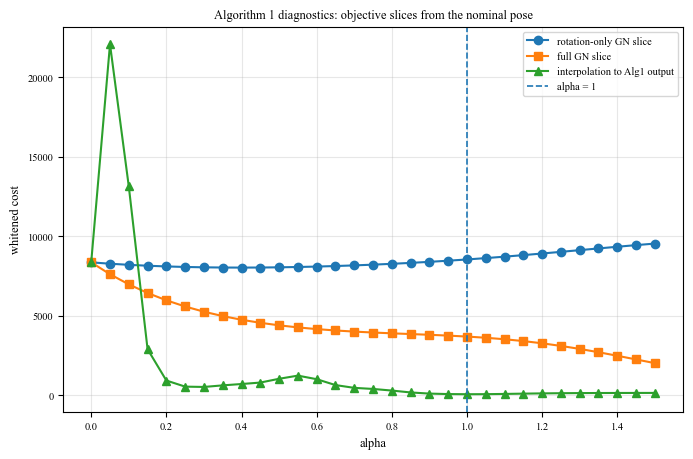

In [30]:
# ======================================================
# Cell C: 1D objective slices for Algorithm 1 diagnostics
# ======================================================

def hat3(w):
    return np.array([
        [0.0,   -w[2],  w[1]],
        [w[2],   0.0,  -w[0]],
        [-w[1],  w[0],  0.0]
    ])

def exp_so3_local(phi):
    theta = np.linalg.norm(phi)
    if theta < 1e-12:
        return np.eye(3) + hat3(phi)
    Kmat = hat3(phi / theta)
    return (
        np.eye(3)
        + np.sin(theta) * Kmat
        + (1.0 - np.cos(theta)) * (Kmat @ Kmat)
    )

def right_retract_pose_local(X_bar, xi):
    phi = xi[:3]
    v = xi[3:]
    R_new = X_bar.R @ exp_so3_local(phi)
    p_new = X_bar.p + v
    return Pose(R=R_new, p=p_new)

alphas = np.linspace(0.0, 1.5, 31)

vals_rot = []
vals_full = []
vals_alg1_interp = []

# 1) rotation-only GN diagnostic slice
for a in alphas:
    X_rot = Pose(
        R=X_WB0.R @ exp_so3_local(a * delta_phi_rot),
        p=X_WB0.p.copy()
    )
    vals_rot.append(pose_cost_whitened(X_rot))

# 2) full GN diagnostic slice
for a in alphas:
    X_full = right_retract_pose_local(X_WB0, a * delta_full)
    vals_full.append(pose_cost_whitened(X_full))

# 3) interpolate from nominal pose to actual Alg1 output
for a in alphas:
    R_interp = X_WB0.R @ exp_so3_local(a * delta_phi_alg1)
    p_interp = X_WB0.p + a * delta_p_alg1
    X_interp = Pose(R=R_interp, p=p_interp)
    vals_alg1_interp.append(pose_cost_whitened(X_interp))

vals_rot = np.array(vals_rot)
vals_full = np.array(vals_full)
vals_alg1_interp = np.array(vals_alg1_interp)

best_a_rot = alphas[np.argmin(vals_rot)]
best_a_full = alphas[np.argmin(vals_full)]
best_a_alg1 = alphas[np.argmin(vals_alg1_interp)]

print("\n===== Slice minima =====")
print("best alpha (rot-only GN) =", best_a_rot)
print("best alpha (full GN)     =", best_a_full)
print("best alpha (Alg1 interp) =", best_a_alg1)

plt.figure(figsize=(8, 5))
plt.plot(alphas, vals_rot, marker='o', label='rotation-only GN slice')
plt.plot(alphas, vals_full, marker='s', label='full GN slice')
plt.plot(alphas, vals_alg1_interp, marker='^', label='interpolation to Alg1 output')
plt.axvline(1.0, linestyle='--', linewidth=1.2, label='alpha = 1')
plt.xlabel('alpha')
plt.ylabel('whitened cost')
plt.title('Algorithm 1 diagnostics: objective slices from the nominal pose')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


===== Slice minima =====
best alpha (rot-only GN) = 0.4
best alpha (full GN)     = 1.5
best alpha (Alg1 interp) = 1.0


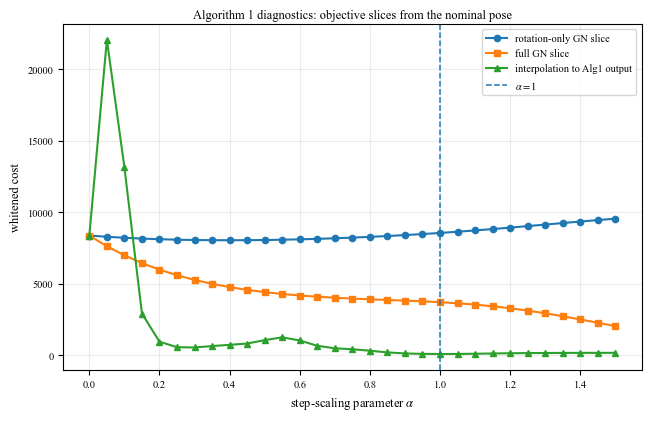

Saved: alg1_objective_slices_paper_final.pdf


In [31]:
# ======================================================
# Cell C: 1D objective slices for Algorithm 1 diagnostics
# Paper-style version consistent with previous figures
# ======================================================

import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Final paper-style plotting setup (same as previous figures)
# =========================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 9,            # base
    "axes.titlesize": 9,       # subplot titles
    "axes.labelsize": 9,
    "legend.fontsize": 7.5,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,
    "figure.titlesize": 10,    # figure title
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

def hat3(w):
    return np.array([
        [0.0,   -w[2],  w[1]],
        [w[2],   0.0,  -w[0]],
        [-w[1],  w[0],  0.0]
    ])

def exp_so3_local(phi):
    theta = np.linalg.norm(phi)
    if theta < 1e-12:
        return np.eye(3) + hat3(phi)
    Kmat = hat3(phi / theta)
    return (
        np.eye(3)
        + np.sin(theta) * Kmat
        + (1.0 - np.cos(theta)) * (Kmat @ Kmat)
    )

def right_retract_pose_local(X_bar, xi):
    phi = xi[:3]
    v = xi[3:]
    R_new = X_bar.R @ exp_so3_local(phi)
    p_new = X_bar.p + v
    return Pose(R=R_new, p=p_new)

alphas = np.linspace(0.0, 1.5, 31)

vals_rot = []
vals_full = []
vals_alg1_interp = []

# 1) rotation-only GN diagnostic slice
for a in alphas:
    X_rot = Pose(
        R=X_WB0.R @ exp_so3_local(a * delta_phi_rot),
        p=X_WB0.p.copy()
    )
    vals_rot.append(pose_cost_whitened(X_rot))

# 2) full GN diagnostic slice
for a in alphas:
    X_full = right_retract_pose_local(X_WB0, a * delta_full)
    vals_full.append(pose_cost_whitened(X_full))

# 3) interpolate from nominal pose to actual Alg1 output
for a in alphas:
    R_interp = X_WB0.R @ exp_so3_local(a * delta_phi_alg1)
    p_interp = X_WB0.p + a * delta_p_alg1
    X_interp = Pose(R=R_interp, p=p_interp)
    vals_alg1_interp.append(pose_cost_whitened(X_interp))

vals_rot = np.array(vals_rot)
vals_full = np.array(vals_full)
vals_alg1_interp = np.array(vals_alg1_interp)

best_a_rot = alphas[np.argmin(vals_rot)]
best_a_full = alphas[np.argmin(vals_full)]
best_a_alg1 = alphas[np.argmin(vals_alg1_interp)]

print("\n===== Slice minima =====")
print("best alpha (rot-only GN) =", best_a_rot)
print("best alpha (full GN)     =", best_a_full)
print("best alpha (Alg1 interp) =", best_a_alg1)

# =========================================================
# Single figure
# =========================================================
fig, ax = plt.subplots(figsize=(6.4, 4.1), constrained_layout=True)

ax.plot(
    alphas, vals_rot,
    marker="o", linewidth=1.5, markersize=4.5,
    label="rotation-only GN slice"
)
ax.plot(
    alphas, vals_full,
    marker="s", linewidth=1.5, markersize=4.5,
    label="full GN slice"
)
ax.plot(
    alphas, vals_alg1_interp,
    marker="^", linewidth=1.5, markersize=4.5,
    label="interpolation to Alg1 output"
)

ax.axvline(1.0, linestyle="--", linewidth=1.1, label=r"$\alpha = 1$")

ax.set_xlabel(r"step-scaling parameter $\alpha$")
ax.set_ylabel("whitened cost")
ax.set_title("Algorithm 1 diagnostics: objective slices from the nominal pose", fontsize=9, pad=4)

ax.grid(True, alpha=0.25, linewidth=0.8)
ax.legend(loc="upper right", frameon=True, fontsize=7.5)

fig.savefig("alg1_objective_slices_paper_final.pdf", bbox_inches="tight")
plt.show()

print("Saved: alg1_objective_slices_paper_final.pdf")

##    Algorithm 2 for testing trust_region version 

In [ ]:
#### trust_region 
theta_star, X_star, history = multi_pass_mfg_batch_refinement(
    theta0,
    X_WB0,
    measurements_Y,
    sensor_poses_WA,
    Sigma_w,
    contact_points_A,
    field_params,
    stiffness_params,
    Tmax=10,
    h_rot=1e-6,
    use_line_search=True,
    rot_gain=1.0,          
    pos_gain=1.0,          
    outer_alpha_candidates=[1.0, 0.5, 0.25, 0.1, 0.05, 0.02],
    use_numeric_rot_candidate=False,   
    verbose=True,
    verbose_inner=False,
    return_history=True,
    X_WB_true=X_WB_true,
)


# =====print results =====
print("\n===== Ground Truth =====")
print("R_true =\n", X_WB_true.R)
print("p_true =", X_WB_true.p)

print("\n===== Estimated MAP Pose =====")
print("R_hat =\n", X_star.R)
print("p_hat =", X_star.p)

print("\n===== Posterior Parameters =====")
print("F_post =\n", theta_star.F)
print("mu_post =", theta_star.mu)
print("Lambda_post =\n", theta_star.Lambda)
print("Gamma_post =\n", theta_star.Gamma)

# ===== 14. print errors =====
rot_err = np.linalg.norm(log_so3(X_WB_true.R.T @ X_star.R))
pos_err = np.linalg.norm(X_WB_true.p - X_star.p)

print("\n===== Estimation Error =====")
print("rotation error (geodesic norm) =", rot_err)
print("position error                 =", pos_err)

||eta|| = 11949523.029500086
||solve(Lambda_post, eta)|| = 0.001774513618615115
||Gamma_post @ nu_Rbar|| = 0.0
p_raw = [ 0.00096598 -0.00059442  0.00136471]
||p_raw|| = 0.001774513618615115
alpha_candidates = [1, 2, 4, 6, 8, 10, 12, 15, 18, 20]
best_alpha = 15
best_p = [ 0.01448975 -0.00891631  0.02047068]
||best_p - X_WB_bar.p|| = 0.026617704279226724
===== Safeguarded Algorithm 2 (block-coordinate version) =====
initial residual norm      = 4.567433e+01
initial whitened res norm  = 9.142517e+01
[note] outer 步长只由 outer_alpha_candidates 控制；
       rot_gain / pos_gain 仅保留接口兼容，不再参与 outer 双重缩步。
||eta|| = 11949523.029500086
||solve(Lambda_post, eta)|| = 0.001774513618615115
||Gamma_post @ nu_Rbar|| = 0.0
p_raw = [ 0.00096598 -0.00059442  0.00136471]
||p_raw|| = 0.001774513618615115
alpha_candidates = [1, 2, 4, 6, 8, 10, 12, 15, 18, 20]
best_alpha = 15
best_p = [ 0.01448975 -0.00891631  0.02047068]
||best_p - X_WB_bar.p|| = 0.026617704279226724

[outer iter 0]
  current white residual = 9.1

In [ ]:
p_hat_stable = X_star.p.copy()
print(R_true)
print(p_hat_stable)
print(p_true)


X_star_stable = Pose(R=X_star.R.copy(), p=X_star.p.copy())
theta_star_stable = MFGParameters(
    F=theta_star.F.copy(),
    mu=theta_star.mu.copy(),
    Lambda=theta_star.Lambda.copy(),
    Gamma=theta_star.Gamma.copy()
)


X_star_stable = Pose(
    R=X_star.R.copy(),
    p=X_star.p.copy()
)

theta_star_stable = MFGParameters(
    F=theta_star.F.copy(),
    mu=theta_star.mu.copy(),
    Lambda=theta_star.Lambda.copy(),
    Gamma=theta_star.Gamma.copy()
)

print("The current stable results have been backed up.")
print("X_star_stable.p =", X_star_stable.p)
print("X_star_stable.R =\n", X_star_stable.R)

[[ 0.9565255  -0.25881905 -0.13443089]
 [ 0.25630024  0.96592583 -0.03602065]
 [ 0.1391731   0.          0.99026807]]
[ 0.01448975 -0.00891631  0.02047068]
[ 0.015 -0.01   0.02 ]
The current stable results have been backed up.
X_star_stable.p = [ 0.01448975 -0.00891631  0.02047068]
X_star_stable.R =
 [[ 0.99996611 -0.00657144  0.00496006]
 [ 0.00646006  0.99973383  0.02214794]
 [-0.00510428 -0.02211515  0.9997424 ]]


In [34]:
import numpy as np
import matplotlib.pyplot as plt


def plot_refinement_history(
    history: dict,
    X_WB_true: Pose = None,
    figsize=(14, 14),
    suptitle="Safeguarded Algorithm 2 Diagnostics",
):
    """
    Visualize history returned by safeguarded multi_pass_mfg_batch_refinement.

    Expected keys in history:
        iter
        accepted
        chosen_alpha
        delta_R
        delta_p
        res_norm
        res_norm_white
        rot_err
        pos_err
        p_x, p_y, p_z
        cand_p_x, cand_p_y, cand_p_z
        best_res_norm_white
        candidate_rot_step
        relaxed_rot_step
        candidate_pos_step
        relaxed_pos_step
        X_t_p, X_candidate_p, X_next_p
    """

    iters = np.asarray(history["iter"], dtype=float)

    accepted = np.asarray(history["accepted"], dtype=bool)
    chosen_alpha = np.asarray(history["chosen_alpha"], dtype=float)

    delta_R = np.asarray(history["delta_R"], dtype=float)
    delta_p = np.asarray(history["delta_p"], dtype=float)

    res_norm = np.asarray(history["res_norm"], dtype=float)
    res_norm_white = np.asarray(history["res_norm_white"], dtype=float)
    best_res_norm_white = np.asarray(history["best_res_norm_white"], dtype=float)

    rot_err = np.asarray(history["rot_err"], dtype=float)
    pos_err = np.asarray(history["pos_err"], dtype=float)

    p_x = np.asarray(history["p_x"], dtype=float)
    p_y = np.asarray(history["p_y"], dtype=float)
    p_z = np.asarray(history["p_z"], dtype=float)

    cand_p_x = np.asarray(history["cand_p_x"], dtype=float)
    cand_p_y = np.asarray(history["cand_p_y"], dtype=float)
    cand_p_z = np.asarray(history["cand_p_z"], dtype=float)

    candidate_rot_step = np.asarray(history["candidate_rot_step"], dtype=float)
    relaxed_rot_step = np.asarray(history["relaxed_rot_step"], dtype=float)
    candidate_pos_step = np.asarray(history["candidate_pos_step"], dtype=float)
    relaxed_pos_step = np.asarray(history["relaxed_pos_step"], dtype=float)

    fig, axes = plt.subplots(3, 2, figsize=figsize)
    axes = axes.ravel()

    # =========================================================
    # 1) Error vs outer iteration
    # =========================================================
    ax = axes[0]
    if np.isfinite(rot_err).any():
        ax.plot(iters, rot_err, marker="o", label="rotation error")
    if np.isfinite(pos_err).any():
        ax.plot(iters, pos_err, marker="s", label="position error")

    # 标记 rejected steps
    rej_idx = np.where(~accepted)[0]
    if len(rej_idx) > 0:
        y_ref = np.nanmax(rot_err) if np.isfinite(rot_err).any() else 0.0
        ax.scatter(iters[rej_idx], np.full_like(iters[rej_idx], y_ref),
                   marker="x", s=80, label="rejected step")

    ax.set_title("Error vs Outer Iteration")
    ax.set_xlabel("outer iteration")
    ax.set_ylabel("error")
    ax.grid(True)
    ax.legend()

    # =========================================================
    # 2) Residual norms
    # =========================================================
    ax = axes[1]
    ax.plot(iters, res_norm, marker="o", label="residual norm")
    ax.plot(iters, res_norm_white, marker="s", label="whitened residual norm")
    ax.plot(iters, best_res_norm_white, marker="^", label="best-so-far whitened")

    if len(rej_idx) > 0:
        y_rej = np.interp(iters[rej_idx], iters, res_norm_white)
        ax.scatter(iters[rej_idx], y_rej, marker="x", s=80, label="rejected step")

    ax.set_title("Residual Norms vs Outer Iteration")
    ax.set_xlabel("outer iteration")
    ax.set_ylabel("norm")
    ax.grid(True)
    ax.legend()

    # =========================================================
    # 3) Accepted / rejected + chosen alpha
    # =========================================================
    ax = axes[2]
    accepted_num = accepted.astype(float)
    ax.step(iters, accepted_num, where="mid", label="accepted (1=yes, 0=no)")
    ax.plot(iters, chosen_alpha, marker="o", label="chosen alpha")
    ax.set_title("Acceptance and Chosen Alpha")
    ax.set_xlabel("outer iteration")
    ax.set_ylabel("value")
    ax.set_yticks([0.0, 0.5, 1.0])
    ax.grid(True)
    ax.legend()

    # =========================================================
    # 4) Relaxed update sizes
    # =========================================================
    ax = axes[3]
    ax.plot(iters, delta_R, marker="o", label="delta_R")
    ax.plot(iters, delta_p, marker="s", label="delta_p")

    if len(rej_idx) > 0:
        ax.scatter(iters[rej_idx], delta_R[rej_idx], marker="x", s=80, label="rejected step")

    ax.set_title("Relaxed Update Sizes")
    ax.set_xlabel("outer iteration")
    ax.set_ylabel("step size")
    ax.grid(True)
    ax.legend()

    # =========================================================
    # 5) Translation components
    # =========================================================
    ax = axes[4]
    ax.plot(iters, p_x, marker="o", label="p_x")
    ax.plot(iters, p_y, marker="s", label="p_y")
    ax.plot(iters, p_z, marker="^", label="p_z")

    if X_WB_true is not None:
        ax.axhline(X_WB_true.p[0], linestyle="--", label="p_x true")
        ax.axhline(X_WB_true.p[1], linestyle="--", label="p_y true")
        ax.axhline(X_WB_true.p[2], linestyle="--", label="p_z true")

    if len(rej_idx) > 0:
        ax.scatter(iters[rej_idx], p_x[rej_idx], marker="x", s=80, label="rejected step")

    ax.set_title("Translation Components vs Outer Iteration")
    ax.set_xlabel("outer iteration")
    ax.set_ylabel("translation component")
    ax.grid(True)
    ax.legend()

    # =========================================================
    # 6) Candidate vs relaxed outer steps
    # =========================================================
    ax = axes[5]
    ax.plot(iters, candidate_rot_step, marker="o", label="candidate rot step")
    ax.plot(iters, relaxed_rot_step, marker="s", label="relaxed rot step")
    ax.plot(iters, candidate_pos_step, marker="^", label="candidate pos step")
    ax.plot(iters, relaxed_pos_step, marker="d", label="relaxed pos step")

    if len(rej_idx) > 0:
        ax.scatter(iters[rej_idx], candidate_rot_step[rej_idx], marker="x", s=80, label="rejected step")

    ax.set_title("Candidate vs Relaxed Outer Steps")
    ax.set_xlabel("outer iteration")
    ax.set_ylabel("step size")
    ax.grid(True)
    ax.legend()

    fig.suptitle(suptitle, fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


    

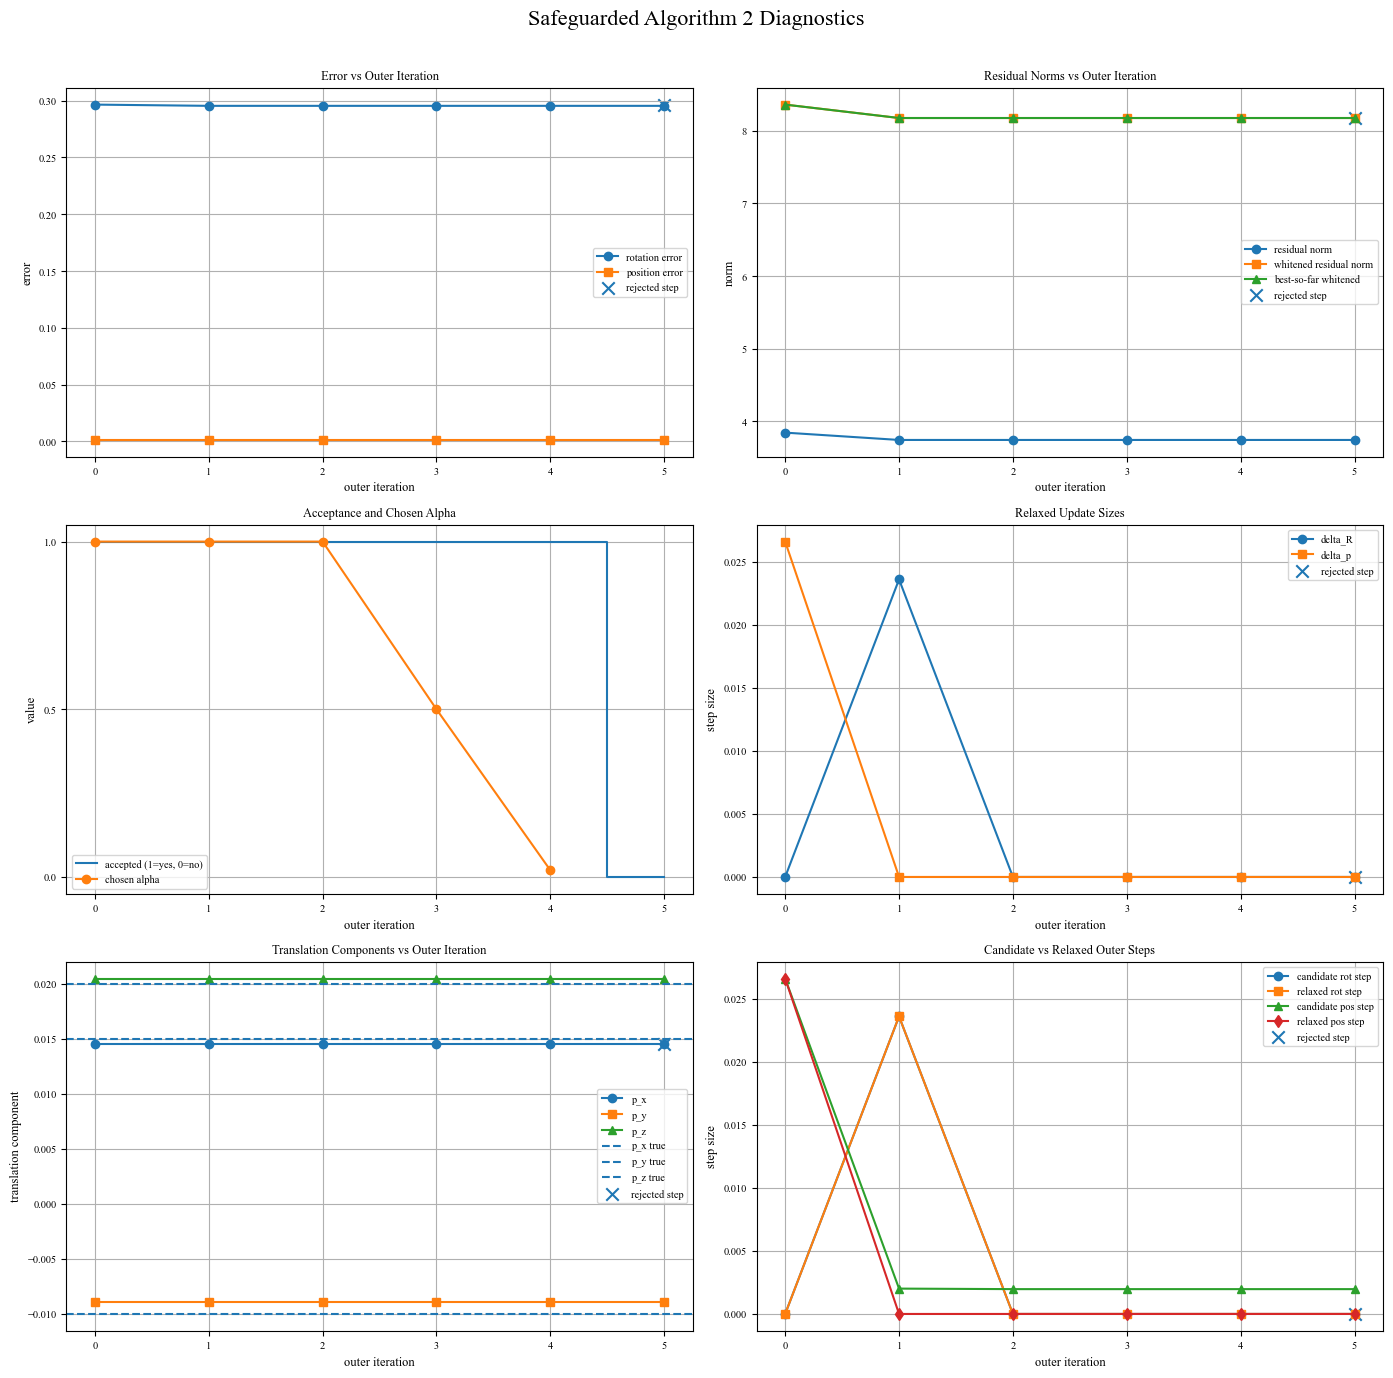

In [35]:
plot_refinement_history(
    history,
    X_WB_true=X_WB_true,
    figsize=(14, 14),
    suptitle="Safeguarded Algorithm 2 Diagnostics"
)

In [36]:
print("iters        =", history["iter"])
print("accepted     =", history["accepted"])
print("chosen_alpha =", history["chosen_alpha"])
print("best white   =", history["best_res_norm_white"][-1])

iters        = [0, 1, 2, 3, 4, 5]
accepted     = [True, True, True, True, True, False]
chosen_alpha = [1.0, 1.0, 1.0, 0.5, 0.02, nan]
best white   = 8.173658172787038


# Hessian report 

## Check if the current data volume provides insufficient Hessian information. If all feature values ​​are negative, it indicates that the information is not very good.

In [37]:
R_mode_B = recover_pose_from_theta(theta_star).R

rot_info_B = rotation_information_report(
    X_center=X_star,
    p_fixed=X_star.p,
    measurements_Y=measurements_Y,
    sensor_poses_WA=sensor_poses_WA,
    Sigma_w=Sigma_w,
    contact_points_A=contact_points_A,
    field_params=field_params,
    stiffness_params=stiffness_params,
    h_phi=1e-3,
    X_WB_true=X_WB_true,
    R_mode=R_mode_B,
    verbose=True,
)


===== Rotation Information / Hessian Diagnostic =====
white0            = 8.173658e+00
f0                = 3.340434e+01
||grad||          = 6.342876e+01
grad              = [63.23153028 -1.6783344  -4.70794052]
Hessian H =
[[262.85970063 -50.6852211  -96.93956309]
 [-50.6852211   57.71076003  50.01627096]
 [-96.93956309  50.01627096  40.82416716]]
eigvals(H)        = [-10.8750203   56.48616244 315.78348568]
trace(H)          = 3.613946e+02
lam_min           = -1.087502e+01
lam_mid           = 5.648616e+01
lam_max           = 3.157835e+02
|lam_min|/|lam_max| = 3.443822e-02
cond_abs          = 2.903751e+01

--- directional curvature / derivative ---
[eig_weak] dir_deriv = 1.051470e+01, dir_curv = -1.044938e+01
[eig_strong] dir_deriv = -5.896298e+01, dir_curv = 3.157727e+02
[neg_grad] dir_deriv = -6.342911e+01, dir_curv = 2.797659e+02
[mode] dir_deriv = 6.077157e+01, dir_curv = 3.116670e+02
[truth] dir_deriv = 5.172766e+00, dir_curv = -7.902536e+00

mode_step         = 2.394341e-15
dphi_

#  Check the consistency (self-consistency) between the model and the numerical algorithm implementation.

In [ ]:
# =========================================
# Noiseless truth stationarity diagnostics
# =========================================
###  noiseless measurements
import numpy as np

def generate_noiseless_measurements_truth(
    X_WB_true: Pose,
    sensor_poses_WA,
    contact_points_A: np.ndarray,
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters,
) -> np.ndarray:
    """
    Generate noiseless measurements at the true value X_WB_true using the current measurement_model_y:
        y_k = measurement_model_y(X_WA_k, X_WB_true, ...)
    return shape = (K, 6)
    """
    Y = []
    for X_WA_k in sensor_poses_WA:
        y_k = measurement_model_y(
            X_WA=X_WA_k,
            X_WB=X_WB_true,
            contact_points_A=contact_points_A,
            field_params=field_params,
            stiffness_params=stiffness_params,
        )
        Y.append(np.asarray(y_k, dtype=float).reshape(6))
    return np.asarray(Y, dtype=float)

### noiseless truth stationarity test 
def run_noiseless_truth_stationarity_test(
    theta_prior_test: MFGParameters,
    X_WB_true: Pose,
    sensor_poses_WA,
    Sigma_w: np.ndarray,
    contact_points_A: np.ndarray,
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters,
    h_rot_alg1: float = 1e-6,
    alpha_candidates=None,
    h_phi_diag: float = 1e-3,
    use_line_search: bool = True,
    verbose: bool = True,
):
    """
    First-level model consistency check:
    1) Generate noiseless data at the true value using the current measurement_model_y
    2) Check if the residual at the true point is close to 0
    3) Run a single_pass_mfg_posterior_update with the true value as the nominal
    4) Check if the recovered mode is still near the true value
    5) Perform fixed-p rotation Hessian / gradient diagnostics at the true point
    """

    if alpha_candidates is None:
        alpha_candidates = [1, 2, 4, 6, 8, 10, 12, 15, 18, 20]

    # --------------------------------------------------
    # Step 1: noiseless measurements at truth
    # --------------------------------------------------
    measurements_Y_noiseless = generate_noiseless_measurements_truth(
        X_WB_true=X_WB_true,
        sensor_poses_WA=sensor_poses_WA,
        contact_points_A=contact_points_A,
        field_params=field_params,
        stiffness_params=stiffness_params,
    )

    # --------------------------------------------------
    # Step 2: residual at truth
    # --------------------------------------------------
    res_truth = batch_residual_norm(
        X_WB_true,
        measurements_Y_noiseless,
        sensor_poses_WA,
        contact_points_A,
        field_params,
        stiffness_params,
    )

    white_truth = batch_whitened_residual_norm(
        X_WB_true,
        measurements_Y_noiseless,
        sensor_poses_WA,
        Sigma_w,
        contact_points_A,
        field_params,
        stiffness_params,
    )

    # --------------------------------------------------
    # Step 3: one posterior update at truth-as-nominal
    # --------------------------------------------------
    theta_post_truth = single_pass_mfg_posterior_update(
        theta_prior=theta_prior_test,
        X_WB_bar=X_WB_true,
        measurements_Y=measurements_Y_noiseless,
        sensor_poses_WA=sensor_poses_WA,
        Sigma_w=Sigma_w,
        contact_points_A=contact_points_A,
        field_params=field_params,
        stiffness_params=stiffness_params,
        h_rot=h_rot_alg1,
        alpha_candidates=alpha_candidates,
        use_line_search=use_line_search,
        verbose_inner=False,
    )

    X_mode_truth = recover_pose_from_theta(theta_post_truth)

    mode_rot_gap = np.linalg.norm(log_so3(X_WB_true.R.T @ X_mode_truth.R))
    mode_pos_gap = np.linalg.norm(X_WB_true.p - X_mode_truth.p)

    # --------------------------------------------------
    # Step 4: fixed-p rotation Hessian diagnostic at truth
    # --------------------------------------------------
    rot_info_truth = rotation_information_report(
        X_center=X_WB_true,
        p_fixed=X_WB_true.p,
        measurements_Y=measurements_Y_noiseless,
        sensor_poses_WA=sensor_poses_WA,
        Sigma_w=Sigma_w,
        contact_points_A=contact_points_A,
        field_params=field_params,
        stiffness_params=stiffness_params,
        h_phi=h_phi_diag,
        X_WB_true=X_WB_true,
        R_mode=X_mode_truth.R,
        verbose=verbose,
    )

    if verbose:
        print("\n===== Noiseless Truth Stationarity Test =====")
        print(f"residual norm at truth            = {res_truth:.6e}")
        print(f"whitened residual at truth        = {white_truth:.6e}")
        print(f"mode rotation gap from truth      = {mode_rot_gap:.6e}")
        print(f"mode position gap from truth      = {mode_pos_gap:.6e}")
        print("mu_post - p_true                  =", theta_post_truth.mu - X_WB_true.p)
        print("R_mode =")
        print(X_mode_truth.R)

    return {
        "measurements_Y_noiseless": measurements_Y_noiseless,
        "theta_post_truth": theta_post_truth,
        "X_mode_truth": X_mode_truth,
        "res_truth": res_truth,
        "white_truth": white_truth,
        "mode_rot_gap": mode_rot_gap,
        "mode_pos_gap": mode_pos_gap,
        "rot_info_truth": rot_info_truth,
    }





In [ ]:
truth_test = run_noiseless_truth_stationarity_test(
    theta_prior_test=theta0,   
    X_WB_true=X_WB_true,
    sensor_poses_WA=sensor_poses_WA,
    Sigma_w=Sigma_w,
    contact_points_A=contact_points_A,
    field_params=field_params,
    stiffness_params=stiffness_params,
    h_rot_alg1=1e-6,
    alpha_candidates=[1, 2, 4, 6, 8, 10, 12, 15, 18, 20],
    h_phi_diag=1e-3,   
    use_line_search=True,
    verbose=True,
)

||eta|| = 616970.0467181854
||solve(Lambda_post, eta)|| = 0.0269256175343492
||Gamma_post @ nu_Rbar|| = 19352.789526773402
p_raw = [ 0.01500018 -0.00999985  0.01999966]
||p_raw|| = 0.0269256175343492
alpha_candidates = [1, 2, 4, 6, 8, 10, 12, 15, 18, 20]
best_alpha = 1
best_p = [ 0.01500018 -0.00999985  0.01999966]
||best_p - X_WB_bar.p|| = 4.1167123120005965e-07

===== Rotation Information / Hessian Diagnostic =====
white0            = 0.000000e+00
f0                = 0.000000e+00
||grad||          = 1.272010e-03
grad              = [-1.25859635e-03  5.87357430e-05  1.74630904e-04]
Hessian H =
[[ 521.52905592   80.82506695 -196.10979318]
 [  80.82506695  136.16035958  -44.62827277]
 [-196.10979318  -44.62827277   89.933457  ]]
eigvals(H)        = [ 12.70703041 120.09688875 614.81895334]
trace(H)          = 7.476229e+02
lam_min           = 1.270703e+01
lam_mid           = 1.200969e+02
lam_max           = 6.148190e+02
|lam_min|/|lam_max| = 2.066792e-02
cond_abs          = 4.838416e+01



In [40]:
truth_test_half = run_noiseless_truth_stationarity_test(
    theta_prior_test=theta0,
    X_WB_true=X_WB_true,
    sensor_poses_WA=sensor_poses_WA,
    Sigma_w=Sigma_w,
    contact_points_A=contact_points_A,
    field_params=field_params,
    stiffness_params=stiffness_params,
    h_rot_alg1=1e-6,
    alpha_candidates=[1, 2, 4, 6, 8, 10, 12, 15, 18, 20],
    h_phi_diag=5e-4,
    use_line_search=True,
    verbose=True,
)

||eta|| = 616970.0467181854
||solve(Lambda_post, eta)|| = 0.0269256175343492
||Gamma_post @ nu_Rbar|| = 19352.789526773402
p_raw = [ 0.01500018 -0.00999985  0.01999966]
||p_raw|| = 0.0269256175343492
alpha_candidates = [1, 2, 4, 6, 8, 10, 12, 15, 18, 20]
best_alpha = 1
best_p = [ 0.01500018 -0.00999985  0.01999966]
||best_p - X_WB_bar.p|| = 4.1167123120005965e-07

===== Rotation Information / Hessian Diagnostic =====
white0            = 0.000000e+00
f0                = 0.000000e+00
||grad||          = 3.183209e-04
grad              = [-3.14850190e-04  1.51531066e-05  4.43611381e-05]
Hessian H =
[[ 521.52642359   80.83379039 -196.1067357 ]
 [  80.83379039  136.16032921  -44.62473348]
 [-196.1067357   -44.62473348   89.93642478]]
eigvals(H)        = [ 12.71268241 120.09284483 614.81765034]
trace(H)          = 7.476232e+02
lam_min           = 1.271268e+01
lam_mid           = 1.200928e+02
lam_max           = 6.148177e+02
|lam_min|/|lam_max| = 2.067716e-02
cond_abs          = 4.836254e+01



# channel ablation  (Testing to provide support for setting different weights for Experiment E)
## In real-world data, which channel skewed the truth direction?



In [ ]:
import numpy as np

def residual_single_current_convention(
    X_WB: Pose,
    measurement_y_k: np.ndarray,
    sensor_pose_WA_k: Pose,
    contact_points_A: np.ndarray,
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters,
):
    """
    Current residual convention:
        r_k(X) = y_k - measurement_model_y(X_A_k, X_B)
    """
    y_pred = measurement_model_y(
        X_WA=sensor_pose_WA_k,
        X_WB=X_WB,
        contact_points_A=contact_points_A,
        field_params=field_params,
        stiffness_params=stiffness_params,
    )
    r = np.asarray(measurement_y_k, dtype=float).reshape(6) - np.asarray(y_pred, dtype=float).reshape(6)
    return r


def residual_stack_current_convention(
    X_WB: Pose,
    measurements_Y: np.ndarray,
    sensor_poses_WA,
    contact_points_A: np.ndarray,
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters,
):
    """
    Stack the residuals of all measurements into shape (6K,).
    """
    rs = []
    for k in range(len(sensor_poses_WA)):
        rk = residual_single_current_convention(
            X_WB=X_WB,
            measurement_y_k=measurements_Y[k],
            sensor_pose_WA_k=sensor_poses_WA[k],
            contact_points_A=contact_points_A,
            field_params=field_params,
            stiffness_params=stiffness_params,
        )
        rs.append(rk.reshape(-1))
    return np.concatenate(rs, axis=0)

In [ ]:
def rotation_objective_fixed_p_variant(
    phi: np.ndarray,
    X_center: Pose,
    p_fixed: np.ndarray,
    measurements_Y: np.ndarray,
    sensor_poses_WA,
    Sigma_w: np.ndarray,
    contact_points_A: np.ndarray,
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters,
    variant: str = "full_whitened",
):
    """
    variant:
      - full_whitened   : Current complete whitened objective
      - torque_only     : Only look at torque first 3 dimensions
      - force_only      : Only look at force last 3 dimensions
      - full_unweighted : Unweighted L2 norm without Sigma_w^{-1}
    """
    X_eval = Pose(
        R=X_center.R @ so3_exp(phi),
        p=p_fixed.copy(),
    )

    r_stack = residual_stack_current_convention(
        X_WB=X_eval,
        measurements_Y=measurements_Y,
        sensor_poses_WA=sensor_poses_WA,
        contact_points_A=contact_points_A,
        field_params=field_params,
        stiffness_params=stiffness_params,
    )

    K = len(sensor_poses_WA)

    if variant == "full_whitened":
        val = 0.0
        for k in range(K):
            rk = r_stack[6*k:6*(k+1)]
            val += 0.5 * rk.T @ np.linalg.solve(Sigma_w, rk)
        return float(val)

    elif variant == "torque_only":
        Sigma_tau = Sigma_w[:3, :3]
        val = 0.0
        for k in range(K):
            rk = r_stack[6*k:6*k+3]
            val += 0.5 * rk.T @ np.linalg.solve(Sigma_tau, rk)
        return float(val)

    elif variant == "force_only":
        Sigma_f = Sigma_w[3:, 3:]
        val = 0.0
        for k in range(K):
            rk = r_stack[6*k+3:6*(k+1)]
            val += 0.5 * rk.T @ np.linalg.solve(Sigma_f, rk)
        return float(val)

    elif variant == "full_unweighted":
        return 0.5 * float(r_stack @ r_stack)

    else:
        raise ValueError(f"unknown variant: {variant}")

In [ ]:
def directional_derivative_variant(
    u: np.ndarray,
    X_center: Pose,
    p_fixed: np.ndarray,
    measurements_Y: np.ndarray,
    sensor_poses_WA,
    Sigma_w: np.ndarray,
    contact_points_A: np.ndarray,
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters,
    variant: str = "full_whitened",
    h_dir: float = 1e-3,
):
    """
    Given a direction u, calculate:

    - First-order directional derivative

    - Second-order directional curvature
    """
    u = np.asarray(u, dtype=float)
    nu = np.linalg.norm(u)
    if nu < 1e-15:
        return {"dir_deriv": np.nan, "dir_curv": np.nan}

    u = u / nu

    def f(alpha):
        return rotation_objective_fixed_p_variant(
            phi=alpha * u,
            X_center=X_center,
            p_fixed=p_fixed,
            measurements_Y=measurements_Y,
            sensor_poses_WA=sensor_poses_WA,
            Sigma_w=Sigma_w,
            contact_points_A=contact_points_A,
            field_params=field_params,
            stiffness_params=stiffness_params,
            variant=variant,
        )

    f0 = f(0.0)
    fp = f(h_dir)
    fm = f(-h_dir)

    dir_deriv = (fp - fm) / (2.0 * h_dir)
    dir_curv = (fp - 2.0 * f0 + fm) / (h_dir ** 2)

    return {"dir_deriv": dir_deriv, "dir_curv": dir_curv}

In [ ]:
def ablation_report_truth_direction(
    X_center: Pose,
    p_fixed: np.ndarray,
    X_WB_true: Pose,
    measurements_Y: np.ndarray,
    sensor_poses_WA,
    Sigma_w: np.ndarray,
    contact_points_A: np.ndarray,
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters,
    h_dir: float = 1e-3,
):
    """
    At the current fixed-p point, compare whether the truth direction is the descent direction under different objectives.
    """
    dphi_truth = log_so3(X_center.R.T @ X_WB_true.R)
    truth_step = np.linalg.norm(dphi_truth)

    print("\n===== Truth-direction ablation report =====")
    print("truth_step =", truth_step)
    print("dphi_truth =", dphi_truth)

    variants = ["full_whitened", "torque_only", "force_only", "full_unweighted"]

    out = {}
    for v in variants:
        info = directional_derivative_variant(
            u=dphi_truth,
            X_center=X_center,
            p_fixed=p_fixed,
            measurements_Y=measurements_Y,
            sensor_poses_WA=sensor_poses_WA,
            Sigma_w=Sigma_w,
            contact_points_A=contact_points_A,
            field_params=field_params,
            stiffness_params=stiffness_params,
            variant=v,
            h_dir=h_dir,
        )
        out[v] = info
        print(f"[{v}] dir_deriv = {info['dir_deriv']:.6e}, dir_curv = {info['dir_curv']:.6e}")

    return out

In [45]:
ablation_B = ablation_report_truth_direction(
    X_center=X_star,
    p_fixed=X_star.p,
    X_WB_true=X_WB_true,
    measurements_Y=measurements_Y,
    sensor_poses_WA=sensor_poses_WA,
    Sigma_w=Sigma_w,
    contact_points_A=contact_points_A,
    field_params=field_params,
    stiffness_params=stiffness_params,
    h_dir=1e-3,
)


===== Truth-direction ablation report =====
truth_step = 0.29542605420474205
dphi_truth = [ 0.03913533 -0.14676143  0.25338915]
[full_whitened] dir_deriv = 5.172766e+00, dir_curv = -7.902536e+00
[torque_only] dir_deriv = -5.574763e-02, dir_curv = 7.902912e-02
[force_only] dir_deriv = 5.228514e+00, dir_curv = -7.981565e+00
[full_unweighted] dir_deriv = 1.304899e+00, dir_curv = -1.992230e+00


In [46]:
ablation_B_half = ablation_report_truth_direction(
    X_center=X_star,
    p_fixed=X_star.p,
    X_WB_true=X_WB_true,
    measurements_Y=measurements_Y,
    sensor_poses_WA=sensor_poses_WA,
    Sigma_w=Sigma_w,
    contact_points_A=contact_points_A,
    field_params=field_params,
    stiffness_params=stiffness_params,
    h_dir=5e-4,
)


===== Truth-direction ablation report =====
truth_step = 0.29542605420474205
dphi_truth = [ 0.03913533 -0.14676143  0.25338915]
[full_whitened] dir_deriv = 5.171900e+00, dir_curv = -3.457357e+00
[torque_only] dir_deriv = -5.574498e-02, dir_curv = 7.535260e-02
[force_only] dir_deriv = 5.227645e+00, dir_curv = -3.532710e+00
[full_unweighted] dir_deriv = 1.304681e+00, dir_curv = -8.801634e-01


# Variant D
## Add a new experiment: In alg2, replace the objective of the rot_only branch with torque_only, leaving everything else unchanged.

## Rotation is mainly identified through torque/lever arm information.

#### Translation is more easily supported by force and the overall full residual.

#### Sigma_w makes the weight of the force component relatively too large, suppressing the "correct rotation information" already given by torque.




In [ ]:
#### 
theta_star, X_star, history = multi_pass_mfg_batch_refinement(
    theta0,
    X_WB0,
    measurements_Y,
    sensor_poses_WA,
    Sigma_w,
    contact_points_A,
    field_params,
    stiffness_params,
    Tmax=10,
    h_rot=1e-6,
    use_line_search=True,
    rot_gain=1.0,          
    pos_gain=1.0,          
    outer_alpha_candidates=[1.0, 0.5, 0.25, 0.1, 0.05, 0.02],
    use_numeric_rot_candidate=True,   
    #h_rot_numgrad=1e-5,
    rot_goal_step_candidates=[0.005, 0.01, 0.02],  
    verbose=True,
    verbose_inner=False,
    return_history=True,
    X_WB_true=X_WB_true,
)



print("\n===== Ground Truth =====")
print("R_true =\n", X_WB_true.R)
print("p_true =", X_WB_true.p)

print("\n===== Estimated MAP Pose =====")
print("R_hat =\n", X_star.R)
print("p_hat =", X_star.p)

print("\n===== Posterior Parameters =====")
print("F_post =\n", theta_star.F)
print("mu_post =", theta_star.mu)
print("Lambda_post =\n", theta_star.Lambda)
print("Gamma_post =\n", theta_star.Gamma)

# ===== 14. print errors =====
rot_err = np.linalg.norm(log_so3(X_WB_true.R.T @ X_star.R))
pos_err = np.linalg.norm(X_WB_true.p - X_star.p)

print("\n===== Estimation Error =====")
print("rotation error (geodesic norm) =", rot_err)
print("position error                 =", pos_err)

||eta|| = 11949523.029500086
||solve(Lambda_post, eta)|| = 0.001774513618615115
||Gamma_post @ nu_Rbar|| = 0.0
p_raw = [ 0.00096598 -0.00059442  0.00136471]
||p_raw|| = 0.001774513618615115
alpha_candidates = [1, 2, 4, 6, 8, 10, 12, 15, 18, 20]
best_alpha = 15
best_p = [ 0.01448975 -0.00891631  0.02047068]
||best_p - X_WB_bar.p|| = 0.026617704279226724
===== Safeguarded Algorithm 2 (block-coordinate version) =====
initial residual norm      = 4.567433e+01
initial whitened res norm  = 9.142517e+01
[note] outer 步长只由 outer_alpha_candidates 控制；
       rot_gain / pos_gain 仅保留接口兼容，不再参与 outer 双重缩步。
||eta|| = 11949523.029500086
||solve(Lambda_post, eta)|| = 0.001774513618615115
||Gamma_post @ nu_Rbar|| = 0.0
p_raw = [ 0.00096598 -0.00059442  0.00136471]
||p_raw|| = 0.001774513618615115
alpha_candidates = [1, 2, 4, 6, 8, 10, 12, 15, 18, 20]
best_alpha = 15
best_p = [ 0.01448975 -0.00891631  0.02047068]
||best_p - X_WB_bar.p|| = 0.026617704279226724

[outer iter 0]
  current white residual = 9.1

# Experiment E Results Display: Based on the previous experiment, the weight of force was reduced.

In [29]:
def residual_single_current_convention(
    X_WB: Pose,
    measurement_y_k: np.ndarray,
    sensor_pose_WA_k: Pose,
    contact_points_A: np.ndarray,
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters,
):
    y_pred = measurement_model_y(
        X_WA=sensor_pose_WA_k,
        X_WB=X_WB,
        contact_points_A=contact_points_A,
        field_params=field_params,
        stiffness_params=stiffness_params,
    )
    r = np.asarray(measurement_y_k, dtype=float).reshape(6) - np.asarray(y_pred, dtype=float).reshape(6)
    return r


def residual_stack_current_convention(
    X_WB: Pose,
    measurements_Y: np.ndarray,
    sensor_poses_WA,
    contact_points_A: np.ndarray,
    field_params: SuperquadricFieldParameters,
    stiffness_params: StiffnessParameters,
):
    rs = []
    for k in range(len(sensor_poses_WA)):
        rk = residual_single_current_convention(
            X_WB=X_WB,
            measurement_y_k=measurements_Y[k],
            sensor_pose_WA_k=sensor_poses_WA[k],
            contact_points_A=contact_points_A,
            field_params=field_params,
            stiffness_params=stiffness_params,
        )
        rs.append(rk.reshape(-1))
    return np.concatenate(rs, axis=0)

In [ ]:
theta_star, X_star, history = multi_pass_mfg_batch_refinement(
    theta0,
    X_WB0,
    measurements_Y,
    sensor_poses_WA,
    Sigma_w,
    contact_points_A,
    field_params,
    stiffness_params,
    Tmax=10,
    h_rot=1e-6,
    use_line_search=True,
    rot_gain=1.0,
    pos_gain=1.0,
    outer_alpha_candidates=[1.0, 0.5, 0.25, 0.1, 0.05, 0.02],
    use_numeric_rot_candidate=True,
    h_rot_numgrad=1e-5,
    rot_goal_step_candidates=[0.005, 0.01, 0.02],
    rot_force_beta=100.0,          
    rot_white_guard_eps=0.01,     
    verbose=True,
    verbose_inner=False,
    return_history=True,
    X_WB_true=X_WB_true,
)

### The force weight is the reciprocal of beta. Setting it to 50 here means the force weight is 50 times larger than the rotation weight,
# ### encouraging numerical candidates to be more aggressive in rotation.

||eta|| = 11949523.029500086
||solve(Lambda_post, eta)|| = 0.001774513618615115
||Gamma_post @ nu_Rbar|| = 0.0
p_raw = [ 0.00096598 -0.00059442  0.00136471]
||p_raw|| = 0.001774513618615115
alpha_candidates = [1, 2, 4, 6, 8, 10, 12, 15, 18, 20]
best_alpha = 15
best_p = [ 0.01448975 -0.00891631  0.02047068]
||best_p - X_WB_bar.p|| = 0.026617704279226724
===== Safeguarded Algorithm 2 (block-coordinate version) =====
initial residual norm      = 4.567433e+01
initial whitened res norm  = 9.142517e+01
[note] outer 步长只由 outer_alpha_candidates 控制；
       rot_gain / pos_gain 仅保留接口兼容，不再参与 outer 双重缩步。
       rot_force_beta = 100.0
       rot_white_guard_eps = 0.01
||eta|| = 11949523.029500086
||solve(Lambda_post, eta)|| = 0.001774513618615115
||Gamma_post @ nu_Rbar|| = 0.0
p_raw = [ 0.00096598 -0.00059442  0.00136471]
||p_raw|| = 0.001774513618615115
alpha_candidates = [1, 2, 4, 6, 8, 10, 12, 15, 18, 20]
best_alpha = 15
best_p = [ 0.01448975 -0.00891631  0.02047068]
||best_p - X_WB_bar.p|| = 0.0

No matter how large beta is, it cannot fundamentally improve the situation.

# ABCDE Experimental comparison chart

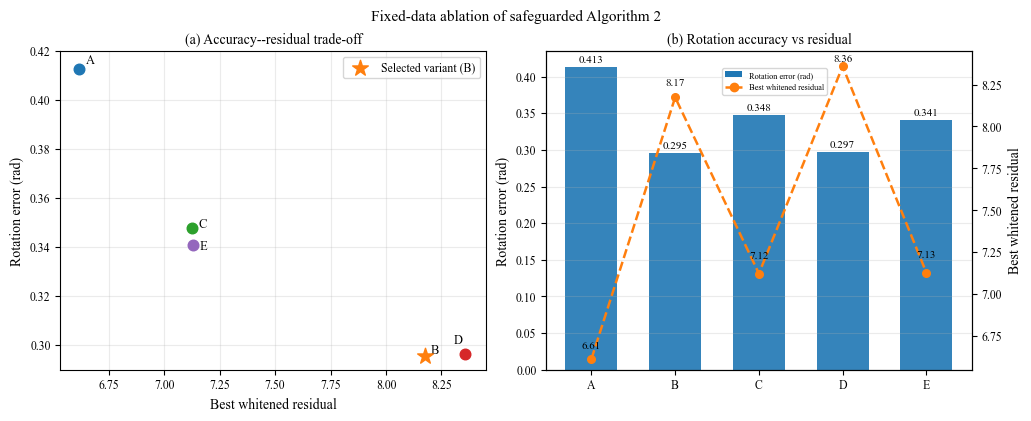

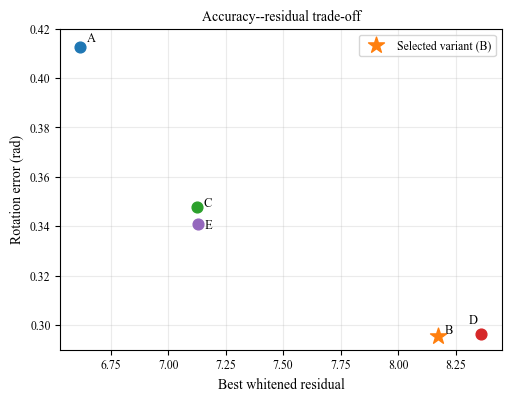

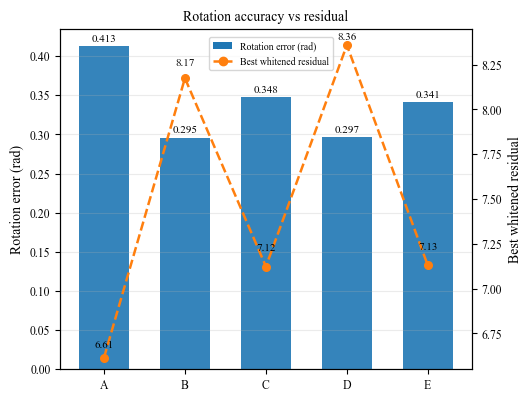

Saved:
  alg2_ablation_main_aux.pdf
  alg2_ablation_pareto.pdf
  alg2_ablation_barline.pdf


In [47]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Fixed-data ablation results of safeguarded Algorithm 2
# =========================================================

variants = ["A", "B", "C", "D", "E"]

best_iter = np.array([9, 1, 9, 0, 9], dtype=float)
best_white = np.array([6.614007, 8.173658, 7.123307, 8.358175, 7.129081], dtype=float)
rot_err = np.array([0.412686, 0.295426, 0.347766, 0.296518, 0.340989], dtype=float)
pos_err = np.array([0.00128697, 0.00128697, 0.00128697, 0.00128697, 0.00128697], dtype=float)

highlight_variant = "B"
highlight_idx = variants.index(highlight_variant)

# ---------------------------------------------------------
# Paper-style plotting setup
# ---------------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 8.5,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =========================================================
# Figure 1: Main + Auxiliary
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.1), constrained_layout=True)

# -------------------------
# (a) Main plot: Pareto scatter
# -------------------------
ax = axes[0]

for i, v in enumerate(variants):
    if i == highlight_idx:
        ax.scatter(
            best_white[i], rot_err[i],
            s=140, marker="*", zorder=5,
            label="Selected variant (B)"
        )
    else:
        ax.scatter(best_white[i], rot_err[i], s=58, zorder=4)

label_offsets = {
    "A": (0.03,  0.001),
    "B": (0.03, 0.005),
    "C": (0.03,  -0.001),
    "D": (-0.01, 0.003),
    "E": (0.03,  -0.003),
}
label_align = {
    "A": ("left", "bottom"),
    "B": ("left", "top"),
    "C": ("left", "bottom"),
    "D": ("right", "bottom"),
    "E": ("left", "bottom"),
}

for i, v in enumerate(variants):
    dx, dy = label_offsets[v]
    ha, va = label_align[v]
    ax.text(
        best_white[i] + dx,
        rot_err[i] + dy,
        v,
        fontsize=9,
        ha=ha,
        va=va,
    )

ax.set_xlabel("Best whitened residual")
ax.set_ylabel("Rotation error (rad)")
ax.set_title("(a) Accuracy--residual trade-off", pad=6)
ax.grid(True, alpha=0.25, linewidth=0.8)
ax.set_xlim(6.53, 8.45)
ax.set_ylim(0.290, 0.420)
ax.legend(loc="upper right", frameon=True)




# -------------------------
# (b) Auxiliary plot: bar + line
# -------------------------
ax1 = axes[1]
x = np.arange(len(variants))

bars = ax1.bar(x, rot_err, width=0.62, alpha=0.9)
bars[highlight_idx].set_linewidth(1.2)

ax1.set_xticks(x)
ax1.set_xticklabels(variants)
ax1.set_ylabel("Rotation error (rad)")
ax1.set_title("(b) Rotation accuracy vs residual", pad=6)
ax1.grid(True, axis="y", alpha=0.25, linewidth=0.8)
ax1.set_ylim(0.0, 0.435)

# bar labels
for i, b in enumerate(bars):
    ax1.text(
        b.get_x() + b.get_width() / 2,
        b.get_height() + 0.004,
        f"{rot_err[i]:.3f}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

# secondary axis for residual
ax2 = ax1.twinx()
line_color = "tab:orange"
ax2.plot(
    x, best_white,
    marker="o",
    linestyle="--",
    linewidth=1.8,
    markersize=5.5,
    color=line_color,
    label="Best whitened residual"
)
ax2.set_ylabel("Best whitened residual")
ax2.set_ylim(6.55, 8.45)

line_label_yoffset = {
    "A": 0.05,
    "B": 0.06,
    "C": 0.08,
    "D": 0.02,
    "E": 0.08,
}
for i, v in enumerate(variants):
    ax2.text(
        x[i],
        best_white[i] + line_label_yoffset[v],
        f"{best_white[i]:.2f}",
        ha="center",
        va="bottom",
        fontsize=8,
        color="black",
    )

# combined legend
h1 = ax1.bar([], [], label="Rotation error (rad)")
h2, = ax2.plot([], [], marker="o", linestyle="--", linewidth=1.8,
               color=line_color, label="Best whitened residual")
#ax1.legend(handles=[h1, h2], loc="upper right", frameon=True)
ax1.legend(
    handles=[h1, h2],
    loc="upper right",
    bbox_to_anchor=(0.67, 0.96),
    fontsize=6, 
    frameon=True
)

fig.suptitle("Fixed-data ablation of safeguarded Algorithm 2", fontsize=11)

fig.savefig("alg2_ablation_main.pdf", bbox_inches="tight")
plt.show()




# =========================================================
# Figure 2: Main plot only
# =========================================================
fig_main, ax = plt.subplots(figsize=(5.0, 3.9), constrained_layout=True)

for i, v in enumerate(variants):
    if i == highlight_idx:
        ax.scatter(
            best_white[i], rot_err[i],
            s=145, marker="*", zorder=5,
            label="Selected variant (B)"
        )
    else:
        ax.scatter(best_white[i], rot_err[i], s=60, zorder=4)

for i, v in enumerate(variants):
    dx, dy = label_offsets[v]
    ha, va = label_align[v]
    ax.text(
        best_white[i] + dx,
        rot_err[i] + dy,
        v,
        fontsize=9,
        ha=ha,
        va=va,
    )

ax.set_xlabel("Best whitened residual")
ax.set_ylabel("Rotation error (rad)")
ax.set_title("Accuracy--residual trade-off", pad=6)
ax.grid(True, alpha=0.25, linewidth=0.8)
ax.set_xlim(6.53, 8.45)
ax.set_ylim(0.290, 0.420)
ax.legend(loc="upper right", frameon=True)

fig_main.savefig("alg2_ablation_pareto.pdf", bbox_inches="tight")
plt.show()

# =========================================================
# Figure 3: Auxiliary plot only
# =========================================================
fig_aux, ax1 = plt.subplots(figsize=(5.2, 3.9), constrained_layout=True)

bars = ax1.bar(x, rot_err, width=0.62, alpha=0.9)
bars[highlight_idx].set_linewidth(1.2)

ax1.set_xticks(x)
ax1.set_xticklabels(variants)
ax1.set_ylabel("Rotation error (rad)")
ax1.set_title("Rotation accuracy vs residual", pad=6)
ax1.grid(True, axis="y", alpha=0.25, linewidth=0.8)
ax1.set_ylim(0.0, 0.435)

for i, b in enumerate(bars):
    ax1.text(
        b.get_x() + b.get_width() / 2,
        b.get_height() + 0.004,
        f"{rot_err[i]:.3f}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

ax2 = ax1.twinx()
ax2.plot(
    x, best_white,
    marker="o",
    linestyle="--",
    linewidth=1.8,
    markersize=5.5,
    color=line_color,
    label="Best whitened residual"
)
ax2.set_ylabel("Best whitened residual")
ax2.set_ylim(6.55, 8.45)

for i, v in enumerate(variants):
    ax2.text(
        x[i],
        best_white[i] + line_label_yoffset[v],
        f"{best_white[i]:.2f}",
        ha="center",
        va="bottom",
        fontsize=8,
        color="black",
    )

h1 = ax1.bar([], [], label="Rotation error (rad)")
h2, = ax2.plot([], [], marker="o", linestyle="--", linewidth=1.8,
               color=line_color, label="Best whitened residual")
ax1.legend(
    handles=[h1, h2],
    loc="upper left",
    bbox_to_anchor=(0.35, 0.99),
    fontsize = 7,
    frameon=True
)

fig_aux.savefig("alg2_ablation_barline.pdf", bbox_inches="tight")
plt.show()

print("Saved:")
print("  alg2_ablation_main_aux.pdf")
print("  alg2_ablation_pareto.pdf")
print("  alg2_ablation_barline.pdf")

# Diagnostic results of Algorithm 1 and Jacobian and Hessian information

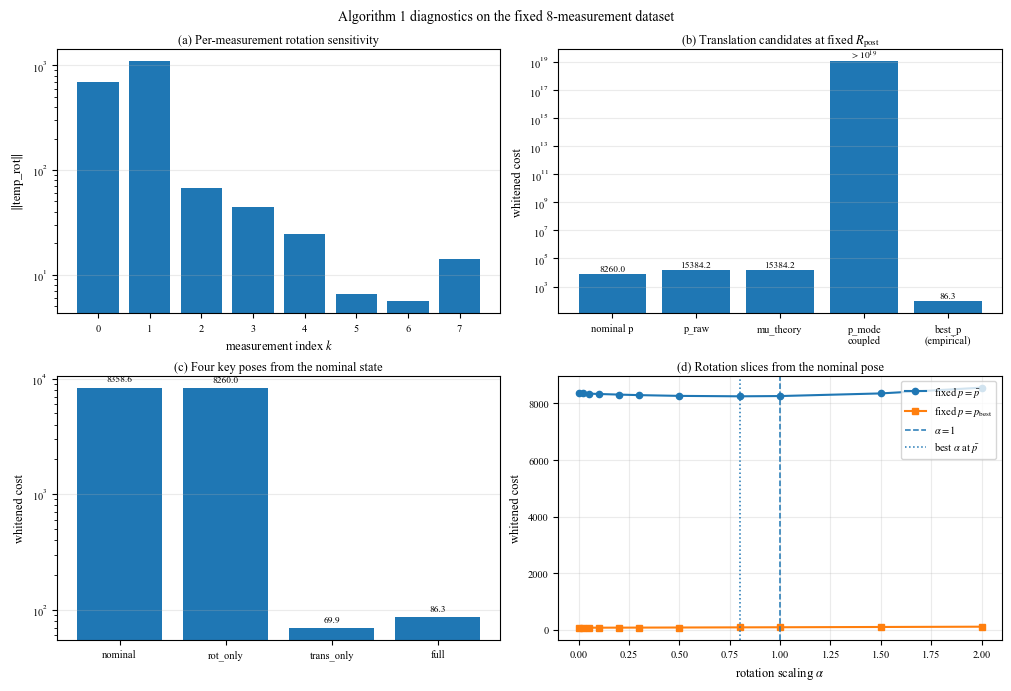

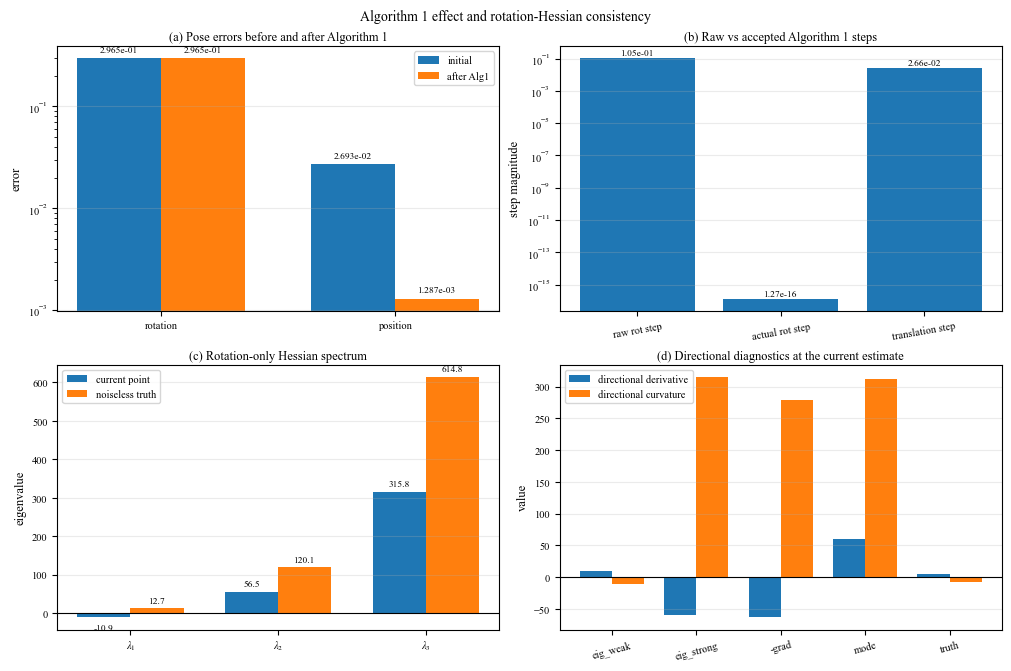

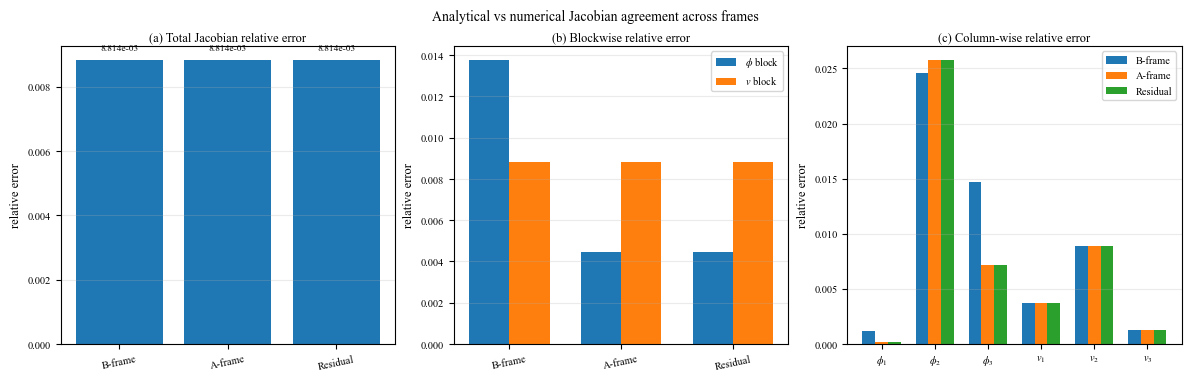

Saved PDFs:
  alg1_diagnostics_paper_final.pdf
  alg1_hessian_consistency_paper_final.pdf
  jacobian_framewise_errors_paper_final.pdf


In [48]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Final paper-style plotting setup
# =========================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 9,            # base
    "axes.titlesize": 9,       # subplot titles (smaller)
    "axes.labelsize": 9,
    "legend.fontsize": 7.5,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,
    "figure.titlesize": 10,    # figure title
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

def annotate_bars(ax, bars, fmt="{:.2f}", fontsize=6.8, yoffset=0.02):
    ymin, ymax = ax.get_ylim()
    yr = ymax - ymin
    for b in bars:
        h = b.get_height()
        ax.text(
            b.get_x() + b.get_width() / 2,
            h + yoffset * yr,
            fmt.format(h),
            ha="center",
            va="bottom",
            fontsize=fontsize,
        )

# =========================================================
# 1) Algorithm 1 diagnostics data
# =========================================================

# per-measurement temp_rot norms
k_idx = np.arange(8)
temp_rot_norms = np.array([
    6.887322e+02,
    1.093656e+03,
    6.719919e+01,
    4.393140e+01,
    2.425490e+01,
    6.561028e+00,
    5.537631e+00,
    1.420766e+01,
], dtype=float)

# translation line-search / candidate costs
trans_candidate_names = [
    "nominal p",
    "p_raw",
    "mu_theory",
    "p_mode\ncoupled",
    "best_p\n(empirical)",
]
trans_candidate_costs = np.array([
    8259.959454881995,
    15384.24924576666,
    15384.24924576666,
    1.1507769101710637e+19,
    86.27664746101729,
], dtype=float)

# four key poses
key_pose_names = ["nominal", "rot_only", "trans_only", "full"]
key_pose_costs = np.array([
    8358.562174529417,
    8259.959454881995,
    69.85909374506875,
    86.27664746101729,
], dtype=float)

# alpha scans
alpha_scan = np.array([0.00, 0.02, 0.05, 0.10, 0.20, 0.30, 0.50, 0.80, 1.00, 1.50, 2.00], dtype=float)
cost_scan_pbar = np.array([
    8358.562174529417,
    8353.28744015839,
    8345.609381979526,
    8333.442539916896,
    8311.50325875858,
    8292.818226783165,
    8265.522870662684,
    8251.007204804793,
    8259.959439181379,
    8352.900902074409,
    8556.645546951397,
], dtype=float)
cost_scan_bestp = np.array([
    69.85909374506875,
    70.13225695376929,
    70.54673745589204,
    71.25015419799556,
    72.70381380956374,
    74.21854078887944,
    77.42139148931915,
    82.60870801723075,
    86.27664749661767,
    95.95445692873338,
    106.05640355788783,
], dtype=float)

best_alpha_scan_pbar = 0.8
best_alpha_scan_bestp = 0.0

# Alg1 error and step summary
metrics_names = ["rotation", "position"]
err_init = np.array([0.29651799390266426, 0.026925824035672518], dtype=float)
err_alg1 = np.array([0.29651799390266437, 0.001286968508485774], dtype=float)

step_names = ["raw rot step", "actual rot step", "translation step"]
step_vals = np.array([
    0.10462587684696463,     # ||dphi_post_raw||
    1.2724889801921597e-16,  # ||delta_phi_alg1||
    0.026617704279226724,    # ||delta_p_alg1||
], dtype=float)

# =========================================================
# 2) Hessian / consistency data
# =========================================================

# current estimated-point rotation Hessian diagnostics
eig_current = np.array([-10.8750203, 56.48616244, 315.78348568], dtype=float)
dir_labels = ["eig_weak", "eig_strong", "-grad", "mode", "truth"]
dir_deriv_current = np.array([10.51470, -58.96298, -63.42911, 60.77157, 5.172766], dtype=float)
dir_curv_current = np.array([-10.44938, 315.7727, 279.7659, 311.6670, -7.902536], dtype=float)

# noiseless-truth stationarity diagnostics
eig_truth = np.array([12.70703041, 120.09688875, 614.81895334], dtype=float)
white_truth = 0.0
res_truth = 0.0
mode_rot_gap_truth = 3.703621e-17
mode_pos_gap_truth = 4.116712e-07

consistency_names = [
    "residual@truth",
    "white@truth",
    "mode-rot gap",
    "mode-pos gap",
]
consistency_vals = np.array([
    res_truth,
    white_truth,
    mode_rot_gap_truth,
    mode_pos_gap_truth,
], dtype=float)

# =========================================================
# 3) Jacobian framewise data
# =========================================================

frames = ["B-frame", "A-frame", "Residual"]

# total relative errors
jac_total_rel = np.array([
    0.00881423585129804,
    0.008814235119546238,
    0.008814235119546238,
], dtype=float)

# block-wise relative errors
jac_phi_rel = np.array([
    0.013749307434499182,
    0.0044774879755176715,
    0.0044774879755176715,
], dtype=float)

jac_v_rel = np.array([
    0.008814235575433645,
    0.008814236466123447,
    0.008814236466123447,
], dtype=float)

# column-wise relative errors
col_labels = [r"$\phi_1$", r"$\phi_2$", r"$\phi_3$", r"$v_1$", r"$v_2$", r"$v_3$"]

jac_cols_B = np.array([
    1.161704e-03,
    2.454708e-02,
    1.467823e-02,
    3.698537e-03,
    8.865103e-03,
    1.263018e-03,
], dtype=float)

jac_cols_A = np.array([
    1.780472e-04,
    2.573498e-02,
    7.116931e-03,
    3.698648e-03,
    8.865097e-03,
    1.263100e-03,
], dtype=float)

jac_cols_R = np.array([
    1.780472e-04,
    2.573498e-02,
    7.116931e-03,
    3.698648e-03,
    8.865097e-03,
    1.263100e-03,
], dtype=float)

# =========================================================
# Figure 1: Algorithm 1 diagnostics
# =========================================================
fig1, axes = plt.subplots(2, 2, figsize=(10.0, 6.8), constrained_layout=True)

# (a) temp_rot norms
ax = axes[0, 0]
bars = ax.bar(k_idx, temp_rot_norms)
ax.set_yscale("log")
ax.set_xlabel("measurement index $k$")
ax.set_ylabel(r"$\|\mathrm{temp\_rot}\|$")
ax.set_title("(a) Per-measurement rotation sensitivity", fontsize=9, pad=4)
ax.grid(True, axis="y", alpha=0.25, linewidth=0.8)
ax.set_xticks(k_idx)
ax.set_xticklabels([str(i) for i in k_idx])

# (b) translation candidate costs
ax = axes[0, 1]
x = np.arange(len(trans_candidate_names))
bars = ax.bar(x, trans_candidate_costs)
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(trans_candidate_names)
ax.set_ylabel("whitened cost")
ax.set_title(r"(b) Translation candidates at fixed $R_{\mathrm{post}}$", fontsize=9, pad=4)
ax.grid(True, axis="y", alpha=0.25, linewidth=0.8)
for i, val in enumerate(trans_candidate_costs):
    if val < 1e8:
        ax.text(i, val * 1.12, f"{val:.1f}", ha="center", va="bottom", fontsize=6.8)
    else:
        ax.text(i, val * 1.12, r"$>10^{19}$", ha="center", va="bottom", fontsize=6.8)

# (c) key pose costs
ax = axes[1, 0]
x = np.arange(len(key_pose_names))
bars = ax.bar(x, key_pose_costs)
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(key_pose_names)
ax.set_ylabel("whitened cost")
ax.set_title("(c) Four key poses from the nominal state", fontsize=9, pad=4)
ax.grid(True, axis="y", alpha=0.25, linewidth=0.8)
for i, val in enumerate(key_pose_costs):
    ax.text(i, val * 1.08, f"{val:.1f}", ha="center", va="bottom", fontsize=6.8)

# (d) rotation alpha scan
ax = axes[1, 1]
ax.plot(alpha_scan, cost_scan_pbar, marker="o", linewidth=1.5, markersize=4.5, label=r"fixed $p=\bar p$")
ax.plot(alpha_scan, cost_scan_bestp, marker="s", linewidth=1.5, markersize=4.5, label=r"fixed $p=p_{\mathrm{best}}$")
ax.axvline(1.0, linestyle="--", linewidth=1.1, label=r"$\alpha=1$")
ax.axvline(best_alpha_scan_pbar, linestyle=":", linewidth=1.1, label=r"best $\alpha$ at $\bar p$")
ax.set_xlabel(r"rotation scaling $\alpha$")
ax.set_ylabel("whitened cost")
ax.set_title("(d) Rotation slices from the nominal pose", fontsize=9, pad=4)
ax.grid(True, alpha=0.25, linewidth=0.8)
ax.legend(loc="upper right", frameon=True, fontsize=7.5)

fig1.suptitle("Algorithm 1 diagnostics on the fixed 8-measurement dataset", fontsize=10)
fig1.savefig("alg1_diagnostics_paper_final.pdf", bbox_inches="tight")
plt.show()

# =========================================================
# Figure 2: Alg1 effect + Hessian consistency
# =========================================================
fig2, axes = plt.subplots(2, 2, figsize=(10.0, 6.6), constrained_layout=True)

# (a) before/after errors
ax = axes[0, 0]
x = np.arange(len(metrics_names))
w = 0.36
bars1 = ax.bar(x - w/2, err_init, width=w, label="initial")
bars2 = ax.bar(x + w/2, err_alg1, width=w, label="after Alg1")
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.set_ylabel("error")
ax.set_title("(a) Pose errors before and after Algorithm 1", fontsize=9, pad=4)
ax.grid(True, axis="y", alpha=0.25, linewidth=0.8)
ax.legend(frameon=True, fontsize=7.5)
for i, val in enumerate(err_init):
    ax.text(i - w/2, val * 1.1, f"{val:.3e}", ha="center", va="bottom", fontsize=6.8)
for i, val in enumerate(err_alg1):
    ax.text(i + w/2, val * 1.1, f"{val:.3e}", ha="center", va="bottom", fontsize=6.8)

# (b) effective steps
ax = axes[0, 1]
x = np.arange(len(step_names))
bars = ax.bar(x, step_vals)
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(step_names, rotation=10)
ax.set_ylabel("step magnitude")
ax.set_title("(b) Raw vs accepted Algorithm 1 steps", fontsize=9, pad=4)
ax.grid(True, axis="y", alpha=0.25, linewidth=0.8)
for i, val in enumerate(step_vals):
    ax.text(i, val * 1.15, f"{val:.2e}", ha="center", va="bottom", fontsize=6.8)

# (c) Hessian eigenvalues
ax = axes[1, 0]
x = np.arange(3)
w = 0.36
bars1 = ax.bar(x - w/2, eig_current, width=w, label="current point")
bars2 = ax.bar(x + w/2, eig_truth, width=w, label="noiseless truth")
ax.axhline(0.0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([r"$\lambda_1$", r"$\lambda_2$", r"$\lambda_3$"])
ax.set_ylabel("eigenvalue")
ax.set_title("(c) Rotation-only Hessian spectrum", fontsize=9, pad=4)
ax.grid(True, axis="y", alpha=0.25, linewidth=0.8)
ax.legend(frameon=True, fontsize=7.5)
for i, val in enumerate(eig_current):
    ax.text(i - w/2, val + (8 if val >= 0 else -18), f"{val:.1f}", ha="center",
            va=("bottom" if val >= 0 else "top"), fontsize=6.8)
for i, val in enumerate(eig_truth):
    ax.text(i + w/2, val + 8, f"{val:.1f}", ha="center", va="bottom", fontsize=6.8)

# (d) current-point directional derivative / curvature
ax = axes[1, 1]
x = np.arange(len(dir_labels))
w = 0.38
ax.bar(x - w/2, dir_deriv_current, width=w, label="directional derivative")
ax.bar(x + w/2, dir_curv_current, width=w, label="directional curvature")
ax.axhline(0.0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(dir_labels, rotation=15)
ax.set_ylabel("value")
ax.set_title("(d) Directional diagnostics at the current estimate", fontsize=9, pad=4)
ax.grid(True, axis="y", alpha=0.25, linewidth=0.8)
ax.legend(frameon=True, fontsize=7.5)

fig2.suptitle("Algorithm 1 effect and rotation-Hessian consistency", fontsize=10)
fig2.savefig("alg1_hessian_consistency_paper_final.pdf", bbox_inches="tight")
plt.show()

# =========================================================
# Figure 3: Jacobian framewise errors
# =========================================================
fig3, axes = plt.subplots(1, 3, figsize=(11.8, 3.7), constrained_layout=True)

# (a) total relative error
ax = axes[0]
x = np.arange(len(frames))
bars = ax.bar(x, jac_total_rel)
ax.set_xticks(x)
ax.set_xticklabels(frames, rotation=12)
ax.set_ylabel("relative error")
ax.set_title("(a) Total Jacobian relative error", fontsize=9, pad=4)
ax.grid(True, axis="y", alpha=0.25, linewidth=0.8)
for i, val in enumerate(jac_total_rel):
    ax.text(i, val * 1.03, f"{val:.3e}", ha="center", va="bottom", fontsize=6.8)

# (b) blockwise relative error
ax = axes[1]
x = np.arange(len(frames))
w = 0.36
ax.bar(x - w/2, jac_phi_rel, width=w, label=r"$\phi$ block")
ax.bar(x + w/2, jac_v_rel, width=w, label=r"$v$ block")
ax.set_xticks(x)
ax.set_xticklabels(frames, rotation=12)
ax.set_ylabel("relative error")
ax.set_title("(b) Blockwise relative error", fontsize=9, pad=4)
ax.grid(True, axis="y", alpha=0.25, linewidth=0.8)
ax.legend(frameon=True, fontsize=7.5)

# (c) column-wise relative error
ax = axes[2]
x = np.arange(len(col_labels))
w = 0.24
ax.bar(x - w, jac_cols_B, width=w, label="B-frame")
ax.bar(x,     jac_cols_A, width=w, label="A-frame")
ax.bar(x + w, jac_cols_R, width=w, label="Residual")
ax.set_xticks(x)
ax.set_xticklabels(col_labels)
ax.set_ylabel("relative error")
ax.set_title("(c) Column-wise relative error", fontsize=9, pad=4)
ax.grid(True, axis="y", alpha=0.25, linewidth=0.8)
ax.legend(frameon=True, fontsize=7.5)

fig3.suptitle("Analytical vs numerical Jacobian agreement across frames", fontsize=10)
fig3.savefig("jacobian_framewise_errors_paper_final.pdf", bbox_inches="tight")
plt.show()

print("Saved PDFs:")
print("  alg1_diagnostics_paper_final.pdf")
print("  alg1_hessian_consistency_paper_final.pdf")
print("  jacobian_framewise_errors_paper_final.pdf")

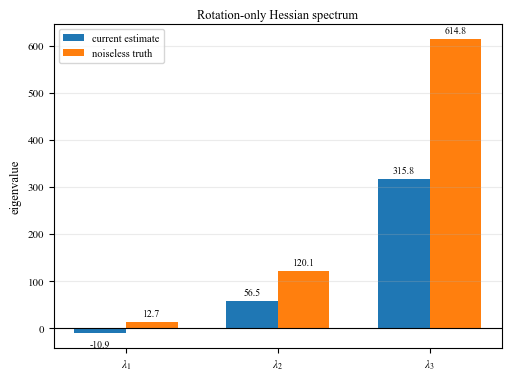

In [49]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 9,
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 7.5,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.titlesize": 10,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# data
eig_current = np.array([-10.8750203, 56.48616244, 315.78348568], dtype=float)
eig_truth = np.array([12.70703041, 120.09688875, 614.81895334], dtype=float)

fig, ax = plt.subplots(figsize=(5.0, 3.7), constrained_layout=True)

x = np.arange(3)
w = 0.34

ax.bar(x - w/2, eig_current, width=w, label="current estimate")
ax.bar(x + w/2, eig_truth, width=w, label="noiseless truth")

ax.axhline(0.0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([r"$\lambda_1$", r"$\lambda_2$", r"$\lambda_3$"])
ax.set_ylabel("eigenvalue")
ax.set_title("Rotation-only Hessian spectrum", pad=4)
ax.grid(True, axis="y", alpha=0.25, linewidth=0.8)
ax.legend(frameon=True, loc="upper left")

for i, val in enumerate(eig_current):
    ax.text(
        i - w/2,
        val + (8 if val >= 0 else -14),
        f"{val:.1f}",
        ha="center",
        va=("bottom" if val >= 0 else "top"),
        fontsize=7,
    )

for i, val in enumerate(eig_truth):
    ax.text(
        i + w/2,
        val + 8,
        f"{val:.1f}",
        ha="center",
        va="bottom",
        fontsize=7,
    )

fig.savefig("alg1_rotation_hessian_spectrum.pdf", bbox_inches="tight")
plt.show()

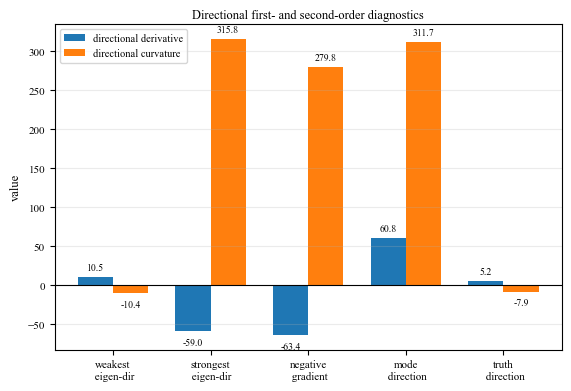

In [50]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 9,
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 7.5,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.titlesize": 10,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# data
dir_deriv_current = np.array([10.51470, -58.96298, -63.42911, 60.77157, 5.172766], dtype=float)
dir_curv_current  = np.array([-10.44938, 315.7727, 279.7659, 311.6670, -7.902536], dtype=float)

# prettier labels
dir_labels_pretty = [
    "weakest\n eigen-dir",
    "strongest\n eigen-dir",
    "negative\n gradient",
    "mode\n direction",
    "truth\n direction",
]

fig, ax = plt.subplots(figsize=(5.6, 3.8), constrained_layout=True)

x = np.arange(len(dir_labels_pretty))
w = 0.36

ax.bar(x - w/2, dir_deriv_current, width=w, label="directional derivative")
ax.bar(x + w/2, dir_curv_current, width=w, label="directional curvature")

ax.axhline(0.0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(dir_labels_pretty)
ax.set_ylabel("value")
ax.set_title("Directional first- and second-order diagnostics", pad=4)
ax.grid(True, axis="y", alpha=0.25, linewidth=0.8)
ax.legend(frameon=True, loc="upper left")

for i, val in enumerate(dir_deriv_current):
    ax.text(
        i - w/2,
        val + (6 if val >= 0 else -8),
        f"{val:.1f}",
        ha="center",
        va=("bottom" if val >= 0 else "top"),
        fontsize=7,
    )

for i, val in enumerate(dir_curv_current):
    ax.text(
        i + w/2,
        val + (6 if val >= 0 else -8),
        f"{val:.1f}",
        ha="center",
        va=("bottom" if val >= 0 else "top"),
        fontsize=7,
    )

fig.savefig("alg1_directional_diagnostics.pdf", bbox_inches="tight")
plt.show()

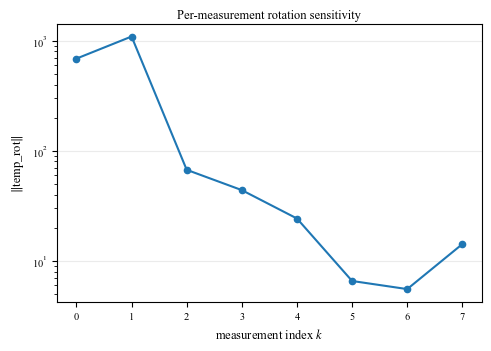

Saved: alg1_rotation_sensitivity_single.pdf


In [51]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# EXACT same paper-style setup as previous figures
# =========================================================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 9,            # base
    "axes.titlesize": 9,       # subplot titles
    "axes.labelsize": 9,
    "legend.fontsize": 7.5,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,
    "figure.titlesize": 10,    # figure title
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =========================================================
# Data: per-measurement rotation sensitivity
# =========================================================
k_idx = np.arange(8)
temp_rot_norms = np.array([
    6.887322e+02,
    1.093656e+03,
    6.719919e+01,
    4.393140e+01,
    2.425490e+01,
    6.561028e+00,
    5.537631e+00,
    1.420766e+01,
], dtype=float)

# =========================================================
# Single figure
# =========================================================
fig, ax = plt.subplots(figsize=(4.8, 3.4), constrained_layout=True)

ax.plot(
    k_idx,
    temp_rot_norms,
    marker="o",
    linewidth=1.5,
    markersize=4.5,
)

ax.set_yscale("log")
ax.set_xlabel(r"measurement index $k$")
ax.set_ylabel(r"$\|\mathrm{temp\_rot}\|$")
ax.set_title("Per-measurement rotation sensitivity", fontsize=9, pad=4)

ax.set_xticks(k_idx)
ax.set_xticklabels([str(i) for i in k_idx])
ax.grid(True, axis="y", alpha=0.25, linewidth=0.8)

fig.savefig("alg1_rotation_sensitivity_single.pdf", bbox_inches="tight")
plt.show()

print("Saved: alg1_rotation_sensitivity_single.pdf")

In [ ]:
# ===== 实验 D：固定真值旋转，只测试平移恢复 ======= 全局参数配置版 

# 1) 固定 nominal pose 的旋转为真值，平移仍从 0 开始
X_WB_bar_test = Pose(
    R=X_WB_true.R.copy(),
    p=np.zeros(3)
)

# 2) 做单轮 posterior update
theta_test = single_pass_mfg_posterior_update(
    theta_prior=theta0,
    X_WB_bar=X_WB_bar_test,
    measurements_Y=measurements_Y,
    sensor_poses_WA=sensor_poses_WA,
    Sigma_w=Sigma_w,
    contact_points_A=contact_points_A,
    field_params=field_params,
    stiffness_params=stiffness_params
)

# 3) 这里只测试平移，所以直接取 mu_post 作为平移估计
p_hat_test = theta_test.mu.copy()

# 4) 如果你想看“固定真值旋转下”的位姿估计，可以手工构造
X_test_fixedR = Pose(
    R=X_WB_true.R.copy(),
    p=p_hat_test
)

print("===== Translation-only test with true rotation =====")
print("p_true =", X_WB_true.p)
print("p_hat  =", p_hat_test)
print("position error =", np.linalg.norm(p_hat_test - X_WB_true.p))

# 可选：看一下 theta_test 里的参数量级
print("\n===== Posterior summary =====")
print("mu_post =", theta_test.mu)
print("||mu_post|| =", np.linalg.norm(theta_test.mu))
print("||F_post|| =", np.linalg.norm(theta_test.F))
print("cond(Lambda_post) =", np.linalg.cond(theta_test.Lambda))
print("||Gamma_post|| =", np.linalg.norm(theta_test.Gamma))

In [ ]:
def translation_only_update_fixed_R(
    theta_prior,
    X_WB_bar,
    measurements_Y,
    sensor_poses_WA,
    Sigma_w,
    contact_points_A,
    field_params,
    stiffness_params
):
    Lambda_post = theta_prior.Lambda.copy()
    eta = theta_prior.Lambda @ theta_prior.mu

    Sigma_w_inv = np.linalg.inv(Sigma_w)

    K = measurements_Y.shape[0]
    for k in range(K):
        X_WA_k = sensor_poses_WA[k]
        y_k = measurements_Y[k]

        # 在当前固定 R、当前 p_bar 下做模型预测
        w_pred_k = measurement_model_y(
            X_WA_k,
            X_WB_bar,
            contact_points_A,
            field_params,
            stiffness_params
        )
        r_k = y_k - w_pred_k

        # 仍然可以用 hybrid Jacobian，但这里只取平移块
        J_k = hybrid_residual_jacobian_v2(
            y_k,
            X_WA_k,
            X_WB_bar,
            contact_points_A,
            field_params,
            stiffness_params,
            h_rot=1e-5
        )
        J_k_v = J_k[:, 3:]

        Lambda_post = Lambda_post + J_k_v.T @ Sigma_w_inv @ J_k_v
        #eta = eta + J_k_v.T @ Sigma_w_inv @ (r_k + J_k_v @ X_WB_bar.p)
        eta = eta - J_k_v.T @ Sigma_w_inv @ (r_k + J_k_v @ X_WB_bar.p)

    p_post = np.linalg.solve(Lambda_post, eta)

    return p_post, Lambda_post, eta

In [ ]:
# ===== 实验 E：固定真值旋转，只对平移做多轮迭代 =====

p_bar = np.zeros(3)
alpha_p = 0.5   # 平移阻尼，可先用 0.5
num_iters = 5

for t in range(num_iters):
    X_WB_bar_test = Pose(
        R=X_WB_true.R.copy(),
        p=p_bar.copy()
    )

    p_new, Lambda_post_t, eta_t = translation_only_update_fixed_R(
        theta_prior=theta0,
        X_WB_bar=X_WB_bar_test,
        measurements_Y=measurements_Y,
        sensor_poses_WA=sensor_poses_WA,
        Sigma_w=Sigma_w,
        contact_points_A=contact_points_A,
        field_params=field_params,
        stiffness_params=stiffness_params
    )

    print(f"[iter {t}] p_bar =", p_bar)
    print(f"[iter {t}] p_new =", p_new)
    print(f"[iter {t}] position error =", np.linalg.norm(p_new - X_WB_true.p))
    print(f"[iter {t}] ||eta|| =", np.linalg.norm(eta_t))
    print(f"[iter {t}] cond(Lambda_post) =", np.linalg.cond(Lambda_post_t))
    print()

    # 加阻尼更新，避免平移一步走太猛
    p_bar = p_bar + alpha_p * (p_new - p_bar)

print("===== Final translation-only result =====")
print("p_true =", X_WB_true.p)
print("p_est  =", p_bar)
print("final position error =", np.linalg.norm(p_bar - X_WB_true.p))

##### “增量版平移更新”测试### 
#### “全局参数装配”在多轮次迭代中容易累积爆炸误差

In [ ]:
def translation_only_delta_update_fixed_R(
    X_WB_bar,
    measurements_Y,
    sensor_poses_WA,
    Sigma_w,
    contact_points_A,
    field_params,
    stiffness_params
):
    Sigma_w_inv = np.linalg.inv(Sigma_w)

    H = np.zeros((3, 3))
    b = np.zeros(3)

    K = measurements_Y.shape[0]
    for k in range(K):
        X_WA_k = sensor_poses_WA[k]
        y_k = measurements_Y[k]

        w_pred_k = measurement_model_y(
            X_WA_k,
            X_WB_bar,
            contact_points_A,
            field_params,
            stiffness_params
        )
        r_k = y_k - w_pred_k

        J_k = hybrid_residual_jacobian_v2(
            y_k,
            X_WA_k,
            X_WB_bar,
            contact_points_A,
            field_params,
            stiffness_params,
            h_rot=1e-5
        )
        J_k_v = J_k[:, 3:]

        H += J_k_v.T @ Sigma_w_inv @ J_k_v
        b -= J_k_v.T @ Sigma_w_inv @ r_k

    delta_p = np.linalg.solve(H, b)
    return delta_p, H, b

In [ ]:
# ===== 实验 G：固定真值旋转，平移做增量更新 =====
p_bar = np.zeros(3)
alpha_p = 0.5
num_iters = 5

for t in range(num_iters):
    X_WB_bar_test = Pose(
        R=X_WB_true.R.copy(),
        p=p_bar.copy()
    )

    delta_p, H_t, b_t = translation_only_delta_update_fixed_R(
        X_WB_bar=X_WB_bar_test,
        measurements_Y=measurements_Y,
        sensor_poses_WA=sensor_poses_WA,
        Sigma_w=Sigma_w,
        contact_points_A=contact_points_A,
        field_params=field_params,
        stiffness_params=stiffness_params
    )

    p_new = p_bar + alpha_p * delta_p

    print(f"[iter {t}] p_bar =", p_bar)
    print(f"[iter {t}] delta_p =", delta_p)
    print(f"[iter {t}] p_new =", p_new)
    print(f"[iter {t}] position error =", np.linalg.norm(p_new - X_WB_true.p))
    print(f"[iter {t}] ||b|| =", np.linalg.norm(b_t))
    print(f"[iter {t}] cond(H) =", np.linalg.cond(H_t))
    print()

    p_bar = p_new

print("===== Final delta-update translation result =====")
print("p_true =", X_WB_true.p)
print("p_est  =", p_bar)
print("final position error =", np.linalg.norm(p_bar - X_WB_true.p))

In [ ]:
# ===== 固定旋转下的观测代价比较 =====
# 比较 p = 0, p = p_hat, p = p_true, p = -p_true 时的代价
# 这里固定 R = R_true，只研究 translation 的代价面

def translation_cost_fixed_R(
    p_test: np.ndarray,
    R_fixed: np.ndarray,
    measurements_Y: np.ndarray,
    sensor_poses_WA,
    Sigma_w: np.ndarray,
    contact_points_A: np.ndarray,
    field_params,
    stiffness_params
) -> float:
    """
    固定旋转 R_fixed，只比较不同 p_test 下的总观测代价：
        cost(p) = sum_k (y_k - w_pred_k)^T Sigma_w^{-1} (y_k - w_pred_k)
    """
    p_test = np.asarray(p_test, dtype=float).reshape(3,)
    Sigma_w_inv = np.linalg.inv(Sigma_w)

    X_test = Pose(R=R_fixed.copy(), p=p_test.copy())

    total_cost = 0.0
    for k, X_WA_k in enumerate(sensor_poses_WA):
        y_k = measurements_Y[k]
        w_pred_k = measurement_model_y(
            X_WA_k,
            X_test,
            contact_points_A,
            field_params,
            stiffness_params
        )
        r_k = y_k - w_pred_k
        total_cost += float(r_k.T @ Sigma_w_inv @ r_k)

    return total_cost


# ===== 取几个待比较的 p =====
p_zero = np.zeros(3)
p_hat_main = X_star.p.copy() if 'X_star' in globals() else np.array([0.00096365, -0.00059431, 0.00136638])
p_true = X_WB_true.p.copy()
p_neg_true = -X_WB_true.p.copy()

# ===== 固定旋转为真值 =====
R_fixed = X_WB_true.R.copy()

# ===== 计算代价 =====
cost_zero = translation_cost_fixed_R(
    p_zero, R_fixed, measurements_Y, sensor_poses_WA, Sigma_w,
    contact_points_A, field_params, stiffness_params
)

cost_hat = translation_cost_fixed_R(
    p_hat_main, R_fixed, measurements_Y, sensor_poses_WA, Sigma_w,
    contact_points_A, field_params, stiffness_params
)

cost_true = translation_cost_fixed_R(
    p_true, R_fixed, measurements_Y, sensor_poses_WA, Sigma_w,
    contact_points_A, field_params, stiffness_params
)

cost_neg_true = translation_cost_fixed_R(
    p_neg_true, R_fixed, measurements_Y, sensor_poses_WA, Sigma_w,
    contact_points_A, field_params, stiffness_params
)

print("===== Translation cost comparison with fixed R = R_true =====")
print("p = 0      :", p_zero,     " cost =", cost_zero)
print("p = p_hat  :", p_hat_main, " cost =", cost_hat)
print("p = p_true :", p_true,     " cost =", cost_true)
print("p = -p_true:", p_neg_true, " cost =", cost_neg_true)

# ===== 再做一个相对比值，方便判断 =====
min_cost = min(cost_zero, cost_hat, cost_true, cost_neg_true)
print("\n===== Relative to best cost =====")
print("cost(0)       / best =", cost_zero / min_cost)
print("cost(p_hat)   / best =", cost_hat / min_cost)
print("cost(p_true)  / best =", cost_true / min_cost)
print("cost(-p_true) / best =", cost_neg_true / min_cost)

In [ ]:
# ===== Translation cost profile test =====
# 目的：
# 1) 固定 R = R_true
# 2) 比较沿不同平移方向 p(t) 的观测代价
#    - 方向 A: 真值方向 p_true
#    - 方向 B: 当前主实验得到的 p_hat
#
# 如果沿 p_true 方向增大 t 能显著降代价，
# 而当前 p_hat 方向也能降但幅度较小，
# 就说明当前主要问题是“步长太小”，不是方向错了。

import numpy as np
import matplotlib.pyplot as plt

def translation_cost_fixed_R(
    p_test: np.ndarray,
    R_fixed: np.ndarray,
    measurements_Y: np.ndarray,
    sensor_poses_WA,
    Sigma_w: np.ndarray,
    contact_points_A: np.ndarray,
    field_params,
    stiffness_params
) -> float:
    """
    固定旋转 R_fixed，只比较不同 p_test 下的总观测代价：
        cost(p) = sum_k (y_k - w_pred_k)^T Sigma_w^{-1} (y_k - w_pred_k)
    """
    p_test = np.asarray(p_test, dtype=float).reshape(3,)
    Sigma_w_inv = np.linalg.inv(Sigma_w)

    X_test = Pose(R=R_fixed.copy(), p=p_test.copy())

    total_cost = 0.0
    for k, X_WA_k in enumerate(sensor_poses_WA):
        y_k = measurements_Y[k]
        w_pred_k = measurement_model_y(
            X_WA_k,
            X_test,
            contact_points_A,
            field_params,
            stiffness_params
        )
        r_k = y_k - w_pred_k
        total_cost += float(r_k.T @ Sigma_w_inv @ r_k)

    return total_cost


# ===== 固定旋转 =====
R_fixed = X_WB_true.R.copy()

# ===== 两条测试方向 =====
dir_true = X_WB_true.p.copy()       # 真值方向
#dir_hat = X_star.p.copy()           # 当前主实验得到的方向（主实验保存在 X_star 里）
#dir_hat = p_hat_stable.p.copy() 
dir_hat = np.array([0.00096365, -0.00059431, 0.00136638])
# 防止某个方向太小或恰好为 0
norm_true = np.linalg.norm(dir_true)
norm_hat = np.linalg.norm(dir_hat)

print("||p_true|| =", norm_true)
print("||p_hat||  =", norm_hat)

# 取 t 的范围
t_grid = np.linspace(-0.5, 2.0, 101)

cost_true_line = []
cost_hat_line = []

for t in t_grid:
    p_test_true = t * dir_true
    p_test_hat = t * dir_hat

    c_true = translation_cost_fixed_R(
        p_test_true, R_fixed, measurements_Y, sensor_poses_WA, Sigma_w,
        contact_points_A, field_params, stiffness_params
    )
    c_hat = translation_cost_fixed_R(
        p_test_hat, R_fixed, measurements_Y, sensor_poses_WA, Sigma_w,
        contact_points_A, field_params, stiffness_params
    )

    cost_true_line.append(c_true)
    cost_hat_line.append(c_hat)

cost_true_line = np.array(cost_true_line)
cost_hat_line = np.array(cost_hat_line)

# 找各自最小点
idx_true_min = np.argmin(cost_true_line)
idx_hat_min = np.argmin(cost_hat_line)

print("\n===== Cost profile summary =====")
print("Along p_true direction:")
print("  best t =", t_grid[idx_true_min])
print("  best cost =", cost_true_line[idx_true_min])

print("Along p_hat direction:")
print("  best t =", t_grid[idx_hat_min])
print("  best cost =", cost_hat_line[idx_hat_min])

# 一些关键点的代价
def print_key_costs(direction_name, direction_vec):
    for t in [0.0, 0.5, 1.0, 1.5]:
        c = translation_cost_fixed_R(
            t * direction_vec, R_fixed, measurements_Y, sensor_poses_WA, Sigma_w,
            contact_points_A, field_params, stiffness_params
        )
        print(f"{direction_name}: t={t:.1f}, cost={c}")

print("\n===== Key sampled costs =====")
print_key_costs("p_true line", dir_true)
print_key_costs("p_hat  line", dir_hat)

# ===== 作图 =====
plt.figure(figsize=(7, 4))
plt.plot(t_grid, cost_true_line, label="cost(t * p_true)")
plt.plot(t_grid, cost_hat_line, label="cost(t * p_hat)")
plt.axvline(0.0, linestyle="--")
plt.axvline(1.0, linestyle=":")
plt.xlabel("t")
plt.ylabel("cost")
plt.title("Translation cost profile with fixed R = R_true")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ===== Fair direction comparison: normalize directions first =====

u_true = X_WB_true.p / np.linalg.norm(X_WB_true.p)
u_hat  = p_hat_main / np.linalg.norm(p_hat_main)

s_grid = np.linspace(0.0, 0.04, 101)

cost_true_dir = []
cost_hat_dir = []

for s in s_grid:
    c_true = translation_cost_fixed_R(
        s * u_true, X_WB_true.R, measurements_Y, sensor_poses_WA, Sigma_w,
        contact_points_A, field_params, stiffness_params
    )
    c_hat = translation_cost_fixed_R(
        s * u_hat, X_WB_true.R, measurements_Y, sensor_poses_WA, Sigma_w,
        contact_points_A, field_params, stiffness_params
    )
    cost_true_dir.append(c_true)
    cost_hat_dir.append(c_hat)

cost_true_dir = np.array(cost_true_dir)
cost_hat_dir = np.array(cost_hat_dir)

idx_true = np.argmin(cost_true_dir)
idx_hat  = np.argmin(cost_hat_dir)

print("===== Normalized direction comparison =====")
print("true direction best s =", s_grid[idx_true], "best cost =", cost_true_dir[idx_true])
print("hat  direction best s =", s_grid[idx_hat],  "best cost =", cost_hat_dir[idx_hat])

plt.figure(figsize=(7,4))
plt.plot(s_grid, cost_true_dir, label="cost(s * u_true)")
plt.plot(s_grid, cost_hat_dir, label="cost(s * u_hat)")
plt.xlabel("s")
plt.ylabel("cost")
plt.title("Translation cost along normalized directions")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
X_star.R.copy()

In [ ]:
X_star.p.copy()

In [ ]:
X_star_stable

In [ ]:
theta_star_stable

#####测试平移步长
#### 不能再说“平移方向错了”，稳定版主实验给出的平移方向，已经和真值方向相当接近，主要问题是“步长太小”。 
#### 自适应对当前的步长做line search

仅对单轮测试用，完整的loop 不需要

In [ ]:
# ===== Translation step-size search around current p direction =====
# 固定 R = 当前主实验得到的 R_hat，测试平移步长

def full_cost(X_test, measurements_Y, sensor_poses_WA, Sigma_w,
              contact_points_A, field_params, stiffness_params):
    Sigma_w_inv = np.linalg.inv(Sigma_w)
    total = 0.0
    for k, X_WA_k in enumerate(sensor_poses_WA):
        y_k = measurements_Y[k]
        w_pred_k = measurement_model_y(
            X_WA_k, X_test,
            contact_points_A, field_params, stiffness_params
        )
        r_k = y_k - w_pred_k
        total += float(r_k.T @ Sigma_w_inv @ r_k)
    return total

# 当前稳定单轮主实验的结果
R_hat_current = X_star.R.copy()
p_hat_current = X_star.p.copy()

# 更保险，也可以手工写定：
# p_hat_current = np.array([0.00096365, -0.00059431, 0.00136638])

alphas = [1, 2, 5, 10, 15, 20]

print("===== Translation step-size search =====")
best_alpha = None
best_cost = np.inf
best_p = None

for a in alphas:
    p_test = a * p_hat_current
    X_test = Pose(R=R_hat_current.copy(), p=p_test.copy())
    c = full_cost(
        X_test, measurements_Y, sensor_poses_WA, Sigma_w,
        contact_points_A, field_params, stiffness_params
    )
    print(f"alpha = {a:>2}, p_test = {p_test}, cost = {c}")
    if c < best_cost:
        best_cost = c
        best_alpha = a
        best_p = p_test.copy()

print("\n===== Best translation scaling =====")
print("best alpha =", best_alpha)
print("best p     =", best_p)
print("best cost  =", best_cost)
print("position error =", np.linalg.norm(best_p - X_WB_true.p))

In [ ]:
# =========================
# real data in experiment 
# =========================

"""
replace：

1. contact_points_A
   - This is the contact point cloud installed under sensor/end-effector frame {A}.
   - shape: (N,3)

2. sensor_poses_WA
   - This is the known sensor pose X_WA,k at each time step k
   - Format: List[Pose]
   - Length: K

3. measurements_Y
   - The 6-dimensional wrench observations y_k at each time step
   - shape: (K,6)

4. Sigma_w
   - The observation noise covariance matrix
   - shape: (6,6)

5. field_params
   - The geometric parameters of the superquadric:
       a1, a2, a3, eps1, eps2

6. stiffness_params
   - The stiffness function parameters:
       k_min, k_max, d0

7. theta0, X_WB0
   - The initial prior parameters and the initial nominal pose

Sigma_w = np.diag([...])

field_params = SuperquadricFieldParameters(
    a1=..., a2=..., a3=..., eps1=..., eps2=..., sdf_eps=1e-8
)

stiffness_params = StiffnessParameters(
    k_min=..., k_max=..., d0=...
)

theta0 = MFGParameters(
    F=np.eye(3),
    mu=np.zeros(3),
    Lambda=100*np.eye(3),
    Gamma=np.zeros((3,3))
)

X_WB0 = Pose(R=np.eye(3), p=np.zeros(3))

theta_star, X_star = multi_pass_mfg_batch_refinement(
    theta0=theta0,
    X_WB0=X_WB0,
    measurements_Y=measurements_Y,
    sensor_poses_WA=sensor_poses_WA,
    Sigma_w=Sigma_w,
    contact_points_A=contact_points_A,
    field_params=field_params,
    stiffness_params=stiffness_params,
    Tmax=20,
    eps_R=1e-8,
    eps_p=1e-8,
    verbose=True
)
"""
print("The real data replacement has been loaded.")

# =========================================
# Appdendix G (1) Measurement Count Scaling Experiment
# =========================================
### baseline quantity-scaling experiment 
### The randomized sampling method retains the same geometric range; it simply changes the original rule-based sampling to random sampling within the same range.

### Does increasing the amount of data help with "reliable estimation"?
### Ablation (1)

In [1]:
# =========================================
# Measurement Count Scaling Experiment
# =========================================
import numpy as np

def generate_sensor_poses_rule_based_countexp(num_meas_countexp: int):
    sensor_poses_WA_countexp = []
    for k in range(num_meas_countexp):
        angle = np.deg2rad(-10 + 3 * k)
        R_A = make_rotation_z(angle)
        p_A = np.array([
            -0.010 + 0.003 * k,
             0.005 * np.sin(0.5 * k),
             0.000 + 0.002 * k
        ])
        sensor_poses_WA_countexp.append(Pose(R=R_A, p=p_A))
    return sensor_poses_WA_countexp


def generate_sensor_poses_random_countexp(num_meas_countexp: int, rng_countexp=None):
    if rng_countexp is None:
        rng_countexp = np.random.default_rng()

    sensor_poses_WA_countexp = []
    for _ in range(num_meas_countexp):
        angle_deg = rng_countexp.uniform(-10.0, 11.0)
        angle = np.deg2rad(angle_deg)
        R_A = make_rotation_z(angle)

        p_A = np.array([
            rng_countexp.uniform(-0.010, 0.020),
            rng_countexp.uniform(-0.005, 0.005),
            rng_countexp.uniform(0.000, 0.016),
        ])
        sensor_poses_WA_countexp.append(Pose(R=R_A, p=p_A))

    return sensor_poses_WA_countexp

In [2]:
def generate_measurements_countexp(
    sensor_poses_WA_countexp,
    X_WB_true_countexp: Pose,
    Sigma_w_countexp: np.ndarray,
    contact_points_A_countexp: np.ndarray,
    field_params_countexp,
    stiffness_params_countexp,
    rng_countexp=None,
):
    if rng_countexp is None:
        rng_countexp = np.random.default_rng()

    measurements_Y_countexp = []

    for X_WA_k in sensor_poses_WA_countexp:
        y_clean_countexp = measurement_model_y(
            X_WA_k,
            X_WB_true_countexp,
            contact_points_A_countexp,
            field_params_countexp,
            stiffness_params_countexp
        )

        noise_countexp = rng_countexp.multivariate_normal(
            mean=np.zeros(6),
            cov=Sigma_w_countexp
        )

        y_noisy_countexp = y_clean_countexp + noise_countexp
        measurements_Y_countexp.append(y_noisy_countexp)

    return np.asarray(measurements_Y_countexp, dtype=float)

NameError: name 'Pose' is not defined

In [ ]:
def run_one_count_scaling_trial_countexp(
    num_meas_countexp: int,
    pose_mode_countexp: str = "rule",
    seed_countexp: int = 0,
):
    rng_countexp = np.random.default_rng(seed_countexp)

    if pose_mode_countexp == "rule":
        sensor_poses_WA_countexp = generate_sensor_poses_rule_based_countexp(num_meas_countexp)
    elif pose_mode_countexp == "random":
        sensor_poses_WA_countexp = generate_sensor_poses_random_countexp(
            num_meas_countexp,
            rng_countexp=rng_countexp
        )
    else:
        raise ValueError("pose_mode_countexp must be 'rule' or 'random'")

    measurements_Y_countexp = generate_measurements_countexp(
        sensor_poses_WA_countexp=sensor_poses_WA_countexp,
        X_WB_true_countexp=X_WB_true,
        Sigma_w_countexp=Sigma_w,
        contact_points_A_countexp=contact_points_A,
        field_params_countexp=field_params,
        stiffness_params_countexp=stiffness_params,
        rng_countexp=rng_countexp,
    )

    theta_hat_countexp, X_hat_countexp, history_countexp = multi_pass_mfg_batch_refinement(
        theta0,
        X_WB0,
        measurements_Y_countexp,
        sensor_poses_WA_countexp,
        Sigma_w,
        contact_points_A,
        field_params,
        stiffness_params,
        Tmax=10,
        h_rot=1e-6,
        use_line_search=True,
        rot_gain=1.0,
        pos_gain=1.0,
        outer_alpha_candidates=[1.0, 0.5, 0.25, 0.1, 0.05, 0.02],
        use_numeric_rot_candidate=False,
        verbose=False,
        verbose_inner=False,
        return_history=True,
        X_WB_true=X_WB_true,
    )

    rot_err_countexp = np.linalg.norm(log_so3(X_WB_true.R.T @ X_hat_countexp.R))
    pos_err_countexp = np.linalg.norm(X_WB_true.p - X_hat_countexp.p)
    best_white_countexp = float(np.min(history_countexp["best_res_norm_white"]))
    final_white_countexp = float(history_countexp["res_norm_white"][-1])
    best_iter_countexp = int(np.argmin(history_countexp["best_res_norm_white"])) if len(history_countexp["best_res_norm_white"]) > 0 else -1

    result_countexp = {
        "num_meas_countexp": num_meas_countexp,
        "pose_mode_countexp": pose_mode_countexp,
        "seed_countexp": seed_countexp,
        "rot_err_countexp": rot_err_countexp,
        "pos_err_countexp": pos_err_countexp,
        "best_white_countexp": best_white_countexp,
        "final_white_countexp": final_white_countexp,
        "best_iter_countexp": best_iter_countexp,
    }

    return result_countexp

In [ ]:
def run_count_scaling_experiment_countexp(
    num_meas_list_countexp,
    num_trials_countexp: int = 10,
    pose_mode_countexp: str = "rule",
):
    records_countexp = []

    for n_countexp in num_meas_list_countexp:
        for trial_idx_countexp in range(num_trials_countexp):
            seed_countexp = 10000 + 100 * n_countexp + trial_idx_countexp

            one_result_countexp = run_one_count_scaling_trial_countexp(
                num_meas_countexp=n_countexp,
                pose_mode_countexp=pose_mode_countexp,
                seed_countexp=seed_countexp,
            )
            records_countexp.append(one_result_countexp)

    return records_countexp

In [ ]:
def summarize_count_scaling_records_countexp(records_countexp):
    """
    输入: records_countexp = list[dict]
    输出: summary_countexp = dict[num_meas] -> stats dict
    """
    summary_countexp = {}

    num_meas_values_countexp = sorted(set(r["num_meas_countexp"] for r in records_countexp))

    for n_countexp in num_meas_values_countexp:
        sub_countexp = [r for r in records_countexp if r["num_meas_countexp"] == n_countexp]

        rot_vals_countexp = np.array([r["rot_err_countexp"] for r in sub_countexp], dtype=float)
        pos_vals_countexp = np.array([r["pos_err_countexp"] for r in sub_countexp], dtype=float)
        best_white_vals_countexp = np.array([r["best_white_countexp"] for r in sub_countexp], dtype=float)
        final_white_vals_countexp = np.array([r["final_white_countexp"] for r in sub_countexp], dtype=float)
        best_iter_vals_countexp = np.array([r["best_iter_countexp"] for r in sub_countexp], dtype=float)

        summary_countexp[n_countexp] = {
            "rot_err_mean_countexp": float(np.mean(rot_vals_countexp)),
            "rot_err_std_countexp": float(np.std(rot_vals_countexp)),
            "pos_err_mean_countexp": float(np.mean(pos_vals_countexp)),
            "pos_err_std_countexp": float(np.std(pos_vals_countexp)),
            "best_white_mean_countexp": float(np.mean(best_white_vals_countexp)),
            "best_white_std_countexp": float(np.std(best_white_vals_countexp)),
            "final_white_mean_countexp": float(np.mean(final_white_vals_countexp)),
            "final_white_std_countexp": float(np.std(final_white_vals_countexp)),
            "best_iter_mean_countexp": float(np.mean(best_iter_vals_countexp)),
        }

    return summary_countexp


def print_count_scaling_summary_countexp(summary_countexp, title_countexp="Summary"):
    print(f"\n===== {title_countexp} =====")
    for n_countexp in sorted(summary_countexp.keys()):
        s_countexp = summary_countexp[n_countexp]
        print(
            f"num_meas = {n_countexp:>3d} | "
            f"rot_err = {s_countexp['rot_err_mean_countexp']:.6f} ± {s_countexp['rot_err_std_countexp']:.6f} | "
            f"pos_err = {s_countexp['pos_err_mean_countexp']:.6f} ± {s_countexp['pos_err_std_countexp']:.6f} | "
            f"best_white = {s_countexp['best_white_mean_countexp']:.6f} ± {s_countexp['best_white_std_countexp']:.6f} | "
            f"best_iter_mean = {s_countexp['best_iter_mean_countexp']:.3f}"
        )

In [ ]:
num_meas_list_countexp = [8, 16, 24, 32, 40]

records_rule_countexp = run_count_scaling_experiment_countexp(
    num_meas_list_countexp=num_meas_list_countexp,
    num_trials_countexp=3,
    pose_mode_countexp="rule",
)

records_random_countexp = run_count_scaling_experiment_countexp(
    num_meas_list_countexp=num_meas_list_countexp,
    num_trials_countexp=3,
    pose_mode_countexp="random",
)


print("number of rule-based records =", len(records_rule_countexp))
print("number of random records     =", len(records_random_countexp))

||eta|| = 11926792.739599923
||solve(Lambda_post, eta)|| = 0.0017222541298205854
||Gamma_post @ nu_Rbar|| = 0.0
p_raw = [ 0.0009574  -0.00059275  0.00130315]
||p_raw|| = 0.0017222541298205854
alpha_candidates = [1, 2, 4, 6, 8, 10, 12, 15, 18, 20]
best_alpha = 15
best_p = [ 0.01436099 -0.00889122  0.01954723]
||best_p - X_WB_bar.p|| = 0.025833811947308785
||eta|| = 11926792.739599923
||solve(Lambda_post, eta)|| = 0.0017222541298205854
||Gamma_post @ nu_Rbar|| = 0.0
p_raw = [ 0.0009574  -0.00059275  0.00130315]
||p_raw|| = 0.0017222541298205854
alpha_candidates = [1, 2, 4, 6, 8, 10, 12, 15, 18, 20]
best_alpha = 15
best_p = [ 0.01436099 -0.00889122  0.01954723]
||best_p - X_WB_bar.p|| = 0.025833811947308785
||eta|| = 60407.3419538368
||solve(Lambda_post, eta)|| = 0.024460306538816482
||Gamma_post @ nu_Rbar|| = 2.8185582629801716e-11
p_raw = [ 0.01195713 -0.00821235  0.01969495]
||p_raw|| = 0.024460306538816482
alpha_candidates = [1, 2, 4, 6, 8, 10, 12, 15, 18, 20]
best_alpha = 1
best_p = 

KeyboardInterrupt: 

In [ ]:
summary_rule_countexp = summarize_count_scaling_records_countexp(records_rule_countexp)
summary_random_countexp = summarize_count_scaling_records_countexp(records_random_countexp)

print_count_scaling_summary_countexp(summary_rule_countexp, title_countexp="Rule-based count scaling")
print_count_scaling_summary_countexp(summary_random_countexp, title_countexp="Random count scaling")


===== Rule-based count scaling =====
num_meas =   8 | rot_err = 0.294286 ± 0.009489 | pos_err = 0.002775 ± 0.003149 | best_white = 8.402471 ± 0.970415 | best_iter_mean = 2.000
num_meas =  16 | rot_err = 0.315032 ± 0.008077 | pos_err = 0.006382 ± 0.001167 | best_white = 20.491600 ± 1.641777 | best_iter_mean = 0.900
num_meas =  24 | rot_err = 0.313688 ± 0.010983 | pos_err = 0.007245 ± 0.002675 | best_white = 21.499065 ± 2.516637 | best_iter_mean = 1.300
num_meas =  32 | rot_err = 0.316808 ± 0.009829 | pos_err = 0.005215 ± 0.001653 | best_white = 21.803069 ± 1.909775 | best_iter_mean = 1.800
num_meas =  40 | rot_err = 0.315862 ± 0.004849 | pos_err = 0.006117 ± 0.001228 | best_white = 24.649248 ± 1.282383 | best_iter_mean = 0.800

===== Random count scaling =====
num_meas =   8 | rot_err = 0.301578 ± 0.017306 | pos_err = 0.410495 ± 0.611360 | best_white = 9.364530 ± 2.447562 | best_iter_mean = 2.200
num_meas =  16 | rot_err = 0.310739 ± 0.027114 | pos_err = 0.865191 ± 0.896845 | best_whit

In [ ]:
print("===== First 5 rule-based records =====")
for row_countexp in records_rule_countexp[:5]:
    print(row_countexp)

print("\n===== First 5 random records =====")
for row_countexp in records_random_countexp[:5]:
    print(row_countexp)

===== First 5 rule-based records =====
{'num_meas_countexp': 8, 'pose_mode_countexp': 'rule', 'seed_countexp': 10800, 'rot_err_countexp': np.float64(0.2904945421408616), 'pos_err_countexp': np.float64(0.0013574754903064742), 'best_white_countexp': 7.573795578373462, 'final_white_countexp': 7.573795578373462, 'best_iter_countexp': 2}
{'num_meas_countexp': 8, 'pose_mode_countexp': 'rule', 'seed_countexp': 10801, 'rot_err_countexp': np.float64(0.30109274149401305), 'pos_err_countexp': np.float64(0.011949643920565401), 'best_white_countexp': 7.257563872150298, 'final_white_countexp': 7.257563872150298, 'best_iter_countexp': 5}
{'num_meas_countexp': 8, 'pose_mode_countexp': 'rule', 'seed_countexp': 10802, 'rot_err_countexp': np.float64(0.29651799390266426), 'pos_err_countexp': np.float64(0.0031040622392522776), 'best_white_countexp': 8.115460444318964, 'final_white_countexp': 8.115460444318964, 'best_iter_countexp': 0}
{'num_meas_countexp': 8, 'pose_mode_countexp': 'rule', 'seed_countexp': 

# different sensing range

In [62]:
# =========================================================
# Cell 1: Geometry / utilities
# =========================================================

import numpy as np

def hat3(w: np.ndarray) -> np.ndarray:
    w = np.asarray(w, dtype=float).reshape(3)
    return np.array([
        [0.0,   -w[2],  w[1]],
        [w[2],   0.0,  -w[0]],
        [-w[1],  w[0],  0.0]
    ], dtype=float)

def exp_so3_local(phi: np.ndarray) -> np.ndarray:
    phi = np.asarray(phi, dtype=float).reshape(3)
    theta = np.linalg.norm(phi)
    if theta < 1e-12:
        return np.eye(3) + hat3(phi)
    K = hat3(phi / theta)
    return np.eye(3) + np.sin(theta) * K + (1.0 - np.cos(theta)) * (K @ K)

def make_rotation_z(theta: float) -> np.ndarray:
    c = np.cos(theta)
    s = np.sin(theta)
    return np.array([
        [c, -s, 0.0],
        [s,  c, 0.0],
        [0.0, 0.0, 1.0]
    ], dtype=float)

def make_rotation_y(theta: float) -> np.ndarray:
    c = np.cos(theta)
    s = np.sin(theta)
    return np.array([
        [ c, 0.0, s],
        [0.0, 1.0, 0.0],
        [-s, 0.0, c]
    ], dtype=float)

def rotation_geodesic_error_rad(R_est: np.ndarray, R_true: np.ndarray) -> float:
    return float(np.linalg.norm(log_so3(R_true.T @ R_est)))

def position_error_norm(p_est: np.ndarray, p_true: np.ndarray) -> float:
    return float(np.linalg.norm(np.asarray(p_est) - np.asarray(p_true)))

def sample_gaussian_noise(cov: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    cov = np.asarray(cov, dtype=float)
    return rng.multivariate_normal(mean=np.zeros(6), cov=cov)

In [72]:
# =========================================================
# Cell 2: Baseline trajectory + range scaling
# =========================================================

def generate_sensor_poses_rule_base(num_meas: int):
    """
    Original rule-based baseline from your current demo code.
    """
    angles_deg = []
    positions = []

    for k in range(num_meas):
        angle_deg = -10.0 + 3.0 * k
        p_A = np.array([
            -0.010 + 0.003 * k,
             0.005 * np.sin(0.5 * k),
             0.000 + 0.002 * k
        ], dtype=float)

        angles_deg.append(angle_deg)
        positions.append(p_A)

    return np.asarray(angles_deg, dtype=float), np.asarray(positions, dtype=float)


def generate_sensor_poses_rule_scaled(
    num_meas: int,
    range_scale: float = 1.0,
    add_pitch: bool = False,
    pitch_halfspan_deg: float = 0.0,
):
    """
    Expand / contract the original rule-based sensing trajectory
    around its geometric center.

    range_scale = 1.0 : original baseline
    range_scale > 1.0 : wider sensing range
    range_scale < 1.0 : narrower sensing range
    """
    base_angles_deg, base_positions = generate_sensor_poses_rule_base(num_meas)

    angle_center_deg = np.mean(base_angles_deg)
    pos_center = np.mean(base_positions, axis=0)

    k_center = 0.5 * (num_meas - 1)
    denom = max(k_center, 1.0)

    sensor_poses = []

    for k in range(num_meas):
        angle_deg_scaled = angle_center_deg + range_scale * (base_angles_deg[k] - angle_center_deg)
        p_scaled = pos_center + range_scale * (base_positions[k] - pos_center)

        Rz = make_rotation_z(np.deg2rad(angle_deg_scaled))

        if add_pitch:
            rel = (k - k_center) / denom
            pitch_deg = pitch_halfspan_deg * rel
            Ry = make_rotation_y(np.deg2rad(pitch_deg))
            R_A = Rz @ Ry
        else:
            R_A = Rz

        sensor_poses.append(Pose(R=R_A, p=p_scaled))

    return sensor_poses


def print_rule_range_geometry(num_meas: int, range_scale: float, add_pitch: bool = False, pitch_halfspan_deg: float = 0.0):
    poses = generate_sensor_poses_rule_scaled(
        num_meas=num_meas,
        range_scale=range_scale,
        add_pitch=add_pitch,
        pitch_halfspan_deg=pitch_halfspan_deg,
    )

    positions = np.asarray([X.p for X in poses], dtype=float)
    angles_deg = np.asarray([np.rad2deg(np.arctan2(X.R[1, 0], X.R[0, 0])) for X in poses], dtype=float)

    print(f"\n===== Geometry summary: range_scale = {range_scale} =====")
    print("angle_deg min/max/span =", angles_deg.min(), angles_deg.max(), angles_deg.max() - angles_deg.min())
    print("x min/max/span         =", positions[:, 0].min(), positions[:, 0].max(), np.ptp(positions[:, 0]))
    print("y min/max/span         =", positions[:, 1].min(), positions[:, 1].max(), np.ptp(positions[:, 1]))
    print("z min/max/span         =", positions[:, 2].min(), positions[:, 2].max(), np.ptp(positions[:, 2]))

In [73]:
# =========================================================
# Cell 3: Measurement generation
# =========================================================

def generate_measurements_for_sensor_poses(
    sensor_poses_WA,
    X_WB_true,
    Sigma_w,
    contact_points_A,
    field_params,
    stiffness_params,
    rng: np.random.Generator,
    add_noise: bool = True,
):
    measurements_Y = []

    for X_WA_k in sensor_poses_WA:
        y_clean = measurement_model_y(
            X_WA_k,
            X_WB_true,
            contact_points_A,
            field_params,
            stiffness_params
        )

        if add_noise:
            noise = sample_gaussian_noise(Sigma_w, rng)
            y_k = y_clean + noise
        else:
            y_k = y_clean

        measurements_Y.append(y_k)

    return np.asarray(measurements_Y, dtype=float)

In [74]:
# =========================================================
# Cell 4: Rotation-Hessian information metric at the truth
# =========================================================

def whitened_cost_dataset(
    X_candidate,
    sensor_poses_WA,
    measurements_Y_ref,
    Sigma_w,
    contact_points_A,
    field_params,
    stiffness_params,
) -> float:
    """
    Squared whitened residual cost:
        sum_k || y_ref_k - y_model_k(X_candidate) ||^2_{Sigma_w^{-1}}
    """
    Sigma_inv = np.linalg.inv(np.asarray(Sigma_w, dtype=float))
    total = 0.0

    for X_WA_k, y_ref_k in zip(sensor_poses_WA, measurements_Y_ref):
        y_model = measurement_model_y(
            X_WA_k,
            X_candidate,
            contact_points_A,
            field_params,
            stiffness_params
        )
        r = y_ref_k - y_model
        total += float(r.T @ Sigma_inv @ r)

    return total


def compute_rotation_hessian_info_at_truth(
    X_WB_true,
    sensor_poses_WA,
    Sigma_w,
    contact_points_A,
    field_params,
    stiffness_params,
    h_rot: float = 1e-4,
):
    """
    Compute rotation-only local quadratic information at the noiseless truth.
    """
    rng_dummy = np.random.default_rng(0)

    Y_noiseless = generate_measurements_for_sensor_poses(
        sensor_poses_WA=sensor_poses_WA,
        X_WB_true=X_WB_true,
        Sigma_w=Sigma_w,
        contact_points_A=contact_points_A,
        field_params=field_params,
        stiffness_params=stiffness_params,
        rng=rng_dummy,
        add_noise=False,
    )

    def f_rot(phi):
        X_phi = Pose(
            R=X_WB_true.R @ exp_so3_local(phi),
            p=X_WB_true.p.copy()
        )
        return whitened_cost_dataset(
            X_candidate=X_phi,
            sensor_poses_WA=sensor_poses_WA,
            measurements_Y_ref=Y_noiseless,
            Sigma_w=Sigma_w,
            contact_points_A=contact_points_A,
            field_params=field_params,
            stiffness_params=stiffness_params,
        )

    f0 = f_rot(np.zeros(3))

    grad = np.zeros(3, dtype=float)
    for i in range(3):
        e = np.zeros(3, dtype=float)
        e[i] = 1.0
        grad[i] = (f_rot(h_rot * e) - f_rot(-h_rot * e)) / (2.0 * h_rot)

    H = np.zeros((3, 3), dtype=float)

    for i in range(3):
        e_i = np.zeros(3, dtype=float)
        e_i[i] = 1.0
        H[i, i] = (f_rot(h_rot * e_i) - 2.0 * f0 + f_rot(-h_rot * e_i)) / (h_rot ** 2)

    for i in range(3):
        for j in range(i + 1, 3):
            e_i = np.zeros(3, dtype=float)
            e_j = np.zeros(3, dtype=float)
            e_i[i] = 1.0
            e_j[j] = 1.0

            f_pp = f_rot(h_rot * e_i + h_rot * e_j)
            f_pm = f_rot(h_rot * e_i - h_rot * e_j)
            f_mp = f_rot(-h_rot * e_i + h_rot * e_j)
            f_mm = f_rot(-h_rot * e_i - h_rot * e_j)

            H_ij = (f_pp - f_pm - f_mp + f_mm) / (4.0 * h_rot ** 2)
            H[i, j] = H_ij
            H[j, i] = H_ij

    eigvals = np.linalg.eigvalsh(H)
    eigvals = np.sort(eigvals)

    lam_min = float(eigvals[0])
    lam_mid = float(eigvals[1])
    lam_max = float(eigvals[2])
    trace_H = float(np.trace(H))
    cond_abs = float(np.max(np.abs(eigvals)) / max(np.min(np.abs(eigvals)), 1e-15))

    return {
        "f0": float(f0),
        "grad_norm": float(np.linalg.norm(grad)),
        "H": H,
        "eigvals": eigvals,
        "lam_min": lam_min,
        "lam_mid": lam_mid,
        "lam_max": lam_max,
        "trace_H": trace_H,
        "cond_abs": cond_abs,
    }

In [80]:
# =========================================================
# Cell 5: Adapter to your current Variant-B solver
# =========================================================

VARIANT_B_CONFIG = {
    "Tmax": 10,
    "h_rot": 1e-6,
    "use_line_search": True,
    "rot_gain": 1.0,
    "pos_gain": 1.0,
    "outer_alpha_candidates": [1.0, 0.5, 0.25, 0.1, 0.05, 0.02],
    "use_numeric_rot_candidate": False,
    "verbose": False,
    "verbose_inner": False,
    "return_history": True,
}

def variantB_solver_adapter(
    sensor_poses_WA,
    measurements_Y,
    X_WB0,
    theta0,
    contact_points_A,
    field_params,
    stiffness_params,
    Sigma_w,
    X_WB_true=None,
    config=None,
):
    """
    Adapter for your current trust-region / safeguarded Variant-B Algorithm 2.
    """
    if config is None:
        config = VARIANT_B_CONFIG

    theta_star, X_star, history = multi_pass_mfg_batch_refinement(
        theta0=theta0,
        X_WB0=X_WB0,
        measurements_Y=measurements_Y,
        sensor_poses_WA=sensor_poses_WA,
        Sigma_w=Sigma_w,
        contact_points_A=contact_points_A,
        field_params=field_params,
        stiffness_params=stiffness_params,
        Tmax=config["Tmax"],
        h_rot=config["h_rot"],
        use_line_search=config["use_line_search"],
        rot_gain=config["rot_gain"],
        pos_gain=config["pos_gain"],
        outer_alpha_candidates=config["outer_alpha_candidates"],
        use_numeric_rot_candidate=config["use_numeric_rot_candidate"],
        verbose=config["verbose"],
        verbose_inner=config["verbose_inner"],
        return_history=config["return_history"],
        X_WB_true=X_WB_true,
    )

    # best iterate whitened residual: use returned X_star directly
    best_white = batch_whitened_residual_norm(
        X_star,
        measurements_Y,
        sensor_poses_WA,
        Sigma_w,
        contact_points_A,
        field_params,
        stiffness_params,
    )

    # final iterate whitened residual: use last recorded value if available
    if history is not None and len(history.get("res_norm_white", [])) > 0:
        final_white = float(history["res_norm_white"][-1])
    else:
        final_white = float(best_white)

    # infer best iteration index from history
    if history is None or len(history.get("res_norm_white", [])) == 0:
        best_iter = -1
    else:
        base_white = float(history["current_res_norm_white_before"][0])
        best_hist_white = float(np.min(history["res_norm_white"]))
        if best_hist_white >= base_white - 1e-12:
            best_iter = -1
        else:
            best_iter = int(np.argmin(history["res_norm_white"]))

    return {
        "theta_star": theta_star,
        "X_hat": X_star,                   # this is already the best iterate
        "history": history,
        "best_white": float(best_white),
        "final_white": float(final_white),
        "best_iter": int(best_iter),
    }

In [81]:

# =========================================================
# Cell 6: One-trial runner (FAST version)
# =========================================================

def run_one_range_scaling_trial(
    range_scale: float,
    seed: int,
    num_meas: int,
    X_WB_true,
    X_WB0,
    theta0,
    Sigma_w,
    contact_points_A,
    field_params,
    stiffness_params,
    sensor_poses_WA_fixed,   # <- NEW: precomputed once per range_scale
    info_fixed,              # <- NEW: precomputed once per range_scale
    add_pitch: bool = False,
    pitch_halfspan_deg: float = 0.0,
    variantB_config=None,
):
    rng = np.random.default_rng(seed)

    # noisy measurements only
    measurements_Y = generate_measurements_for_sensor_poses(
        sensor_poses_WA=sensor_poses_WA_fixed,
        X_WB_true=X_WB_true,
        Sigma_w=Sigma_w,
        contact_points_A=contact_points_A,
        field_params=field_params,
        stiffness_params=stiffness_params,
        rng=rng,
        add_noise=True,
    )

    # Variant B
    solver_out = variantB_solver_adapter(
        sensor_poses_WA=sensor_poses_WA_fixed,
        measurements_Y=measurements_Y,
        X_WB0=X_WB0,
        theta0=theta0,
        contact_points_A=contact_points_A,
        field_params=field_params,
        stiffness_params=stiffness_params,
        Sigma_w=Sigma_w,
        X_WB_true=X_WB_true,
        config=variantB_config,
    )

    X_hat = solver_out["X_hat"]
    best_white = float(solver_out["best_white"])
    final_white = float(solver_out["final_white"])
    best_iter = int(solver_out["best_iter"])

    rot_err = rotation_geodesic_error_rad(X_hat.R, X_WB_true.R)
    pos_err = position_error_norm(X_hat.p, X_WB_true.p)

    # RMS-normalized whitened residual
    white_rms_best = best_white / np.sqrt(6.0 * num_meas)
    white_rms_final = final_white / np.sqrt(6.0 * num_meas)

    return {
        "range_scale": float(range_scale),
        "seed": int(seed),
        "num_meas": int(num_meas),
        "add_pitch": bool(add_pitch),
        "pitch_halfspan_deg": float(pitch_halfspan_deg),

        "rot_err": float(rot_err),
        "pos_err": float(pos_err),

        "best_white": float(best_white),
        "final_white": float(final_white),
        "best_white_rms": float(white_rms_best),
        "final_white_rms": float(white_rms_final),
        "best_iter": int(best_iter),

        # use the precomputed info directly
        "info_f0": float(info_fixed["f0"]),
        "info_grad_norm": float(info_fixed["grad_norm"]),
        "info_lam_min": float(info_fixed["lam_min"]),
        "info_lam_mid": float(info_fixed["lam_mid"]),
        "info_lam_max": float(info_fixed["lam_max"]),
        "info_trace_H": float(info_fixed["trace_H"]),
        "info_cond_abs": float(info_fixed["cond_abs"]),
    }

In [82]:
# =========================================================
# Cell 7: Multi-scale experiment runner + summary (FAST version)
# =========================================================

def run_range_scaling_experiment(
    range_scale_list,
    num_trials: int,
    num_meas: int,
    X_WB_true,
    X_WB0,
    theta0,
    Sigma_w,
    contact_points_A,
    field_params,
    stiffness_params,
    add_pitch: bool = False,
    pitch_halfspan_deg: float = 0.0,
    seed_base: int = 30000,
    h_rot_info: float = 1e-4,
    variantB_config=None,
):
    records = []

    for scale_idx, range_scale in enumerate(range_scale_list):
        print(f"\n===== range_scale = {range_scale} =====")

        # -------------------------------------------------
        # PRECOMPUTE ONCE PER RANGE SCALE
        # -------------------------------------------------
        sensor_poses_WA_fixed = generate_sensor_poses_rule_scaled(
            num_meas=num_meas,
            range_scale=range_scale,
            add_pitch=add_pitch,
            pitch_halfspan_deg=pitch_halfspan_deg,
        )

        info_fixed = compute_rotation_hessian_info_at_truth(
            X_WB_true=X_WB_true,
            sensor_poses_WA=sensor_poses_WA_fixed,
            Sigma_w=Sigma_w,
            contact_points_A=contact_points_A,
            field_params=field_params,
            stiffness_params=stiffness_params,
            h_rot=h_rot_info,
        )

        print(
            f"[precomputed info] "
            f"lam_min={info_fixed['lam_min']:.6f}, "
            f"traceH={info_fixed['trace_H']:.6f}, "
            f"cond_abs={info_fixed['cond_abs']:.6f}"
        )

        # -------------------------------------------------
        # only noise / solver changes across trials
        # -------------------------------------------------
        for trial_idx in range(num_trials):
            seed = seed_base + 1000 * scale_idx + trial_idx

            rec = run_one_range_scaling_trial(
                range_scale=range_scale,
                seed=seed,
                num_meas=num_meas,
                X_WB_true=X_WB_true,
                X_WB0=X_WB0,
                theta0=theta0,
                Sigma_w=Sigma_w,
                contact_points_A=contact_points_A,
                field_params=field_params,
                stiffness_params=stiffness_params,
                sensor_poses_WA_fixed=sensor_poses_WA_fixed,   # <- NEW
                info_fixed=info_fixed,                         # <- NEW
                add_pitch=add_pitch,
                pitch_halfspan_deg=pitch_halfspan_deg,
                variantB_config=variantB_config,
            )
            records.append(rec)

            print(
                f"trial={trial_idx:02d} | "
                f"rot_err={rec['rot_err']:.6f} | "
                f"pos_err={rec['pos_err']:.6f} | "
                f"best_white_rms={rec['best_white_rms']:.6f}"
            )

    return records


def summarize_range_scaling_records(records):
    summary = {}

    scales = sorted(set(r["range_scale"] for r in records))
    for s in scales:
        sub = [r for r in records if r["range_scale"] == s]

        def arr(key):
            return np.array([r[key] for r in sub], dtype=float)

        summary[s] = {
            "rot_err_mean": float(np.mean(arr("rot_err"))),
            "rot_err_std": float(np.std(arr("rot_err"))),

            "pos_err_mean": float(np.mean(arr("pos_err"))),
            "pos_err_std": float(np.std(arr("pos_err"))),

            "best_white_rms_mean": float(np.mean(arr("best_white_rms"))),
            "best_white_rms_std": float(np.std(arr("best_white_rms"))),

            "final_white_rms_mean": float(np.mean(arr("final_white_rms"))),
            "final_white_rms_std": float(np.std(arr("final_white_rms"))),

            "best_iter_mean": float(np.mean(arr("best_iter"))),

            "info_grad_norm_mean": float(np.mean(arr("info_grad_norm"))),
            "info_grad_norm_std": float(np.std(arr("info_grad_norm"))),

            "info_lam_min_mean": float(np.mean(arr("info_lam_min"))),
            "info_lam_min_std": float(np.std(arr("info_lam_min"))),

            "info_trace_H_mean": float(np.mean(arr("info_trace_H"))),
            "info_trace_H_std": float(np.std(arr("info_trace_H"))),

            "info_cond_abs_mean": float(np.mean(arr("info_cond_abs"))),
            "info_cond_abs_std": float(np.std(arr("info_cond_abs"))),
        }

    return summary


def print_range_scaling_summary(summary, title="Range-scaling summary"):
    print(f"\n===== {title} =====")
    for s in sorted(summary.keys()):
        ss = summary[s]
        print(
            f"scale = {s:>4} | "
            f"rot_err = {ss['rot_err_mean']:.6f} ± {ss['rot_err_std']:.6f} | "
            f"pos_err = {ss['pos_err_mean']:.6f} ± {ss['pos_err_std']:.6f} | "
            f"best_white_rms = {ss['best_white_rms_mean']:.6f} ± {ss['best_white_rms_std']:.6f} | "
            f"lam_min = {ss['info_lam_min_mean']:.6f} ± {ss['info_lam_min_std']:.6f} | "
            f"traceH = {ss['info_trace_H_mean']:.6f} ± {ss['info_trace_H_std']:.6f} | "
            f"cond_abs = {ss['info_cond_abs_mean']:.6f} ± {ss['info_cond_abs_std']:.6f}"
        )

In [83]:
# =========================================================
# Cell 8: Optional LaTeX rows
# =========================================================

def print_range_scaling_latex_rows(summary):
    print("\n===== LaTeX rows =====")
    for s in sorted(summary.keys()):
        ss = summary[s]
        print(
            f"{s} "
            f"& ${ss['rot_err_mean']:.4f} \\pm {ss['rot_err_std']:.4f}$ "
            f"& ${ss['pos_err_mean']:.4f} \\pm {ss['pos_err_std']:.4f}$ "
            f"& ${ss['best_white_rms_mean']:.4f} \\pm {ss['best_white_rms_std']:.4f}$ "
            f"& ${ss['info_lam_min_mean']:.3e} \\pm {ss['info_lam_min_std']:.1e}$ "
            f"& ${ss['info_trace_H_mean']:.3e} \\pm {ss['info_trace_H_std']:.1e}$ "
            f"& ${ss['info_cond_abs_mean']:.3e} \\pm {ss['info_cond_abs_std']:.1e}$ \\\\"
        )

# Ablation (2) : Ablation on Sensing Range Scaling

In [3]:
# =========================================================
# Cell 9: First experiment
# =========================================================

print_rule_range_geometry(num_meas=8, range_scale=1.0)

#range_scale_list = [0.5, 1.0, 1.5, 2.0, 3.0]
range_scale_list = [1.0, 1.5, 2.0]

num_trials = 2
num_meas = 8

records_range_rule = run_range_scaling_experiment(
    range_scale_list=range_scale_list,
    num_trials=num_trials,
    num_meas=num_meas,
    X_WB_true=X_WB_true,
    X_WB0=X_WB0,
    theta0=theta0,
    Sigma_w=Sigma_w,
    contact_points_A=contact_points_A,
    field_params=field_params,
    stiffness_params=stiffness_params,
    add_pitch=False,          # first round: only expand the original sensing range
    pitch_halfspan_deg=0.0,
    seed_base=30000,
    h_rot_info=1e-4,
    variantB_config=VARIANT_B_CONFIG,
)

summary_range_rule = summarize_range_scaling_records(records_range_rule)
print_range_scaling_summary(summary_range_rule, title="Rule-based range-scaling summary")
print_range_scaling_latex_rows(summary_range_rule)

NameError: name 'print_rule_range_geometry' is not defined

# Ablation (3) : Effect of Pitch Diversity under Fixed $K=8$

In [85]:
# =========================================================
# Cell 10A: Pitch-richness experiment runner + summary
# =========================================================

def run_pitch_excitation_experiment(
    pitch_halfspan_list,
    num_trials: int,
    num_meas: int,
    fixed_range_scale: float,
    X_WB_true,
    X_WB0,
    theta0,
    Sigma_w,
    contact_points_A,
    field_params,
    stiffness_params,
    seed_base: int = 50000,
    h_rot_info: float = 1e-4,
    variantB_config=None,
):
    records = []

    for pitch_idx, pitch_halfspan_deg in enumerate(pitch_halfspan_list):
        print(f"\n===== pitch_halfspan_deg = {pitch_halfspan_deg} =====")

        # --------------------------------------------------
        # PRECOMPUTE ONCE PER PITCH SETTING
        # --------------------------------------------------
        sensor_poses_WA_fixed = generate_sensor_poses_rule_scaled(
            num_meas=num_meas,
            range_scale=fixed_range_scale,
            add_pitch=True,
            pitch_halfspan_deg=pitch_halfspan_deg,
        )

        info_fixed = compute_rotation_hessian_info_at_truth(
            X_WB_true=X_WB_true,
            sensor_poses_WA=sensor_poses_WA_fixed,
            Sigma_w=Sigma_w,
            contact_points_A=contact_points_A,
            field_params=field_params,
            stiffness_params=stiffness_params,
            h_rot=h_rot_info,
        )

        print(
            f"[precomputed info] "
            f"lam_min={info_fixed['lam_min']:.6f}, "
            f"traceH={info_fixed['trace_H']:.6f}, "
            f"cond_abs={info_fixed['cond_abs']:.6f}"
        )

        # --------------------------------------------------
        # only noise / solver changes across trials
        # --------------------------------------------------
        for trial_idx in range(num_trials):
            seed = seed_base + 1000 * pitch_idx + trial_idx

            rec = run_one_range_scaling_trial(
                range_scale=fixed_range_scale,
                seed=seed,
                num_meas=num_meas,
                X_WB_true=X_WB_true,
                X_WB0=X_WB0,
                theta0=theta0,
                Sigma_w=Sigma_w,
                contact_points_A=contact_points_A,
                field_params=field_params,
                stiffness_params=stiffness_params,
                sensor_poses_WA_fixed=sensor_poses_WA_fixed,
                info_fixed=info_fixed,
                add_pitch=True,
                pitch_halfspan_deg=pitch_halfspan_deg,
                variantB_config=variantB_config,
            )

            records.append(rec)

            print(
                f"trial={trial_idx:02d} | "
                f"rot_err={rec['rot_err']:.6f} | "
                f"pos_err={rec['pos_err']:.6f} | "
                f"best_white_rms={rec['best_white_rms']:.6f}"
            )

    return records


def summarize_pitch_excitation_records(records):
    pitch_vals = sorted(set(float(r["pitch_halfspan_deg"]) for r in records))
    summary = []

    for pitch in pitch_vals:
        sub = [r for r in records if float(r["pitch_halfspan_deg"]) == pitch]

        def mean_std(key):
            vals = np.array([float(r[key]) for r in sub], dtype=float)
            return float(vals.mean()), float(vals.std(ddof=0))

        rot_mean, rot_std = mean_std("rot_err")
        pos_mean, pos_std = mean_std("pos_err")
        rms_mean, rms_std = mean_std("best_white_rms")
        lam_mean, lam_std = mean_std("info_lam_min")
        trace_mean, trace_std = mean_std("info_trace_H")
        cond_mean, cond_std = mean_std("info_cond_abs")

        summary.append({
            "pitch_halfspan_deg": pitch,
            "rot_err_mean": rot_mean,
            "rot_err_std": rot_std,
            "pos_err_mean": pos_mean,
            "pos_err_std": pos_std,
            "best_white_rms_mean": rms_mean,
            "best_white_rms_std": rms_std,
            "lam_min_mean": lam_mean,
            "lam_min_std": lam_std,
            "traceH_mean": trace_mean,
            "traceH_std": trace_std,
            "cond_abs_mean": cond_mean,
            "cond_abs_std": cond_std,
            "num_trials": len(sub),
        })

    return summary


def print_pitch_excitation_summary(summary, title="Pitch-excitation summary"):
    print(f"\n===== {title} =====")
    for row in summary:
        print(
            f"pitch = {row['pitch_halfspan_deg']:>4.1f} deg | "
            f"rot_err = {row['rot_err_mean']:.6f} ± {row['rot_err_std']:.6f} | "
            f"pos_err = {row['pos_err_mean']:.6f} ± {row['pos_err_std']:.6f} | "
            f"best_white_rms = {row['best_white_rms_mean']:.6f} ± {row['best_white_rms_std']:.6f} | "
            f"lam_min = {row['lam_min_mean']:.6f} ± {row['lam_min_std']:.6f} | "
            f"traceH = {row['traceH_mean']:.6f} ± {row['traceH_std']:.6f} | "
            f"cond_abs = {row['cond_abs_mean']:.6f} ± {row['cond_abs_std']:.6f}"
        )


def print_pitch_excitation_latex_rows(summary):
    print("\n===== LaTeX rows =====")
    for row in summary:
        print(
            f"{row['pitch_halfspan_deg']:.1f} "
            f"& ${row['rot_err_mean']:.4f} \\pm {row['rot_err_std']:.4f}$ "
            f"& ${row['pos_err_mean']:.4f} \\pm {row['pos_err_std']:.4f}$ "
            f"& ${row['best_white_rms_mean']:.4f} \\pm {row['best_white_rms_std']:.4f}$ "
            f"& ${row['lam_min_mean']:.3e} \\pm {row['lam_min_std']:.1e}$ "
            f"& ${row['traceH_mean']:.3e} \\pm {row['traceH_std']:.1e}$ "
            f"& ${row['cond_abs_mean']:.3e} \\pm {row['cond_abs_std']:.1e}$ \\\\"
        )

In [86]:
# =========================================================
# Cell 10B: Main pitch-richness experiment (fixed range)
# =========================================================

#pitch_halfspan_list = [0.0, 4.0, 8.0, 12.0]
pitch_halfspan_list = [0.0, 8.0, 12.0]

records_pitch_rule = run_pitch_excitation_experiment(
    pitch_halfspan_list=pitch_halfspan_list,
    num_trials=5,
    num_meas=8,
    fixed_range_scale=1.0,
    X_WB_true=X_WB_true,
    X_WB0=X_WB0,
    theta0=theta0,
    Sigma_w=Sigma_w,
    contact_points_A=contact_points_A,
    field_params=field_params,
    stiffness_params=stiffness_params,
    seed_base=50000,
    h_rot_info=1e-4,
    variantB_config=VARIANT_B_CONFIG,
)

summary_pitch_rule = summarize_pitch_excitation_records(records_pitch_rule)
print_pitch_excitation_summary(summary_pitch_rule, title="Pitch-richness summary (fixed range_scale = 1.0)")
print_pitch_excitation_latex_rows(summary_pitch_rule)


===== pitch_halfspan_deg = 0.0 =====
[precomputed info] lam_min=25.408884, traceH=1495.279795, cond_abs=48.392642
||eta|| = 11924606.119962005
||solve(Lambda_post, eta)|| = 0.0019142683339102287
||Gamma_post @ nu_Rbar|| = 0.0
p_raw = [ 0.00091723 -0.00059196  0.00157248]
||p_raw|| = 0.0019142683339102287
alpha_candidates = [1, 2, 4, 6, 8, 10, 12, 15, 18, 20]
best_alpha = 15
best_p = [ 0.0137584  -0.00887937  0.02358725]
||best_p - X_WB_bar.p|| = 0.028714025008653433
||eta|| = 11924606.119962005
||solve(Lambda_post, eta)|| = 0.0019142683339102287
||Gamma_post @ nu_Rbar|| = 0.0
p_raw = [ 0.00091723 -0.00059196  0.00157248]
||p_raw|| = 0.0019142683339102287
alpha_candidates = [1, 2, 4, 6, 8, 10, 12, 15, 18, 20]
best_alpha = 15
best_p = [ 0.0137584  -0.00887937  0.02358725]
||best_p - X_WB_bar.p|| = 0.028714025008653433
||eta|| = 18286.54476433252
||solve(Lambda_post, eta)|| = 0.030991684957769945
||Gamma_post @ nu_Rbar|| = 1.0302471925146736e-12
p_raw = [ 0.01074419 -0.00745961  0.028096

# Ablation (4)  
# Joint Spatial–Directional Measurement Design under Fixed Budget
# Construct sensing pool data

In [87]:
# =========================================================
# Cell 1: Imports + pose helpers + rotation helpers
# =========================================================
import copy
import itertools
import numpy as np


# ------------------------------
# Pose access helpers
# Adjust ONLY here if your pose class uses different field names
# ------------------------------
def _get_pose_R(pose):
    for attr in ["R", "rotation", "rot", "R_WA"]:
        if hasattr(pose, attr):
            return np.array(getattr(pose, attr), dtype=float)
    raise AttributeError("Cannot find rotation matrix field on pose. Please edit _get_pose_R().")


def _get_pose_p(pose):
    for attr in ["p", "translation", "t", "p_WA"]:
        if hasattr(pose, attr):
            return np.array(getattr(pose, attr), dtype=float)
    raise AttributeError("Cannot find translation field on pose. Please edit _get_pose_p().")


def _set_pose_R(pose, R):
    for attr in ["R", "rotation", "rot", "R_WA"]:
        if hasattr(pose, attr):
            setattr(pose, attr, np.array(R, dtype=float))
            return
    raise AttributeError("Cannot find writable rotation matrix field on pose. Please edit _set_pose_R().")


def _set_pose_p(pose, p):
    for attr in ["p", "translation", "t", "p_WA"]:
        if hasattr(pose, attr):
            setattr(pose, attr, np.array(p, dtype=float))
            return
    raise AttributeError("Cannot find writable translation field on pose. Please edit _set_pose_p().")


def _copy_pose(pose):
    return copy.deepcopy(pose)


# ------------------------------
# Basic rotation helpers
# pitch: local y-axis
# yaw  : local z-axis
# roll : local x-axis
# ------------------------------
def Rx(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([
        [1.0, 0.0, 0.0],
        [0.0, c,   -s ],
        [0.0, s,    c ],
    ])


def Ry(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([
        [ c, 0.0, s],
        [0.0, 1.0, 0.0],
        [-s, 0.0, c],
    ])


def Rz(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([
        [c, -s, 0.0],
        [s,  c, 0.0],
        [0.0, 0.0, 1.0],
    ])


def local_euler_delta_R(pitch_deg=0.0, yaw_deg=0.0, roll_deg=0.0):
    pitch = np.deg2rad(pitch_deg)
    yaw   = np.deg2rad(yaw_deg)
    roll  = np.deg2rad(roll_deg)
    # local-frame update: R_new = R_old @ R_delta
    return Rz(yaw) @ Ry(pitch) @ Rx(roll)


def relative_rotation_angle_rad(R1, R2):
    R = R1.T @ R2
    val = 0.5 * (np.trace(R) - 1.0)
    val = np.clip(val, -1.0, 1.0)
    return float(np.arccos(val))


def make_perturbed_pose(
    base_pose,
    dx=0.0,
    dy=0.0,
    dz=0.0,
    pitch_deg=0.0,
    yaw_deg=0.0,
    roll_deg=0.0,
):
    pose = _copy_pose(base_pose)

    p0 = _get_pose_p(base_pose)
    R0 = _get_pose_R(base_pose)

    p_new = p0 + np.array([dx, dy, dz], dtype=float)
    R_new = R0 @ local_euler_delta_R(
        pitch_deg=pitch_deg,
        yaw_deg=yaw_deg,
        roll_deg=roll_deg,
    )

    _set_pose_p(pose, p_new)
    _set_pose_R(pose, R_new)
    return pose

In [88]:
# =========================================================
# Cell 2: Build candidate sensing pool
# =========================================================

def build_joint_candidate_pool(
    num_meas: int = 8,
    baseline_range_scale: float = 1.0,
    dx_list=None,
    dy_list=None,
    dz_list=None,
    pitch_list_deg=None,
    yaw_list_deg=None,
):
    """
    Build a candidate sensing-pose pool by perturbing the baseline rule-based poses.
    """

    if dx_list is None:
        dx_list = [-0.004, 0.0, 0.004]
    if dy_list is None:
        dy_list = [0.0]
    if dz_list is None:
        dz_list = [-0.004, 0.0, 0.004]
    if pitch_list_deg is None:
        pitch_list_deg = [-12.0, 0.0, 12.0]
    if yaw_list_deg is None:
        yaw_list_deg = [-10.0, 0.0, 10.0]

    baseline_sensor_poses = generate_sensor_poses_rule_scaled(
        num_meas=num_meas,
        range_scale=baseline_range_scale,
        add_pitch=False,
        pitch_halfspan_deg=0.0,
    )

    pool = []
    candidate_id = 0

    for anchor_idx, base_pose in enumerate(baseline_sensor_poses):
        for dx, dy, dz, pitch_deg, yaw_deg in itertools.product(
            dx_list, dy_list, dz_list, pitch_list_deg, yaw_list_deg
        ):
            pose = make_perturbed_pose(
                base_pose,
                dx=dx,
                dy=dy,
                dz=dz,
                pitch_deg=pitch_deg,
                yaw_deg=yaw_deg,
                roll_deg=0.0,
            )

            pool.append({
                "candidate_id": candidate_id,
                "anchor_idx": anchor_idx,
                "pose": pose,
                "dx": dx,
                "dy": dy,
                "dz": dz,
                "pitch_deg": pitch_deg,
                "yaw_deg": yaw_deg,
            })
            candidate_id += 1

    print(f"[candidate pool] baseline anchors = {len(baseline_sensor_poses)}, pool size = {len(pool)}")
    return baseline_sensor_poses, pool

In [110]:
# =========================================================
# Cell A: Constraint helpers for sensing-pose selection
# =========================================================

from collections import Counter

def _candidate_respects_constraints(
    cand,
    selected_candidates,
    min_pos_dist=0.0,
    min_ang_dist_deg=0.0,
    max_per_anchor=None,
):
    """
    Check whether cand can be added to selected_candidates while satisfying:
      1) minimum position separation
      2) minimum angular separation
      3) maximum reuse count per anchor
    """
    # ------------------------------
    # anchor reuse constraint
    # ------------------------------
    if max_per_anchor is not None:
        anchor_counter = Counter([c["anchor_idx"] for c in selected_candidates])
        if anchor_counter[cand["anchor_idx"]] >= max_per_anchor:
            return False

    # ------------------------------
    # pairwise separation constraints
    # ------------------------------
    p_c = _get_pose_p(cand["pose"])
    R_c = _get_pose_R(cand["pose"])

    for s in selected_candidates:
        p_s = _get_pose_p(s["pose"])
        R_s = _get_pose_R(s["pose"])

        pos_dist = np.linalg.norm(p_c - p_s)
        ang_dist_deg = np.rad2deg(relative_rotation_angle_rad(R_c, R_s))

        if pos_dist < min_pos_dist:
            return False
        if ang_dist_deg < min_ang_dist_deg:
            return False

    return True

In [111]:
# =========================================================
# Cell 3: Diversity scoring + greedy selection + geometry stats
# =========================================================

def _pairwise_position_distances(candidates):
    P = np.stack([_get_pose_p(c["pose"]) for c in candidates], axis=0)
    diff = P[:, None, :] - P[None, :, :]
    D = np.linalg.norm(diff, axis=-1)
    return D


def _pairwise_angle_distances(candidates):
    N = len(candidates)
    D = np.zeros((N, N), dtype=float)
    R_list = [_get_pose_R(c["pose"]) for c in candidates]

    for i in range(N):
        for j in range(i + 1, N):
            ang = relative_rotation_angle_rad(R_list[i], R_list[j])
            D[i, j] = ang
            D[j, i] = ang
    return D


def _robust_scale_from_dist_matrix(D):
    vals = D[np.triu_indices_from(D, k=1)]
    vals = vals[vals > 1e-12]
    if vals.size == 0:
        return 1.0
    return float(np.percentile(vals, 75))


def build_weighted_diversity_matrix(candidates, w_pos=1.0, w_ang=1.0):
    D_pos = _pairwise_position_distances(candidates)
    D_ang = _pairwise_angle_distances(candidates)

    s_pos = _robust_scale_from_dist_matrix(D_pos)
    s_ang = _robust_scale_from_dist_matrix(D_ang)

    D = w_pos * (D_pos / max(s_pos, 1e-12)) + w_ang * (D_ang / max(s_ang, 1e-12))
    return D, D_pos, D_ang, s_pos, s_ang


# =========================================================
# Cell B: Constrained greedy selector
# =========================================================
from collections import Counter

def _candidate_respects_constraints(
    cand,
    selected_candidates,
    min_pos_dist=0.0,
    min_ang_dist_deg=0.0,
    max_per_anchor=None,
):
    # anchor reuse constraint
    if max_per_anchor is not None:
        anchor_counter = Counter([c["anchor_idx"] for c in selected_candidates])
        if anchor_counter[cand["anchor_idx"]] >= max_per_anchor:
            return False

    p_c = _get_pose_p(cand["pose"])
    R_c = _get_pose_R(cand["pose"])

    for s in selected_candidates:
        p_s = _get_pose_p(s["pose"])
        R_s = _get_pose_R(s["pose"])

        pos_dist = np.linalg.norm(p_c - p_s)
        ang_dist_deg = np.rad2deg(relative_rotation_angle_rad(R_c, R_s))

        if pos_dist < min_pos_dist:
            return False
        if ang_dist_deg < min_ang_dist_deg:
            return False

    return True


def greedy_select_from_pool(
    candidates,
    K: int,
    w_pos: float,
    w_ang: float,
    min_pos_dist: float = 0.0,
    min_ang_dist_deg: float = 0.0,
    max_per_anchor=None,
    verbose: bool = True,
):
    if K > len(candidates):
        raise ValueError(f"K={K} is larger than candidate-pool size={len(candidates)}")

    D, D_pos, D_ang, s_pos, s_ang = build_weighted_diversity_matrix(
        candidates,
        w_pos=w_pos,
        w_ang=w_ang,
    )

    N = len(candidates)

    # first point: largest average diversity
    avg_score = D.mean(axis=1)
    first_idx = int(np.argmax(avg_score))

    selected_indices = [first_idx]
    selected_candidates = [candidates[first_idx]]

    remaining = set(range(N))
    remaining.remove(first_idx)

    while len(selected_indices) < K:
        feasible = []

        for j in remaining:
            cand = candidates[j]
            if _candidate_respects_constraints(
                cand,
                selected_candidates,
                min_pos_dist=min_pos_dist,
                min_ang_dist_deg=min_ang_dist_deg,
                max_per_anchor=max_per_anchor,
            ):
                feasible.append(j)

        if len(feasible) == 0:
            raise RuntimeError(
                "No feasible candidate remains under current constraints. "
                f"selected={len(selected_indices)}, target={K}. "
                "Try relaxing min_pos_dist / min_ang_dist_deg / max_per_anchor."
            )

        best_idx = None
        best_score = -np.inf

        for j in feasible:
            score = np.min(D[j, selected_indices])
            if score > best_score:
                best_score = score
                best_idx = j

        selected_indices.append(best_idx)
        selected_candidates.append(candidates[best_idx])
        remaining.remove(best_idx)

    selected_poses = [c["pose"] for c in selected_candidates]

    meta = {
        "selected_indices": selected_indices,
        "pos_scale": s_pos,
        "ang_scale": s_ang,
        "w_pos": w_pos,
        "w_ang": w_ang,
        "min_pos_dist": min_pos_dist,
        "min_ang_dist_deg": min_ang_dist_deg,
        "max_per_anchor": max_per_anchor,
    }

    if verbose:
        print(
            f"[selector] K={K}, w_pos={w_pos}, w_ang={w_ang}, "
            f"min_pos_dist={min_pos_dist}, "
            f"min_ang_dist_deg={min_ang_dist_deg}, "
            f"max_per_anchor={max_per_anchor}"
        )

    return selected_poses, selected_candidates, meta


def compute_pose_set_geometry_stats(sensor_poses):
    P = np.stack([_get_pose_p(pose) for pose in sensor_poses], axis=0)
    R_list = [_get_pose_R(pose) for pose in sensor_poses]
    K = len(sensor_poses)

    x_min, x_max = float(P[:, 0].min()), float(P[:, 0].max())
    y_min, y_max = float(P[:, 1].min()), float(P[:, 1].max())
    z_min, z_max = float(P[:, 2].min()), float(P[:, 2].max())

    pos_dists = []
    ang_dists_deg = []
    for i in range(K):
        for j in range(i + 1, K):
            pos_dists.append(np.linalg.norm(P[i] - P[j]))
            ang_dists_deg.append(np.rad2deg(relative_rotation_angle_rad(R_list[i], R_list[j])))

    pos_dists = np.array(pos_dists, dtype=float) if len(pos_dists) > 0 else np.array([0.0])
    ang_dists_deg = np.array(ang_dists_deg, dtype=float) if len(ang_dists_deg) > 0 else np.array([0.0])

    return {
        "x_span": x_max - x_min,
        "y_span": y_max - y_min,
        "z_span": z_max - z_min,
        "min_pos_dist": float(pos_dists.min()),
        "mean_pos_dist": float(pos_dists.mean()),
        "min_ang_dist_deg": float(ang_dists_deg.min()),
        "mean_ang_dist_deg": float(ang_dists_deg.mean()),
    }


def print_pose_set_geometry_stats(name, stats):
    print(f"\n===== Geometry summary: {name} =====")
    print(f"x span = {stats['x_span']:.6f}")
    print(f"y span = {stats['y_span']:.6f}")
    print(f"z span = {stats['z_span']:.6f}")
    print(f"min pairwise position distance = {stats['min_pos_dist']:.6f}")
    print(f"mean pairwise position distance = {stats['mean_pos_dist']:.6f}")
    print(f"min pairwise angular distance (deg) = {stats['min_ang_dist_deg']:.6f}")
    print(f"mean pairwise angular distance (deg) = {stats['mean_ang_dist_deg']:.6f}")

In [112]:
# =========================================================
# Cell C: Build four sensing designs with separation constraints
# =========================================================

def build_measurement_designs(
    K: int = 8,
    baseline_range_scale: float = 1.0,
    dx_list=None,
    dy_list=None,
    dz_list=None,
    pitch_list_deg=None,
    yaw_list_deg=None,
    direction_constraints=None,
    joint_constraints=None,
):
    baseline_poses, candidate_pool = build_joint_candidate_pool(
        num_meas=K,
        baseline_range_scale=baseline_range_scale,
        dx_list=dx_list,
        dy_list=dy_list,
        dz_list=dz_list,
        pitch_list_deg=pitch_list_deg,
        yaw_list_deg=yaw_list_deg,
    )

    if direction_constraints is None:
        direction_constraints = {
            "min_pos_dist": 0.0030,
            "min_ang_dist_deg": 8.0,
            "max_per_anchor": 1,
        }

    if joint_constraints is None:
        joint_constraints = {
            "min_pos_dist": 0.0030,
            "min_ang_dist_deg": 6.0,
            "max_per_anchor": 1,
        }

    design_assets = {}

    # 1) Baseline
    design_assets["baseline"] = {
        "label": "Baseline",
        "sensor_poses": baseline_poses,
        "selected_candidates": None,
        "selection_meta": None,
    }

    # 2) Spatial-rich only
    poses_spatial, cand_spatial, meta_spatial = greedy_select_from_pool(
        candidate_pool,
        K=K,
        w_pos=1.0,
        w_ang=0.0,
        min_pos_dist=0.0,
        min_ang_dist_deg=0.0,
        max_per_anchor=None,
    )
    design_assets["spatial_rich"] = {
        "label": "Spatial-rich only",
        "sensor_poses": poses_spatial,
        "selected_candidates": cand_spatial,
        "selection_meta": meta_spatial,
    }

    # 3) Direction-rich only  <-- NOW constrained
    poses_direction, cand_direction, meta_direction = greedy_select_from_pool(
        candidate_pool,
        K=K,
        w_pos=0.0,
        w_ang=1.0,
        min_pos_dist=direction_constraints["min_pos_dist"],
        min_ang_dist_deg=direction_constraints["min_ang_dist_deg"],
        max_per_anchor=direction_constraints["max_per_anchor"],
    )
    design_assets["direction_rich"] = {
        "label": "Direction-rich only",
        "sensor_poses": poses_direction,
        "selected_candidates": cand_direction,
        "selection_meta": meta_direction,
    }

    # 4) Joint-rich  <-- NOW constrained
    poses_joint, cand_joint, meta_joint = greedy_select_from_pool(
        candidate_pool,
        K=K,
        w_pos=1.0,
        w_ang=1.0,
        min_pos_dist=joint_constraints["min_pos_dist"],
        min_ang_dist_deg=joint_constraints["min_ang_dist_deg"],
        max_per_anchor=joint_constraints["max_per_anchor"],
    )
    design_assets["joint_rich"] = {
        "label": "Joint-rich",
        "sensor_poses": poses_joint,
        "selected_candidates": cand_joint,
        "selection_meta": meta_joint,
    }

    # geometry summaries
    for key, item in design_assets.items():
        stats = compute_pose_set_geometry_stats(item["sensor_poses"])
        item["geometry_stats"] = stats
        print_pose_set_geometry_stats(item["label"], stats)

    return design_assets

In [113]:
# =========================================================
# Cell 5: Run experiment over designs with Variant B
# =========================================================

def run_joint_design_experiment(
    design_assets,
    num_trials: int,
    K: int,
    fixed_range_scale: float,
    X_WB_true,
    X_WB0,
    theta0,
    Sigma_w,
    contact_points_A,
    field_params,
    stiffness_params,
    seed_base: int = 60000,
    h_rot_info: float = 1e-4,
    variantB_config=None,
):
    records = []

    design_keys = list(design_assets.keys())

    for design_idx, design_key in enumerate(design_keys):
        item = design_assets[design_key]
        design_label = item["label"]
        sensor_poses_WA_fixed = item["sensor_poses"]

        print(f"\n===== design = {design_label} =====")

        info_fixed = compute_rotation_hessian_info_at_truth(
            X_WB_true=X_WB_true,
            sensor_poses_WA=sensor_poses_WA_fixed,
            Sigma_w=Sigma_w,
            contact_points_A=contact_points_A,
            field_params=field_params,
            stiffness_params=stiffness_params,
            h_rot=h_rot_info,
        )

        print(
            f"[precomputed info] "
            f"lam_min={info_fixed['lam_min']:.6f}, "
            f"traceH={info_fixed['trace_H']:.6f}, "
            f"cond_abs={info_fixed['cond_abs']:.6f}"
        )

        for trial_idx in range(num_trials):
            seed = seed_base + 1000 * design_idx + trial_idx

            # Reuse your current Variant-B trial wrapper
            rec = run_one_range_scaling_trial(
                range_scale=fixed_range_scale,
                seed=seed,
                num_meas=K,
                X_WB_true=X_WB_true,
                X_WB0=X_WB0,
                theta0=theta0,
                Sigma_w=Sigma_w,
                contact_points_A=contact_points_A,
                field_params=field_params,
                stiffness_params=stiffness_params,
                sensor_poses_WA_fixed=sensor_poses_WA_fixed,
                info_fixed=info_fixed,
                add_pitch=False,
                pitch_halfspan_deg=0.0,
                variantB_config=variantB_config,
            )

            rec["design_key"] = design_key
            rec["design_label"] = design_label

            # attach geometry stats
            geom = item["geometry_stats"]
            rec["geom_x_span"] = geom["x_span"]
            rec["geom_y_span"] = geom["y_span"]
            rec["geom_z_span"] = geom["z_span"]
            rec["geom_min_pos_dist"] = geom["min_pos_dist"]
            rec["geom_mean_pos_dist"] = geom["mean_pos_dist"]
            rec["geom_min_ang_dist_deg"] = geom["min_ang_dist_deg"]
            rec["geom_mean_ang_dist_deg"] = geom["mean_ang_dist_deg"]

            records.append(rec)

            print(
                f"trial={trial_idx:02d} | "
                f"rot_err={rec['rot_err']:.6f} | "
                f"pos_err={rec['pos_err']:.6f} | "
                f"best_white_rms={rec['best_white_rms']:.6f}"
            )

    return records

In [114]:
# =========================================================
# Cell 6: Summary + LaTeX rows
# =========================================================

def summarize_joint_design_records(records):
    design_labels = []
    for r in records:
        lbl = r["design_label"]
        if lbl not in design_labels:
            design_labels.append(lbl)

    summary = []

    for label in design_labels:
        sub = [r for r in records if r["design_label"] == label]

        def mean_std(key):
            vals = np.array([float(r[key]) for r in sub], dtype=float)
            return float(vals.mean()), float(vals.std(ddof=0))

        rot_mean, rot_std = mean_std("rot_err")
        pos_mean, pos_std = mean_std("pos_err")
        rms_mean, rms_std = mean_std("best_white_rms")

        lam_mean, lam_std = mean_std("info_lam_min")
        trace_mean, trace_std = mean_std("info_trace_H")
        cond_mean, cond_std = mean_std("info_cond_abs")

        min_pos_mean, min_pos_std = mean_std("geom_min_pos_dist")
        mean_pos_mean, mean_pos_std = mean_std("geom_mean_pos_dist")
        min_ang_mean, min_ang_std = mean_std("geom_min_ang_dist_deg")
        mean_ang_mean, mean_ang_std = mean_std("geom_mean_ang_dist_deg")

        summary.append({
            "design_label": label,
            "rot_err_mean": rot_mean,
            "rot_err_std": rot_std,
            "pos_err_mean": pos_mean,
            "pos_err_std": pos_std,
            "best_white_rms_mean": rms_mean,
            "best_white_rms_std": rms_std,
            "lam_min_mean": lam_mean,
            "lam_min_std": lam_std,
            "traceH_mean": trace_mean,
            "traceH_std": trace_std,
            "cond_abs_mean": cond_mean,
            "cond_abs_std": cond_std,
            "min_pos_dist_mean": min_pos_mean,
            "min_pos_dist_std": min_pos_std,
            "mean_pos_dist_mean": mean_pos_mean,
            "mean_pos_dist_std": mean_pos_std,
            "min_ang_dist_deg_mean": min_ang_mean,
            "min_ang_dist_deg_std": min_ang_std,
            "mean_ang_dist_deg_mean": mean_ang_mean,
            "mean_ang_dist_deg_std": mean_ang_std,
            "num_trials": len(sub),
        })

    return summary


def print_joint_design_summary(summary, title="Joint spatial-directional design summary"):
    print(f"\n===== {title} =====")
    for row in summary:
        print(
            f"{row['design_label']:<20s} | "
            f"rot_err = {row['rot_err_mean']:.6f} ± {row['rot_err_std']:.6f} | "
            f"pos_err = {row['pos_err_mean']:.6f} ± {row['pos_err_std']:.6f} | "
            f"best_white_rms = {row['best_white_rms_mean']:.6f} ± {row['best_white_rms_std']:.6f} | "
            f"lam_min = {row['lam_min_mean']:.6f} ± {row['lam_min_std']:.6f} | "
            f"traceH = {row['traceH_mean']:.6f} ± {row['traceH_std']:.6f} | "
            f"cond_abs = {row['cond_abs_mean']:.6f} ± {row['cond_abs_std']:.6f}"
        )


def print_joint_design_latex_rows(summary):
    print("\n===== LaTeX rows (main table) =====")
    for row in summary:
        print(
            f"{row['design_label']} "
            f"& ${row['rot_err_mean']:.4f} \\pm {row['rot_err_std']:.4f}$ "
            f"& ${row['pos_err_mean']:.4f} \\pm {row['pos_err_std']:.4f}$ "
            f"& ${row['best_white_rms_mean']:.4f} \\pm {row['best_white_rms_std']:.4f}$ \\\\"
        )


def print_joint_design_geometry_latex_rows(summary):
    print("\n===== LaTeX rows (geometry table) =====")
    for row in summary:
        print(
            f"{row['design_label']} "
            f"& ${row['lam_min_mean']:.3e} \\pm {row['lam_min_std']:.1e}$ "
            f"& ${row['traceH_mean']:.3e} \\pm {row['traceH_std']:.1e}$ "
            f"& ${row['cond_abs_mean']:.3e} \\pm {row['cond_abs_std']:.1e}$ "
            f"& ${row['min_pos_dist_mean']:.4f} \\pm {row['min_pos_dist_std']:.4f}$ "
            f"& ${row['min_ang_dist_deg_mean']:.2f} \\pm {row['min_ang_dist_deg_std']:.2f}$ \\\\"
        )

In [93]:
# =========================================================
# Cell 8: Optional lighter debug run
# =========================================================

K_FIXED = 8
NUM_TRIALS = 3
FIXED_RANGE_SCALE = 1.0

design_assets_debug = build_measurement_designs(
    K=K_FIXED,
    baseline_range_scale=FIXED_RANGE_SCALE,
    dx_list=[-0.003, 0.0, 0.003],
    dy_list=[0.0],
    dz_list=[-0.003, 0.0, 0.003],
    pitch_list_deg=[-8.0, 0.0, 8.0],
    yaw_list_deg=[-8.0, 0.0, 8.0],
)

records_joint_design_debug = run_joint_design_experiment(
    design_assets=design_assets_debug,
    num_trials=NUM_TRIALS,
    K=K_FIXED,
    fixed_range_scale=FIXED_RANGE_SCALE,
    X_WB_true=X_WB_true,
    X_WB0=X_WB0,
    theta0=theta0,
    Sigma_w=Sigma_w,
    contact_points_A=contact_points_A,
    field_params=field_params,
    stiffness_params=stiffness_params,
    seed_base=65000,
    h_rot_info=1e-4,
    variantB_config=VARIANT_B_CONFIG,
)

summary_joint_design_debug = summarize_joint_design_records(records_joint_design_debug)
print_joint_design_summary(summary_joint_design_debug, title="DEBUG joint design summary")
print_joint_design_latex_rows(summary_joint_design_debug)

[candidate pool] baseline anchors = 8, pool size = 648

===== Geometry summary: Baseline =====
x span = 0.021000
y span = 0.006741
z span = 0.014000
min pairwise position distance = 0.003632
mean pairwise position distance = 0.011371
min pairwise angular distance (deg) = 3.000000
mean pairwise angular distance (deg) = 9.000000

===== Geometry summary: Spatial-rich only =====
x span = 0.027000
y span = 0.006741
z span = 0.020000
min pairwise position distance = 0.006708
mean pairwise position distance = 0.015100
min pairwise angular distance (deg) = 0.000000
mean pairwise angular distance (deg) = 9.535714

===== Geometry summary: Direction-rich only =====
x span = 0.021000
y span = 0.005961
z span = 0.014000
min pairwise position distance = 0.000000
mean pairwise position distance = 0.012962
min pairwise angular distance (deg) = 11.000000
mean pairwise angular distance (deg) = 22.383501

===== Geometry summary: Joint-rich =====
x span = 0.027000
y span = 0.006300
z span = 0.020000
min p

In [ ]:
# =========================================================
# Cell 7: Main experiment run
# =========================================================

K_FIXED = 8
NUM_TRIALS = 10
FIXED_RANGE_SCALE = 1.0

design_assets = build_measurement_designs(
    K=K_FIXED,
    baseline_range_scale=FIXED_RANGE_SCALE,
    dx_list=[-0.004, 0.0, 0.004],
    dy_list=[0.0],
    dz_list=[-0.004, 0.0, 0.004],
    pitch_list_deg=[-12.0, 0.0, 12.0],
    yaw_list_deg=[-10.0, 0.0, 10.0],
)

records_joint_design = run_joint_design_experiment(
    design_assets=design_assets,
    num_trials=NUM_TRIALS,
    K=K_FIXED,
    fixed_range_scale=FIXED_RANGE_SCALE,
    X_WB_true=X_WB_true,
    X_WB0=X_WB0,
    theta0=theta0,
    Sigma_w=Sigma_w,
    contact_points_A=contact_points_A,
    field_params=field_params,
    stiffness_params=stiffness_params,
    seed_base=60000,
    h_rot_info=1e-4,
    variantB_config=VARIANT_B_CONFIG,
)

summary_joint_design = summarize_joint_design_records(records_joint_design)
print_joint_design_summary(summary_joint_design, title="Joint spatial-directional design summary")
print_joint_design_latex_rows(summary_joint_design)
print_joint_design_geometry_latex_rows(summary_joint_design)

# Simultaneously increase K and data richness

In [115]:
# =========================================================
# Cell 9: Select the designs to compare in the K-scan
# =========================================================

SELECTED_DESIGN_KEYS = [
    "baseline",
    "direction_rich",
    "joint_rich",
]

SELECTED_DESIGN_LABELS = {
    "baseline": "Baseline",
    "direction_rich": "Direction-rich only",
    "joint_rich": "Joint-rich",
}

In [116]:
# =========================================================
# Cell 10: Build only the selected designs for a given K
# =========================================================

def build_selected_design_assets_for_K(
    K: int,
    baseline_range_scale: float = 1.0,
    dx_list=None,
    dy_list=None,
    dz_list=None,
    pitch_list_deg=None,
    yaw_list_deg=None,
    selected_design_keys=None,
):
    if selected_design_keys is None:
        selected_design_keys = ["baseline", "direction_rich", "joint_rich"]

    all_design_assets = build_measurement_designs(
        K=K,
        baseline_range_scale=baseline_range_scale,
        dx_list=dx_list,
        dy_list=dy_list,
        dz_list=dz_list,
        pitch_list_deg=pitch_list_deg,
        yaw_list_deg=yaw_list_deg,
    )

    selected_assets = {k: all_design_assets[k] for k in selected_design_keys}
    return selected_assets

In [117]:
# =========================================================
# Cell 11: Main for scanning K across multiple designs
# =========================================================

# =========================================================
# Cell D: selected designs for a given K (with constraints)
# =========================================================

def build_selected_design_assets_for_K(
    K: int,
    baseline_range_scale: float = 1.0,
    dx_list=None,
    dy_list=None,
    dz_list=None,
    pitch_list_deg=None,
    yaw_list_deg=None,
    selected_design_keys=None,
    direction_constraints=None,
    joint_constraints=None,
):
    if selected_design_keys is None:
        selected_design_keys = ["baseline", "direction_rich", "joint_rich"]

    all_design_assets = build_measurement_designs(
        K=K,
        baseline_range_scale=baseline_range_scale,
        dx_list=dx_list,
        dy_list=dy_list,
        dz_list=dz_list,
        pitch_list_deg=pitch_list_deg,
        yaw_list_deg=yaw_list_deg,
        direction_constraints=direction_constraints,
        joint_constraints=joint_constraints,
    )

    selected_assets = {k: all_design_assets[k] for k in selected_design_keys}
    return selected_assets
    
def run_scan_K_for_selected_designs(
    K_list,
    selected_design_keys,
    num_trials: int,
    fixed_range_scale: float,
    X_WB_true,
    X_WB0,
    theta0,
    Sigma_w,
    contact_points_A,
    field_params,
    stiffness_params,
    dx_list=None,
    dy_list=None,
    dz_list=None,
    pitch_list_deg=None,
    yaw_list_deg=None,
    direction_constraints=None,
    joint_constraints=None,
    seed_base: int = 70000,
    h_rot_info: float = 1e-4,
    variantB_config=None,
):
    all_records = []

    for K_idx, K in enumerate(K_list):
        print("\n" + "=" * 70)
        print(f"Scanning K = {K}")
        print("=" * 70)

        design_assets_K = build_selected_design_assets_for_K(
            K=K,
            baseline_range_scale=fixed_range_scale,
            dx_list=dx_list,
            dy_list=dy_list,
            dz_list=dz_list,
            pitch_list_deg=pitch_list_deg,
            yaw_list_deg=yaw_list_deg,
            selected_design_keys=selected_design_keys,
            direction_constraints=direction_constraints,
            joint_constraints=joint_constraints,
        )

        # offset the seed base for each K so different K-runs do not reuse the same seeds
        seed_base_K = seed_base + 10000 * K_idx

        records_K = run_joint_design_experiment(
            design_assets=design_assets_K,
            num_trials=num_trials,
            K=K,
            fixed_range_scale=fixed_range_scale,
            X_WB_true=X_WB_true,
            X_WB0=X_WB0,
            theta0=theta0,
            Sigma_w=Sigma_w,
            contact_points_A=contact_points_A,
            field_params=field_params,
            stiffness_params=stiffness_params,
            seed_base=seed_base_K,
            h_rot_info=h_rot_info,
            variantB_config=variantB_config,
        )

        # explicitly attach K to every record
        for rec in records_K:
            rec["K_scan"] = int(K)

        all_records.extend(records_K)

    return all_records

In [118]:
# =========================================================
# Cell 12: Summary / printing  for the K-scan
# =========================================================

def summarize_scan_K_records(records):
    K_vals = sorted(set(int(r["K_scan"]) for r in records))
    design_labels = []
    for r in records:
        lbl = r["design_label"]
        if lbl not in design_labels:
            design_labels.append(lbl)

    summary = []

    for K in K_vals:
        for label in design_labels:
            sub = [r for r in records if int(r["K_scan"]) == K and r["design_label"] == label]
            if len(sub) == 0:
                continue

            def mean_std(key):
                vals = np.array([float(r[key]) for r in sub], dtype=float)
                return float(vals.mean()), float(vals.std(ddof=0))

            rot_mean, rot_std = mean_std("rot_err")
            pos_mean, pos_std = mean_std("pos_err")
            rms_mean, rms_std = mean_std("best_white_rms")

            lam_mean, lam_std = mean_std("info_lam_min")
            trace_mean, trace_std = mean_std("info_trace_H")
            cond_mean, cond_std = mean_std("info_cond_abs")

            min_pos_mean, min_pos_std = mean_std("geom_min_pos_dist")
            mean_pos_mean, mean_pos_std = mean_std("geom_mean_pos_dist")
            min_ang_mean, min_ang_std = mean_std("geom_min_ang_dist_deg")
            mean_ang_mean, mean_ang_std = mean_std("geom_mean_ang_dist_deg")

            summary.append({
                "K": int(K),
                "design_label": label,
                "rot_err_mean": rot_mean,
                "rot_err_std": rot_std,
                "pos_err_mean": pos_mean,
                "pos_err_std": pos_std,
                "best_white_rms_mean": rms_mean,
                "best_white_rms_std": rms_std,
                "lam_min_mean": lam_mean,
                "lam_min_std": lam_std,
                "traceH_mean": trace_mean,
                "traceH_std": trace_std,
                "cond_abs_mean": cond_mean,
                "cond_abs_std": cond_std,
                "min_pos_dist_mean": min_pos_mean,
                "min_pos_dist_std": min_pos_std,
                "mean_pos_dist_mean": mean_pos_mean,
                "mean_pos_dist_std": mean_pos_std,
                "min_ang_dist_deg_mean": min_ang_mean,
                "min_ang_dist_deg_std": min_ang_std,
                "mean_ang_dist_deg_mean": mean_ang_mean,
                "mean_ang_dist_deg_std": mean_ang_std,
                "num_trials": len(sub),
            })

    return summary


def print_scan_K_summary(summary, title="K-scan summary across selected designs"):
    print(f"\n===== {title} =====")
    for row in summary:
        print(
            f"K = {row['K']:>2d} | "
            f"{row['design_label']:<20s} | "
            f"rot_err = {row['rot_err_mean']:.6f} ± {row['rot_err_std']:.6f} | "
            f"pos_err = {row['pos_err_mean']:.6f} ± {row['pos_err_std']:.6f} | "
            f"best_white_rms = {row['best_white_rms_mean']:.6f} ± {row['best_white_rms_std']:.6f}"
        )


def print_scan_K_latex_rows(summary):
    print("\n===== LaTeX rows (main table) =====")
    for row in summary:
        print(
            f"{row['K']} "
            f"& {row['design_label']} "
            f"& ${row['rot_err_mean']:.4f} \\pm {row['rot_err_std']:.4f}$ "
            f"& ${row['pos_err_mean']:.4f} \\pm {row['pos_err_std']:.4f}$ "
            f"& ${row['best_white_rms_mean']:.4f} \\pm {row['best_white_rms_std']:.4f}$ \\\\"
        )


def print_scan_K_geometry_latex_rows(summary):
    print("\n===== LaTeX rows (geometry/diagnostics table) =====")
    for row in summary:
        print(
            f"{row['K']} "
            f"& {row['design_label']} "
            f"& ${row['lam_min_mean']:.3e} \\pm {row['lam_min_std']:.1e}$ "
            f"& ${row['traceH_mean']:.3e} \\pm {row['traceH_std']:.1e}$ "
            f"& ${row['cond_abs_mean']:.3e} \\pm {row['cond_abs_std']:.1e}$ "
            f"& ${row['min_pos_dist_mean']:.4f} \\pm {row['min_pos_dist_std']:.4f}$ "
            f"& ${row['min_ang_dist_deg_mean']:.2f} \\pm {row['min_ang_dist_deg_std']:.2f}$ \\\\"
        )

In [122]:
# =========================================================
# Cell E: Recommended constraint settings
# =========================================================

DIRECTION_CONSTRAINTS = {
    "min_pos_dist": 0.0025,     # avoid identical positions
    "min_ang_dist_deg": 6.0,    # keep directional richness
    "max_per_anchor": 1,        # at most one pose per anchor
}

JOINT_CONSTRAINTS = {
    "min_pos_dist": 0.0030,     # keep spatial spread
    "min_ang_dist_deg": 4.0,    # allow some angle diversity
    "max_per_anchor": 2,
}

In [123]:
def build_measurement_designs(
    K: int = 8,
    baseline_range_scale: float = 1.0,
    dx_list=None,
    dy_list=None,
    dz_list=None,
    pitch_list_deg=None,
    yaw_list_deg=None,
    direction_constraints=None,
    joint_constraints=None,
):
    baseline_poses, candidate_pool = build_joint_candidate_pool(
        num_meas=K,
        baseline_range_scale=baseline_range_scale,
        dx_list=dx_list,
        dy_list=dy_list,
        dz_list=dz_list,
        pitch_list_deg=pitch_list_deg,
        yaw_list_deg=yaw_list_deg,
    )

    if direction_constraints is None:
        direction_constraints = {
            "min_pos_dist": 0.0030,
            "min_ang_dist_deg": 8.0,
            "max_per_anchor": 1,
        }

    if joint_constraints is None:
        joint_constraints = {
            "min_pos_dist": 0.0030,
            "min_ang_dist_deg": 6.0,
            "max_per_anchor": 1,
        }

    design_assets = {}

    # 1) Baseline
    design_assets["baseline"] = {
        "label": "Baseline",
        "sensor_poses": baseline_poses,
        "selected_candidates": None,
        "selection_meta": None,
    }

    # 2) Spatial-rich only
    poses_spatial, cand_spatial, meta_spatial = greedy_select_from_pool(
        candidate_pool,
        K=K,
        w_pos=1.0,
        w_ang=0.0,
        min_pos_dist=0.0,
        min_ang_dist_deg=0.0,
        max_per_anchor=None,
    )
    design_assets["spatial_rich"] = {
        "label": "Spatial-rich only",
        "sensor_poses": poses_spatial,
        "selected_candidates": cand_spatial,
        "selection_meta": meta_spatial,
    }

    # 3) Direction-rich only
    poses_direction, cand_direction, meta_direction = greedy_select_from_pool(
        candidate_pool,
        K=K,
        w_pos=0.0,
        w_ang=1.0,
        min_pos_dist=direction_constraints["min_pos_dist"],
        min_ang_dist_deg=direction_constraints["min_ang_dist_deg"],
        max_per_anchor=direction_constraints["max_per_anchor"],
    )
    design_assets["direction_rich"] = {
        "label": "Direction-rich only",
        "sensor_poses": poses_direction,
        "selected_candidates": cand_direction,
        "selection_meta": meta_direction,
    }

    # 4) Joint-rich
    poses_joint, cand_joint, meta_joint = greedy_select_from_pool(
        candidate_pool,
        K=K,
        w_pos=1.0,
        w_ang=1.0,
        min_pos_dist=joint_constraints["min_pos_dist"],
        min_ang_dist_deg=joint_constraints["min_ang_dist_deg"],
        max_per_anchor=joint_constraints["max_per_anchor"],
    )
    design_assets["joint_rich"] = {
        "label": "Joint-rich",
        "sensor_poses": poses_joint,
        "selected_candidates": cand_joint,
        "selection_meta": meta_joint,
    }

    for key, item in design_assets.items():
        stats = compute_pose_set_geometry_stats(item["sensor_poses"])
        item["geometry_stats"] = stats
        print_pose_set_geometry_stats(item["label"], stats)

    return design_assets

In [124]:
# =========================================================
# Cell 14: Full run
# =========================================================

K_LIST_FULL = [8, 10, 12, 16]
NUM_TRIALS_FULL = 5
FIXED_RANGE_SCALE = 1.0

records_scan_K_full = run_scan_K_for_selected_designs(
    K_list=K_LIST_FULL,
    selected_design_keys=SELECTED_DESIGN_KEYS,
    num_trials=NUM_TRIALS_FULL,
    fixed_range_scale=FIXED_RANGE_SCALE,
    X_WB_true=X_WB_true,
    X_WB0=X_WB0,
    theta0=theta0,
    Sigma_w=Sigma_w,
    contact_points_A=contact_points_A,
    field_params=field_params,
    stiffness_params=stiffness_params,
    dx_list=[-0.004, 0.0, 0.004],
    dy_list=[0.0],
    dz_list=[-0.004, 0.0, 0.004],
    pitch_list_deg=[-12.0, 0.0, 12.0],
    yaw_list_deg=[-10.0, 0.0, 10.0],
    direction_constraints=DIRECTION_CONSTRAINTS,
    joint_constraints=JOINT_CONSTRAINTS,
    seed_base=80000,
    h_rot_info=1e-4,
    variantB_config=VARIANT_B_CONFIG,
)

summary_scan_K_full = summarize_scan_K_records(records_scan_K_full)
print_scan_K_summary(summary_scan_K_full, title="Full K-scan summary")
print_scan_K_latex_rows(summary_scan_K_full)
print_scan_K_geometry_latex_rows(summary_scan_K_full)


Scanning K = 8
[candidate pool] baseline anchors = 8, pool size = 648
[selector] K=8, w_pos=1.0, w_ang=0.0, min_pos_dist=0.0, min_ang_dist_deg=0.0, max_per_anchor=None
[selector] K=8, w_pos=0.0, w_ang=1.0, min_pos_dist=0.0025, min_ang_dist_deg=6.0, max_per_anchor=1
[selector] K=8, w_pos=1.0, w_ang=1.0, min_pos_dist=0.003, min_ang_dist_deg=4.0, max_per_anchor=2

===== Geometry summary: Baseline =====
x span = 0.021000
y span = 0.006741
z span = 0.014000
min pairwise position distance = 0.003632
mean pairwise position distance = 0.011371
min pairwise angular distance (deg) = 3.000000
mean pairwise angular distance (deg) = 9.000000

===== Geometry summary: Spatial-rich only =====
x span = 0.029000
y span = 0.006741
z span = 0.022000
min pairwise position distance = 0.008000
mean pairwise position distance = 0.017643
min pairwise angular distance (deg) = 0.000000
mean pairwise angular distance (deg) = 10.607143

===== Geometry summary: Direction-rich only =====
x span = 0.021000
y span = 

In [125]:
# =========================================================
# Cell 15: Optional grouped view by design
# =========================================================

def print_grouped_by_design(summary):
    design_labels = []
    for row in summary:
        if row["design_label"] not in design_labels:
            design_labels.append(row["design_label"])

    for label in design_labels:
        print(f"\n===== {label} =====")
        rows = [r for r in summary if r["design_label"] == label]
        rows = sorted(rows, key=lambda x: x["K"])
        for r in rows:
            print(
                f"K = {r['K']:>2d} | "
                f"rot_err = {r['rot_err_mean']:.6f} ± {r['rot_err_std']:.6f} | "
                f"pos_err = {r['pos_err_mean']:.6f} ± {r['pos_err_std']:.6f} | "
                f"best_white_rms = {r['best_white_rms_mean']:.6f} ± {r['best_white_rms_std']:.6f}"
            )

print_grouped_by_design(summary_scan_K_full)


===== Baseline =====
K =  8 | rot_err = 0.299688 ± 0.004599 | pos_err = 0.001848 ± 0.000398 | best_white_rms = 1.113290 ± 0.171631
K = 10 | rot_err = 0.301477 ± 0.007572 | pos_err = 0.001725 ± 0.000673 | best_white_rms = 1.334993 ± 0.090234
K = 12 | rot_err = 0.315014 ± 0.008351 | pos_err = 0.006194 ± 0.000790 | best_white_rms = 2.380194 ± 0.101366
K = 16 | rot_err = 0.304687 ± 0.006750 | pos_err = 0.005468 ± 0.002217 | best_white_rms = 1.990750 ± 0.270516

===== Direction-rich only =====
K =  8 | rot_err = 0.295610 ± 0.003788 | pos_err = 0.711952 ± 0.574201 | best_white_rms = 0.993283 ± 0.104511
K = 10 | rot_err = 0.297596 ± 0.044916 | pos_err = 1.223093 ± 0.724087 | best_white_rms = 1.073541 ± 0.038153
K = 12 | rot_err = 0.298850 ± 0.004615 | pos_err = 2.176887 ± 2.628900 | best_white_rms = 2.102469 ± 0.107188
K = 16 | rot_err = 0.291264 ± 0.022463 | pos_err = 0.368529 ± 0.618335 | best_white_rms = 1.735978 ± 0.038936

===== Joint-rich =====
K =  8 | rot_err = 0.326886 ± 0.007061 | 